# Toward Precision Continuing Care

Predicting Lapse Risk in Substance Use Disorders Using Machine Learning

Kendra Wyant [](https://orcid.org/0000-0002-0767-7589)

Substance use disorders (SUDs) are chronic, relapsing conditions. Like other chronic health conditions, they require long‑term continuing care following initial treatment. Unfortunately, structural limitations within SUD treatment systems undermine the delivery of such care. An algorithm‑guided recovery monitoring and support system could address the substantial unmet need of continuing care. The system could predict an individual’s current and future probability of lapsing back to substances and identify the most important risk-relevant feature for a specific individual at a specific moment. Thus, such a system could help individuals monitor their risk of lapse and proactively engage in recovery activities that would yield the maximum clinical benefit.

<br>

This dissertation presents a series of three studies that demonstrate the feasibility of building an automated recovery monitoring and support system. We used two clinical samples of individuals in early recovery from alcohol (Studies 1–2) and opioid use (Study 3) disorders with stated goals of abstinence. Participants provided ecological momentary assessment (Studies 1-3) and geolocation sensing data (Study 3) for up to one year. Across the three studies, we assessed potential sensing methods for their ability to predict lapse with varying levels of temporal precision and evaluated the interpretability and fairness of model outputs.

Across studies, models performed exceptionally well across varying prediction window widths (one week, one day, one hour); lag times between the prediction timepoint and the start of the prediction window (no lag, one day, three days, one week, two weeks); and substance use outcomes (alcohol use and opioid use). This consistency suggests that lapse risk can be meaningfully captured across multiple temporal scales and across different substances. Models generally performed fairly when demographic groups were sufficiently represented in the training data, and a wide range of important features from two complementary sensing datasets emerged as actionable targets for clinical intervention.

Collectively, these studies demonstrate that it is feasible to (1) collect temporally dense, recovery‑relevant data, (2) predict lapse risk at clinically meaningful time scales using interpretable models, and (3) do so in a manner that supports equitable performance across important demographic subgroups. These findings lay the groundwork for an automated recovery monitoring and support system to improve continuing care following an initial SUD treatment episode.

In [ ]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(source("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true"))

path_models_lag <- format_path(str_c("risk/models/lag"))
path_processed <- format_path("risk/data_processed/lag")
path_models_risk2 <- format_path("risk2/models/combined")

options(knitr.kable.NA = '')

In [ ]:
# read in tibbles for in-line code

test_metrics_all_pp_perf <- read_csv(here::here(path_models_lag, 
                                                "pp_perf_tibble.csv"), 
                                     col_types = cols())

ci_baseline <- read_csv(here::here(path_models_lag, "contrast_baseline.csv"), 
                        col_types = cols())

ci_lag <- read_csv(here::here(path_models_lag, "contrast_adjacent.csv"), 
                   col_types = cols())

pp_dem <- read_csv(here::here(path_models_lag, "pp_dem_all.csv"), col_types = cols())

pp_dem_contrast <- read_csv(here::here(path_models_lag, "pp_dem_contrast_all.csv"), col_types = cols())

screen <- read_csv(here::here(path_processed, "dem_tibble.csv"),
                   col_types = cols())

lapses_per_subid <- read_csv(here::here(path_processed, "lapse_tibble.csv"),
                             col_types = cols())


pp_perf <- read_csv(here::here(path_models_risk2, "pp_perf_tibble_v10.csv"),
                    show_col_types = FALSE) 

probs <- read_rds(here::here(path_models_risk2, "preds_1_x_5_day_v10_kfold_full_final.rds"))



# Introduction

## Substance Use Disorders

In 2024, over 46 million U.S. adults had a substance use disorder (SUD) in the past year \[@substanceabuseandmentalhealthservicesadministration2024NSDUHDetailed\]. SUDs are associated with high rates of morbidity and mortality. Opioid overdose rates remain high and continue to increase each year \[@IncreasesDrugOpioid; @friedmanTrendsDrugOverdose2022\]. Excessive alcohol use is a leading preventable cause of death, with the majority of these deaths caused by alcohol-attributed cancer, heart problems and stroke, and liver cirrhosis \[@ARDIAlcoholAttributableDeaths\]. Additionally, alcohol-impaired driving accounts for over 30% of traffic fatalities each year \[@unitedstatesdepartmentoftransportationnationalhighwaytrafficsafetyadministrationnationalcenterforstatisticsandanalysisTrafficSafetyFacts2024\].

The economic cost of SUDs is substantial. In 2016 the economic cost associated with SUDs was estimated to exceed \$442 billion in lost productivity, health care expenses, law enforcement, and other criminal justice costs \[@substanceabuseandmentalhealthservicesadministrationusFacingAddictionAmerica2016\]. When also accounting for costs associated with loss of life and reduced quality of life, one research group estimated that in 2017 the cost of opioid use disorder (OUD) alone exceeded \$1 trillion \[@florenceEconomicBurdenOpioid2021\].

SUDs are chronic, relapsing conditions \[@mclellanDrugDependenceChronic2000; @mckayImpactContinuingCare2021\]. Effective pharmacological and psychosocial interventions exist to support symptom stabilization and reduce substance use \[@bowenMindfulnessBasedRelapsePrevention2021; @marlattRelapsePreventionSecond2007; @lieseCognitiveBehavioralTherapyAddictive2022\]. Despite the availability of effective treatments, the majority of individuals with SUDs do not receive care. In 2023, less than 15% of individuals with an SUD received any form of treatment. This stands in stark contrast to treatment initiation rates for other chronic diseases \[@substanceabuseandmentalhealthservicesadministration2024NSDUHDetailed\].

While low rates of treatment initiation represent a critical gap in the SUD care continuum, initiation alone is insufficient to achieve sustained recovery. Even among the minority who do initiate treatment, engagement is often brief and episodic. Lapses back to substance use and relapse (i.e., a full return to problematic use) are common, particularly in the absence of continued treatment engagement and recovery support. Importantly, relapse rates for SUDs are comparable to recurrence rates in other chronic conditions (e.g., type I diabetes, hypertension, asthma) when medication adherence and follow-up care are inconsistent. Thus, the recurrence of symptoms is not unique to SUDs but reflects the challenges of managing any chronic condition without adequate continuing care.

Moreover, SUDs do not have a single set of putative precursors to relapse. Relapse risk factors differ across individuals and within individuals over time. They include intrapersonal factors, such as self‑efficacy (i.e., confidence in one’s ability to maintain abstinence), craving, motivation, emotional states, and coping‑related or substance‑use behaviors \[@witkiewitzRelapsePreventionAlcohol2004; @witkiewitzTherapistsGuideEvidenceBased2007; @marlattRelapsePreventionSecond2007\], that interact with one another and with relational and environmental situations to influence lapse risk \[@stantonRelapsePreventionNeeds2005a; @witkiewitzRelapsePreventionAlcohol2004\]. For a simple example, cravings are typically short-lived urges. Individuals in recovery-supportive environments may be able to ride out these cravings successfully. However, in unsupportive environments (e.g., locations with easily available alcohol or exposure to other substance-related cues), the likelihood of lapse increases. Given the complex, interactive, and time-varying nature of lapse risk, self-monitoring is difficult.

These patterns highlight the important role of continuing care, including ongoing monitoring and support and timely reintervention with more intensive treatment when necessary, following an initial treatment episode (e.g., 12 weeks of intensive outpatient treatment, early stabilization on medications for OUD). However, structural limitations within the current treatment system undermine the delivery of such care. Stigma surrounding SUD and historical views of substance use as a social or behavioral problem have contributed to the siloing of SUD treatment in specialized, community‑based settings disconnected from primary care. Additional factors including cost, lack of collaborative provider teams, passive referral processes, geographic barriers, patient dropout, and changing clinical needs further undermine continuity of care \[@dennisManagingAddictionChronic2007; @taiTreatmentSubstanceUse2013; @mckayImpactContinuingCare2021; @stanojlovicTargetingBarriersSubstance2021\]. This results in a fragmented infrastructure with poor care coordination, missed opportunities for early intervention and re-engagement, and a “revolving door” pattern in which individuals cycle repeatedly through acute episodes of care as opposed to receiving long-term chronic disease management.

## Disparities in SUD Treatment Access and Outcomes

Limitations of the current SUD treatment infrastructure are magnified for people with certain identities. Women, low-income individuals, rural residents, and older adults may face unique barriers to treatment, including financial constraints, limited service availability, and mobility or transportation challenges. Marginalized groups, such as racial, ethnic, and sexual minorities may additionally experience minority stress, stigma, discrimination, and isolation leading to higher rates of SUD and poorer treatment outcomes.

Black and Hispanic individuals are less likely to receive treatment and are more likely to experience negative consequences associated with SUDs \[@pinedoCurrentReexaminationRacial2019; @guerreroDisparitiesLatinoSubstance2013; @schmidtEthnicDisparitiesClinical2007; @kilaruIncidenceTreatmentOpioid2020\]. Among those who do receive treatment, dropout rates are higher compared to non-Hispanic White individuals \[@salonerBlacksHispanicsAre2013\]. Hispanic and non-White individuals are also more likely to face socioeconomic barriers, including unemployment and housing instability.

Sexual minority populations experience disproportionately high rates of SUD compared to heterosexual populations \[@freitagVariationsSubstanceUse2021; @craneAlcoholUseDisorders2020\]. Some research suggests that these elevated rates are related to depleted coping mechanisms resulting from chronic minority stress and enacted stigma (e.g., discrimination, biased treatment, microaggressions) \[@dyarSexualMinorityStress2023; @kruegerSexualOrientationDisparities2020\]. These disparities intensify when sexual orientation intersects with other identities such as race or gender \[@freitagVariationsSubstanceUse2021; @kerridgePrevalenceSociodemographicCorrelates2017\].

Women are less likely than men to enter treatment \[@greenfieldSubstanceAbuseTreatment2007; @kilaruIncidenceTreatmentOpioid2020\] and more frequently experience barriers related to unemployment, financial dependence, psychiatric comorbidities, and childcare responsibilities. Women who are pregnant or have children often report avoiding treatment because they fear losing custody or having their baby removed \[@greenfieldSubstanceAbuseTreatment2007; @parlier-ahmadExploratoryStudySex2021\]. Women are also more vulnerable to adverse health and social consequences of SUDs \[@mchughSexGenderDifferences2018\]. They typically show an accelerated progression from onset of use to treatment entry and develop severe symptoms over fewer years compared to men \[@campbellBriefReportGender2018\].

Low-income individuals face heightened risk for developing SUD and greater challenges accessing treatment. Prior to the 2014 Affordable Care Act, financial barriers prevented many low-income individuals from accessing SUD treatment. The Affordable Care Act expanded Medicaid eligibility to include nearly all low-income individuals, broadening access to government-funded SUD treatment services. This expansion has also been shown to reduce racial and ethnic disparities in access to care, as minorities are disproportionately represented among low-income populations \[@cookRacialethnicDisparitiesSubstance2011\]. Nevertheless, low income remains associated with higher rates of SUD, more severe SUD, and co-occurence with socioenvironmental risk factors that can interfere with treatment and recovery \[@grantEpidemiologyDSM5Alcohol2015b\].

Rural areas have higher SUD prevalence yet fewer treatment clinics and providers \[@listerSystematicReviewRuralspecific2020\]. This imbalance results in a disproportionate SUD burden for rural residents, including elevated opioid overdose rates and treatment waitlists that may last months to years \[@sigmonAccessTreatmentOpioid2014\]. For individuals who do get treatment, services are often not near by. The time and financial costs associated with travel contribute to missed appointments and early treatment dropout. This is especially true for individuals receiving medication for OUD, who often must attend daily clinic visits for observed dosing. Stigma surrounding SUD treatment may also be higher in small rural communities where services are more visible and harder to access discreetly \[@woodLotPeopleCall2019\].

Older adults (65+) are less likely to receive SUD treatment or perceive a need for treatment compared to younger age groups \[@choiTreatmentUsePerceived2014; @kilaruIncidenceTreatmentOpioid2020\]. They are also more likely to experience complicating factors such as medical comorbidities, chronic pain and heightened sensitivity to medication interactions and side effects \[@kuerbisSubstanceAbuseOlder2014\]. Additionally, factors such as being divorced or widowed, retired, or having fewer social activities may reduce opportunities for family or friends to notice harmful substance use. Doctors and clinicians may also attribute SUD symptoms to other health or age-related issues.

## Recovery Monitoring and Support System

An algorithm‑guided recovery monitoring and support system could address the substantial unmet need for continuing care following initial SUD treatment. The system could deliver personalized, adaptive feedback about lapse risk and suggest risk-relevant recovery activities aligned with evidence‑based care. For example, individuals might receive daily messages on changes in their lapse risk along with tailored recommendations informed by the most important features contributing to that risk. Thus, such a system could help individuals monitor their current and future risk of lapse and proactively adjust their activities and supports to meet their recovery goals following symptom stabilization, a period during which individuals remain vulnerable to relapse and treatment intensity often decreases.

A recovery monitoring and support system is well positioned to address several pervasive barriers to continuing care. The system could identify the most important risk-relevant feature for a specific individual at a specific moment, thus guiding the individual to engage in a recovery activity that would yield the maximum clinical benefit. Importantly, model outputs could be updated daily to ensure recommendations evolve with changes in clinical needs over time. Because the system is automated, it could be implemented at relatively low‑cost and high scalability compared to clinician-led continuing care. Stigma‑related barriers may be reduced through delivery via a smartphone app that individuals can choose to use privately (e.g., without the awareness of family members or medical providers). Similarly, individuals living in geographically underserved areas or experiencing mobility constraints could independently monitor their risk.

And in a not-so-distant future, many additional barriers that undermine the delivery and coordination of SUD continuing care, including passive handoffs, patient dropout, and delays in care coordination, could be further addressed by embedding predictive models within an AI‑enabled agentic support system capable of planning and action. For example, if an individual received feedback that they were at high risk of lapsing for several days and then disengaged from the system, an AI agent could proactively initiate outreach and facilitate connection to higher‑intensity services, such as scheduling an appointment with an in‑network provider for further assessment.

For these types of systems to exist, at least three pre-requisites must be met. First, the system must be able to collect a rich and densely sampled source (or sources) of risk-relevant data. Second, the system must have access to a model that can predict substance use with high performance and temporal precision and have interpretable model inputs for support recommendations to be mapped onto. Third, the model must perform fairly. The accuracy of the predictions and usefulness and relevance of the recommendations should be similar for everyone. Advances in both smartphone sensing \[@mohrPersonalSensingUnderstanding2017\] and machine learning \[@hastieElementsStatisticalLearning2009\] now make this possible.

Smartphone sensing approaches (e.g., ecological momentary assessment \[EMA\], geolocation sensing) can provide the frequent, longitudinal measurement of proximal risk factors necessary for prediction of future lapses with high temporal precision. Individuals with SUDs have demonstrated a willingness to provide EMA over extended periods of time with adequate adherence \[@jonesComplianceEcologicalMomentary2019; @alexanderUseEcologicalMomentary2023; @wyantAcceptabilityPersonalSensing2023\]. Individuals with alcohol use disorder who provided geolocation data for up to three months reported generally finding this sensing method acceptable and being willing to provide the data for up to a year \[@wyantAcceptabilityPersonalSensing2023\]. Moreover, the proliferation of smartphone usage in recent years makes smartphone sensing a potentially scalable and equitable method for improving lapse risk monitoring. As of 2025, roughly 91% of Americans own a smartphone and smartphone ownership is consistently high (\>= 85%) across gender, race and ethnicity, socioeconomic status, and geographic location \[@pewresearchcenterDemographicsMobileDevice2025\].

Machine learning models can handle the high dimensional feature sets that may result from feature engineering densely sampled sensing data over time. They can also accommodate non-linear and interactive relationships between features and lapse probability. And methods from interpretable machine learning can be used to understand which risk features contribute most strongly to a lapse prediction for a specific individual at a specific moment in time. Studies have begun to demonstrate how sensing features can be used to predict substance use with high accuracy \[@baeMobilePhoneSensors2018; @waltersUsingMachineLearning2021; @baeLeveragingMobilePhone2023; @soysterPooledPersonspecificMachine2022; @heinzLongitudinalObservationalStudy2025\]. While these studies are promising, they are limited in their generalizability to a recovery monitoring and support system. First, the majority of these studies predict substance use episodes in non-treatment seeking populations \[@baeMobilePhoneSensors2018; @baeLeveragingMobilePhone2023; @waltersUsingMachineLearning2021; @soysterPooledPersonspecificMachine2022\]. The precursors to goal-inconsistent substance use (i.e., lapses) in populations with SUDs may vastly differ from planned or intentional substance use episodes. Second, none of these studies explicitly assessed the fairness of the machine learning models. An automated recovery monitoring and support system offers opportunity for mitigating many of the accessibility, affordability, and stigma barriers that contribute to treatment disparities. However, algorithms that perform favorably for only a single majority group could widen existing disparities in access to resources and important clinical outcomes \[@timmonsCallActionAssessing2023\].

## Specific Aims

This dissertation presents a series of studies aimed at improving continuing care following treatment initiation by demonstrating the feasibility of building an automated recovery monitoring and support system. Across three studies, we address key prerequisites for such a system, including assessing potential sensing methods for their ability to predict lapse with varying levels of temporal precision and evaluating the interpretability and fairness of model outputs.

We used two clinical samples of individuals in early recovery from alcohol (Studies 1–2) and opioid use (Study 3) disorders with stated goals of abstinence. In Study 1 (Chapter 2), we focused on developing temporally precise prediction models by building three models that estimate hour‑by‑hour probabilities of a lapse back to alcohol use, predicting lapses in the next week, next day, and next hour. Model features were engineered from raw scores and longitudinal changes in responses to 4X daily EMA surveys. To support translation into recovery recommendations, we used Shapley values to interpret how specific EMA features influenced lapse probability both at the population level and for individual predictions.

In Study 2 (Chapter 3), we extended this work by demonstrating how the same EMA data could be used to predict alcohol lapses within a 24‑hour window occurring up to two weeks into the future. By varying the lag between the prediction time point and the start of the prediction window (1 day, 3 days, 1 week, and 2 weeks), this study evaluated whether lapse risk could be detected with sufficient advance warning to support proactive, preventive interventions. Study 2 also addressed a critical prerequisite for deployment by evaluating model fairness by comparing predictive performance across subgroups with known disparities in treatment access and outcomes.

In Study 3 (Chapter 4), we extended lapse prediction to OUD, allowing us to examine whether lapse prediction models generalize beyond alcohol to substances where use is illegal and lapses may be under reported. Participants in this dataset were recruited nationally across the United States and included greater diversity in race/ethnicity, income, and geographic location, enabling evaluation of model fairness across a broader set of demographic groups. Model features were derived from both 1X daily surveys and geolocation sensing, capturing self‑reported risk factors alongside behavioral indicators such as time spent in high‑risk locations and disruptions in routine. We also explored alternative approaches to identifying important predictors of lapse risk to more explicitly demonstrate how recovery recommendations can be tailored to a specific person at a specific moment in time.



# Machine learning models for temporally precise lapse prediction in alcohol use disorder

## Introduction

Over 30 million adults in the United States (US) had an active alcohol use disorder (AUD) in 2021, and 23.3% reported engaging in past-month binge drinking \[@samhsacenterforbehavioralhealthstatisticsandquality2021NSDUHDetailed2021\]. Alcohol ranks as the third leading preventable cause of death in the US, accounting for approximately 140,000 fatalities \[@centersfordiseasecontrolandpreventioncdcAnnualAverageUnited\] and economic costs that exceed \$249 billion annually \[@substanceabuseandmentalhealthservicesadministrationusFacingAddictionAmerica2016\].

Existing clinician-delivered treatments for AUD that were derived from Marlatt’s relapse prevention model \[@marlattRelapsePreventionMaintenance1985\] are effective when delivered (e.g., cognitive-behavioral therapy, mindfulness-based relapse prevention \[@bowenRelativeEfficacyMindfulnessBased2014\]). Unfortunately, fewer than 1 in 20 adults with an active AUD receive any treatment \[@samhsacenterforbehavioralhealthstatisticsandquality2021NSDUHDetailed2021\]. Even more concerning, failure to access treatment is associated with demographic factors including race, ethnicity, geographic region, and socioeconomic status, which further increase mental health disparities \[@officeofthesurgeongeneralusMentalHealthCulture2001\]. This treatment gap and associated disparities stem from well-known barriers to receiving clinician-delivered mental healthcare related to affordability, accessibility, availability, and acceptability \[@jacobsonDigitalTherapeuticsMental2022\].

Digital therapeutics may help to overcome these barriers associated with in-person, clinician-delivered treatments. Digital therapeutics provide evidence-based interventions and other supports via smartphones to prevent, treat, or manage a medical disorder, either independently or in conjunction with traditional treatments \[@jacobsonDigitalTherapeuticsMental2022\]. They offer highly scalable, on-demand therapeutic support that is accessible whenever and wherever it is needed most. Several large, randomized controlled trials have confirmed that digital therapeutics for AUD improve clinical outcomes \[@gustafsonSmartphoneApplicationSupport2014; @campbellInternetdeliveredTreatmentSubstance2014; @jacobsonDigitalTherapeuticsMental2022\]. Additionally, US adults (including patients with AUD \[@wyantAcceptabilityPersonalSensing2023\]) display high rates of smartphone ownership (over 85% in 2021), with minimal variation across race, ethnicity, socioeconomic status, and geographic settings. Therefore, digital therapeutics may not only mitigate in-person treatment barriers but also combat associated disparities \[@jacobsonDigitalTherapeuticsMental2022\].

### Improving Digital Therapeutics via Personal Sensing

Despite the documented benefits of digital therapeutics, their full potential has not yet been realized. Patients often don’t engage with digital therapeutics as developers intended, and long-term engagement may not be sustained or matched to patients’ needs \[@hatchExpertConsensusSurvey2018; @jacobsonDigitalTherapeuticsMental2022\]. The substantial benefits of digital therapeutics come from easy, 24/7 access to their intervention and other support modules. However, the burden falls primarily on the patient to identify the most appropriate modules for them in that specific moment during their recovery.

This difficulty is magnified by the dynamic, chronic, and relapsing nature of AUD \[@brandonRelapseRelapsePrevention2007\]. Numerous risk and protective factors interact in complex, non-linear ways to influence the probability, timing, and severity of relapse (i.e., a goal-inconsistent return to frequent, harmful alcohol use) \[@witkiewitzModelingComplexityPosttreatment2007\]. Factors such as urges, mood, lifestyle imbalances, self-efficacy, and motivation can all vary over time. Social networks may evolve to become more protective or risky, and high-risk situations can arise unexpectedly. Consequently, both relapse risk and the factors driving that risk fluctuate over time.

Successful, continuous monitoring of risk for relapse and its contributing factors would enable patients to adapt their lifestyle, behaviors, and supports to their changing needs. Successful monitoring could also direct patients to engage with the most appropriate digital therapeutic modules, addressing the unique risks present at any given moment throughout their recovery. Such continuous monitoring is now feasible via personal sensing (i.e., in-situ data collection via sensors embedded in individuals’ daily lives) \[@epsteinPredictionStressDrug2020; @soysterPooledPersonspecificMachine2022; @moshontzProspectivePredictionLapses2021; @wyantAcceptabilityPersonalSensing2023; @chihPredictiveModelingAddiction2014; @baeMobilePhoneSensors2018\].

The current study focuses explicitly on using ecological momentary assessment (EMA) for monitoring risk of return to alcohol use. EMA can be easily implemented with only a smartphone. Moreover, comparable item responses can be collected consistently across different hardware and operating systems. Thus, EMA can be incorporated essentially identically into any existing or future smartphone-based digital therapeutic. EMA, like other personal sensing methods, can support the frequent, in-situ, longitudinal measurement necessary for monitoring fluctuating relapse risk. Long-term monitoring with EMA has been well-tolerated by individuals with AUD \[@wyantAcceptabilityPersonalSensing2023\]. Additionally, previous research has validated the use of EMA to measure known risk and protective factors for relapse, including craving \[@dulinSmartphonebasedMomentaryIntervention2017\], mood \[@russellAffectRelativeDayLevel2020\], stressors, positive life events \[@dvorakTensionReductionAffect2018\], and motivation/efficacy \[@dvorakEcologicalMomentaryAssessment2014\]. EMA offers privileged access into these and other subjective factors that may be difficult to quantify reliably through other sensing methods.

### Promising Preliminary Research

Preliminary research is now emerging that uses EMA responses as features in machine learning models to predict the probability of future alcohol use \[@baeMobilePhoneSensors2018; @soysterPooledPersonspecificMachine2022; @waltersUsingMachineLearning2021; @chihPredictiveModelingAddiction2014\]. This research is important because it rigorously required strict temporal ordering necessary for true prediction, with features measured before alcohol use outcomes. It also used resampling methods (e.g., cross-validation) that prioritize model generalizability to increase the likelihood these models will perform well with new people.

Despite this initial promise, several important limitations exist. Some prediction models have been trained using convenience samples (e.g., college students) \[@soysterPooledPersonspecificMachine2022; @baeMobilePhoneSensors2018\]. Other models have been developed to predict hazardous alcohol use in non-treatment-seeking populations \[@waltersUsingMachineLearning2021\]. In both these instances, features that predict planned or otherwise intentional alcohol use among individuals not motivated to change their behavior may not generalize to people in AUD recovery. Moreover, individuals who have not yet begun to contemplate and/or commit to behavior change regarding their alcohol use are unlikely to use digital therapeutics designed for AUD recovery \[@prochaskaSearchHowPeople1992\].

A handful of other models have been trained to predict putative precursors of substance use, such as craving \[@burgess-hullTrajectoriesCravingMedicationassisted2022; @dumortierClassifyingSmokingUrges2016\] and stress \[@epsteinPredictionStressDrug2020\]. Although craving and stress may be associated with substance use, their relationships with relapse are complex, inconsistent, and not always very strong \[@fronkStressAllostasisSubstance2020; @sayetteRoleCravingSubstance2016\]. For these reasons, we believe that explicit substance use may be a better target for prediction.

With respect to explicit substance use, we also argue that models that predict lapses (i.e., single instances of goal-inconsistent substance use) rather than relapse may be preferred. Lapses are clearly defined, observable, and have temporally precise onsets and offsets. Conversely, definitions of relapse vary widely \[@witkiewitzModelingComplexityPosttreatment2007\], and it is difficult to delineate precisely when relapse begins or ends. Lapses always precede relapse and therefore may serve as an early warning sign for intervention. Finally, maladaptive responses to a lapse (e.g., abstinence violation effects; \[@marlattRelapsePreventionMaintenance1985\]) can undermine recovery by themselves, making lapses clinically meaningful events to detect and address.

An early alcohol lapse prediction model developed by Gustafson and colleagues \[@chihPredictiveModelingAddiction2014\] provided the foundation on which our current project builds. Participants completed EMAs once per week for 8 months while using a digital therapeutic after discharge from an inpatient treatment program for AUD. These EMAs were used as features in a machine learning model to predict lapses. However, the temporal precision for both the features and outcome was coarse. Model predictions were updated only once per week at most, and lapse onsets could occur anytime within the next two weeks. This coarseness restricts the model from being used to implement *just-in-time* interventions (e.g., guided mindfulness or other stress reduction techniques, urge surfing) that are well-suited to digital therapeutics.

### The Current Study

The current study addresses these limitations of previously developed prediction models. We trained our models using participants in early recovery from moderate to severe AUD who reported a goal of alcohol abstinence. We developed three separate models that provide hour-by-hour probabilities of a future lapse back to alcohol use with increasing temporal precision: lapses in the next week, next day, and next hour. Model features were engineered from raw scores and longitudinal change in responses to 4X daily EMAs. These features were derived to measure theoretically-implicated risk factors and contexts that have considerable support as predictors of lapses including past use, craving, past pleasant events, past and future risky situations, past and future stressful events, emotional valence and arousal, and self-efficacy \[for reviews, see @marlattRelapsePreventionMaintenance1985; @fronkStressAllostasisSubstance2020; @witkiewitzModelingComplexityPosttreatment2007\].

In this study, we characterize the performance of these three prediction models in held-out data (i.e., for observations from participants who were not used to train the models). We also evaluated the relative feature importance of key relapse prevention constructs in the models as part of the model validation process and to contribute to the relapse prevention literature. This research represents an important step toward the development of a “smart” (machine learning guided) sensing and prediction system that can be embedded within a digital therapeutic both to identify periods of peak lapse risk and to recommend specific supports to address factors contributing to this risk.

## Method

### Transparency and Openness

We adhere to research transparency principles that are crucial for robust and replicable science. We reported how we determined the sample size, all data exclusions, all manipulations, and all study measures. Finally, our data, analysis scripts, annotated results, questionnaires, and other study materials are publicly available (<https://osf.io/w5h9y/>).

Our study design and analyses were not pre-registered. However, we restricted many researcher degrees of freedom via cross-validation. Cross-validation inherently includes replication; models are fit on held-in training sets, decisions are made in held-out validation sets, and final performance is evaluated on held-out test sets.

### Participants

We recruited 151 participants in early recovery (1-8 weeks of abstinence) from AUD in Madison, Wisconsin, US. This sample size was determined based on traditional power analysis methods for logistic regression \[@hsiehSampleSizeTables1989\] because comparable approaches for machine learning models have not yet been validated. Participants were recruited through print and targeted digital advertisements and partnerships with treatment centers. We required participants:

1.  were age 18 or older,
2.  could write and read in English,
3.  had at least moderate AUD (\>= 4 self-reported DSM-5 symptoms),
4.  were abstinent from alcohol for 1-8 weeks, and
5.  were willing to use a single smartphone (personal or study provided) while on study.

We also excluded participants exhibiting severe symptoms of psychosis or paranoia.

### Procedure

Participants completed five study visits over approximately three months. After an initial phone screen, participants attended an in-person screening visit to determine eligibility, complete informed consent, and collect self-report measures. Eligible, consented participants returned approximately one week later for an intake visit. Three additional follow-up visits occurred about every 30 days that participants remained on study. Participants were expected to complete four daily EMAs while on study. Other personal sensing data streams (geolocation, cellular communications, sleep quality, and audio check-ins) were collected as part of the parent grant’s aims (R01 AA024391).

### Measures

#### Ecological Momentary Assessments

Participants completed four brief (7-10 questions) EMAs daily. The first and last EMAs of the day were scheduled within one hour of participants’ typical wake and sleep times. The other two EMAs were scheduled randomly within the first and second halves of their typical day, with at least one hour between EMAs. Participants learned how to complete the EMA and the meaning of each question during their intake visit.

On all EMAs, participants reported dates/times of any unreported past alcohol use. Next, participants rated the intensity of four recent experiences:

- craving \[“How intense was your greatest urge to drink?”\],
- risky situations \[“Did you encounter any risky situations (people, places, or things)? If yes, rate the intensity of the situation.”\],
- stressful events \[“Has a hassle or stressful event occurred? If yes, rate the intensity of the event.”\],
- pleasant events \[Has a pleasant or positive event occurred? If yes, rate the intensity of the event.”\].

For each of these experiences, participants rated the maximum intensity since their last EMA on a 12-point ordinal scale (mid- and end-point anchors of “Mild”, “Moderate”, and “Strong”). If they did not experience an event since their last EMA, participants selected “No” to indicate that no experience occurred for that respective question.

Next, participants rated their current affect using 11-point bipolar scales measuring valence (end-point anchors of “Unpleasant/Unhappy” to “Pleasant/Happy”) and arousal (end-point anchors of “Calm/Sleepy” to “Aroused/Alert”).

On the first EMA each day, participants used an 11-point bipoloar scale (end-point anchors of “Very Unlikely” to “Very Likely”) to rate the likelihood of:

- future risky situations \[“How likely are you to encounter risky situations (people, places, or things) within the next week?”\],
- future stressful events \[“How likely are you to encounter a stressful event within the next week?”\],
- abstinence efficacy \[“How likely are you to drink any alcohol within the next week?”\].

#### Individual Differences

We collected self-report information about demographics (age, sex, race, ethnicity, education, marital status, employment, and income) and clinical characteristics (AUD milestones, number of quit attempts, lifetime AUD treatment history, lifetime receipt of AUD medication, DSM-5 AUD symptom count, and current drug use \[@whoassistworkinggroupAlcoholSmokingSubstance2002\]). This information was collected primarily to characterize the sample and to evaluate the diversity of the training data. We also included demographic features in our models to quantify the importance of relapse prevention constructs beyond these static characteristics, given known disparities in AUD and other health outcomes \[@jacobsonDigitalTherapeuticsMental2022\].

### Data Analytic Strategy

Data preprocessing, modeling, and Bayesian analyses were done in R using the tidymodels ecosystem \[@kuhnTidymodelsCollectionPackages2020\]. Models were trained and evaluated using high-throughput computing resources provided by the University of Wisconsin Center for High Throughput Computing \[@chtc\].

#### Lapse Labels

We predicted future lapses in three prediction window widths: one week, one day, and one hour. Prediction windows were updated hourly. All classification models provide hour-by-hour predictions of future lapse probability for all three window widths.

For each participant, the first prediction window for all three widths began at midnight on their second day of participation and ended one week, one day, or one hour later. This ensured at least 24 hours of past EMAs for future lapse prediction in these first windows. Subsequent windows for each participant were created by repeatedly rolling the window start/end forward one hour until the end of their study participation (i.e., each participant’s last prediction window started one week, one day, or one hour before their last recorded EMA).

We labeled each prediction window as *lapse* or *no lapse* using participants’ reports from the EMA question “Have you drank any alcohol that you have not yet reported?”. If participants answered yes to this question, they entered the date and hour of the start and end of the drinking episode. During monthly follow-up sessions, participants could review and correct their lapses reported by EMA and report to staff any additional lapses.

A prediction window was labeled *lapse* if the start date/hour of any drinking episode fell within that window. A window was labeled *no lapse* if no alcohol use occurred within that window +/- 24 hours. If no alcohol use occurred within the window but did occur within 24 hours of the start or end of the window, the window was excluded. We used this conservative 24-hour fence for labeling windows as *no lapse* (vs. excluded) to increase the fidelity of these labels. Given that most windows were labeled *no lapse*, and the outcome was highly unbalanced, it was not problematic to exclude some *no lapse* events to further increase confidence in those labels.

#### Feature Engineering

Features were calculated using only data collected before the start of each prediction window to ensure our models were making true *future predictions*. We created features for both baseline and full models. The baseline models were developed to determine how well we could predict lapses using a simple model based only on the participants’ histories of previous lapses. The full models used all EMA responses combined with demographic and day/time features.

The baseline models had only one dummy-coded feature: lapse frequency (high vs. low). The median number of lapses across participants during the study period was 1. Therefore, the lapse frequency feature was coded low when the participant had a history of 1 or fewer lapses before that prediction window. This feature was coded high when the participant had more than 1 lapse before that window.

Features for the full model were derived from three sources: 1) common demographic characteristics, 2) day of the week and hour of the day at prediction window onset, and 3) previous EMA responses. We created a quantitative feature for age, and dummy-coded features for sex (male vs. female), race/ethnicity (White/Non-Hispanic vs. other), marital status (never married vs. married vs. other), and education (high school or less vs. some college vs. 4-year degree or more). We created dummy-coded features to indicate time of day (5pm - midnight vs. any other time) and day of week that the prediction window began.

We created raw EMA features for varying scoring epochs before the start of the prediction window for all EMA items excluding the alcohol use question. For the six EMA questions that appeared on all four daily EMAs, we used five scoring epochs of 12, 24, 48, 72, and 168 hours. For the three EMA questions that only appeared on the morning EMA, we used three scoring epochs of 48, 72, and 168 hours. Raw features included min, max, and median scores for each EMA question across all EMAs in each epoch for that participant. We calculated change features by subtracting the participant’s mean score for each EMA question (using all EMAs collected before the start of the prediction window) from the associated raw feature. These change features allowed us to capture within-subject effects by comparing recent EMA responses relative to an individual’s own baseline. For both raw and change features, the feature was set to missing (and later imputed; see below) if no responses to the specific EMA question were provided by the participant within the associated scoring epoch.

We also created raw and change features based on the most recent response for each EMA question (excluding the alcohol use question). This generated two features for each EMA question: 1) raw value of the most recent previous response, and 2) difference between that raw value and the mean response to that EMA question over all EMAs collected before that prediction window.

We also calculated raw and change rate features from previously reported lapses. We calculated lapse rate features using the same five scoring epochs described earlier. Raw lapse rate features were generated by dividing the total number of previously observed lapses within a scoring epoch by the duration of that epoch. For change rate features, we subtracted the rate of previous lapses for that participant (i.e., total number of lapses while on-study divided by total hours on-study before the prediction window) from their associated raw lapse rate. We employed a similar approach to calculate raw and change rate of missing EMAs (i.e., number of full EMA surveys that were requested but not completed in a scoring epoch / duration of epoch).

Other generic feature engineering steps included: 1) imputing missing data (median imputation for numeric features, mode imputation for nominal features); 2) dummy coding for nominal features; and 3) removing zero-variance features. Medians/modes for missing data imputation and identification of zero variance features were derived from held-in (training) data and applied to held-out (validation and test) data (see Cross-validation section below). We recognize that median/mode imputation is a coarse method for handling missing data; however, computational costs of more sophisticated methods (e.g., KNN imputation, multiple imputation) were not practical for this study. A sample feature engineering script (i.e., tidymodels recipe) containing all feature engineering steps is available on our OSF study page.

#### Model Training and Evaluation

##### Statistical Algorithm and Hyperparameters.

We trained and evaluated six separate classification models: one baseline and one full model for each prediction window (week, day, and hour). We initially considered four well-established statistical algorithms (XGBoost, Random Forest, K-Nearest Neighbors, and Elastic Net) that vary across characteristics expected to affect model performance (e.g., flexibility, complexity, handling higher-order interactions natively) \[@kuhnAppliedPredictiveModeling2018\]. However, preliminary exploratory analyses suggested that XGBoost consistently outperformed the other three algorithms. Furthermore, the Shapley Additive Explanations (SHAP) method, which we planned to use for explanatory analyses of feature importance in our full models, is optimized for XGBoost. Consequently, we focused our primary model training and evaluation on the XGBoost algorithm only.

Candidate XGBoost model configurations differed across sensible values for the hyperparameters mtry, tree depth, and learning rate using grid search. All configurations used 500 trees with early stopping to prevent over-fitting. All other hyperparameters were set to tidymodels package defaults. Candidate model configurations also differed on outcome resampling method (i.e., up-sampling and down-sampling of the outcome using majority/no lapse to minority/lapse ratios ranging from 1:1 to 5:1). We calibrated predicted probabilities using the beta distribution to support optimal decision-making under variable outcome distributions \[@kullSigmoidsHowObtain2017\].

Model training and evaluation used all participants (N = 151), regardless if they had any positive labels (i.e., lapses) because XGBoost itself does not use grouping of observations within participants. This grouping is handled instead by a participant-grouped cross-validation procedure (below).

##### Performance Metric.

Our primary performance metric for model selection and evaluation was area under the Receiver Operating Characteristic Curve (auROC) \[@kuhnAppliedPredictiveModeling2018\]. auROC indexes the probability that the model will predict a higher score for a randomly selected positive case (lapse) relative to a randomly selected negative case (no lapse). This metric was selected because it 1) combines sensitivity and specificity, which are both important characteristics for clinical implementation; 2) is an aggregate metric across all decision thresholds, which is important because optimal decision thresholds may differ across settings and goals; and 3) is unaffected by class imbalance, which is important for comparing models with differing prediction window widths and levels of class imbalance.

##### Cross-validation.

We used participant-grouped, nested cross-validation for model training, selection, and evaluation with auROC. Grouped cross-validation assigns all data from a participant as either held-in or held-out to avoid bias introduced when predicting a participant’s data from their own data. Nested cross-validation uses two nested loops for dividing and holding out folds: an outer loop, where held-out folds serve as *test sets* for model evaluation; and inner loops, where held-out folds serve as *validation sets* for model selection. Importantly, these sets are independent, maintaining separation between data used to train the models, select the best models, and evaluate those best models. Therefore, nested cross-validation removes optimization bias from the evaluation of model performance in the test sets and can yield lower variance performance estimates than single test set approaches \[@jonathanUseCrossvalidationAssess2000\].

We used 1 repeat of 10-fold cross-validation for the inner loops and 3 repeats of 10-fold cross-validation for the outer loop. Best model configurations were selected using median auROC across the 10 *validation sets*. Final performance evaluation of those best model configurations used median auROC across the 30 *test sets*. We report median auROC for our six best model configurations in the test sets. In addition, we report other key performance metrics for the best full model configurations including sensitivity, specificity, balanced accuracy, positive predictive value (PPV), and negative predictive value (NPV) from the test sets \[@kuhnAppliedPredictiveModeling2018\].

#### Bayesian Estimation of auROC and Model Comparisons

We used a Bayesian hierarchical generalized linear model to estimate the posterior probability distributions and 95% Bayesian confidence intervals (CIs) for auROC for the six best models. Bayesian analyses were accomplished using the tidyposterior \[@kuhnTidyposteriorBayesianAnalysis2022\] and rstanarm \[@goodrichRstanarmBayesianApplied2023\] packages in R. Following recommendations from the rstanarm team and others \[@rstudioteamRStudioIntegratedDevelopment2020; @gabryPriorDistributionsRstanarm2023\], we used the rstanarm default autoscaled, weakly informative, data-dependent priors that take into account the order of magnitude of the variables to provide some regularization to stabilize computation and avoid over-fitting. Specifically, the priors were set as follows: residual standard deviation ~ normal(location=0, scale=exp(2)), intercept (after centering predictors) ~ normal(location=2.3, scale=1.3), the two coefficients for window width contrasts ~ normal (location=0, scale=2.69), and covariance ~ decov(regularization=1, concentration=1, shape=1, scale=1).

To estimate the probability that the full model outperformed the baseline model, we regressed the auROCs (logit transformed) from the 30 test sets for each model as a function of model type (baseline vs. full). To determine the probability that full models’ performances differed systematically from each other, we regressed the auROCs (logit transformed) from the 30 test sets for each full model as a function of prediction window width (week vs. day vs. hour). Following recommendations from the tidymodels team \[@kuhnTidyposteriorBayesianAnalysis2022\], we set two random intercepts: one for the repeat, and another for the fold within repeat (folds are nested within repeats for 3x10-fold cross-validation). We report the 95% (equal-tailed) Bayesian CIs from the posterior probability distributions for our models’ auROCs. We also report 95% (equal-tailed) Bayesian CIs for the differences in performance associated with the Bayesian comparisons.

#### Shapley Additive Explanations for Feature Importance

We computed Shapley Values \[@lundbergUnifiedApproachInterpreting2017\] to provide a consistent, objective explanation of the importance of categories of features (based on EMA questions) across our three full models. Shapley values possess several useful properties including: Additivity (Shapley values for each feature can be computed independently and summed); Efficiency (the sum of Shapley values across features must add up to the difference between predicted and observed outcomes for each observation); Symmetry (Shapley values for two features should be equal if the two features contribute equally to all possible coalitions); and Dummy (a feature that does not change the predicted value in any coalition will have a Shapley value of 0).

We calculated Shapley values from the 30 test sets using the SHAPforxgboost package that provides Shapley values in log-odds units for binary classification models. We averaged the three Shapley values for each observation for each feature across the three repeats to increase their stability. The additivity property of Shapley values allowed us to create 18 feature categories from the 286 separate features. We created separate feature categories for each of the nine EMA questions (excluding the alcohol use question), the rates of past alcohol use and missing surveys, the time of day and day of the week of the start of the prediction window, and the five demographic variables included in the models. For the EMA questions and rates of past alcohol use and missing surveys, these categories included all individual raw and change features across the three to five scoring epochs (see Feature Engineering above) and the most recent response. To calculate the local (i.e., for each observation) importance for each category of features, we added Shapley values across all features in a category, separately for each observation. To calculate global importance for each feature category, we averaged the absolute value of the Shapley values of all features in the category across all observations. These local and global importance scores based on Shapley values allow us to answer questions of relative feature importance. However, these are descriptive analyses because standard errors or other indices of uncertainty for importance scores are not available for Shapley values.

## Results

### Demographic and Clinical Characteristics

One hundred ninety-two participants were eligible. Of these, 191 consented to participate, and 169 subsequently enrolled in the study. Fifteen participants discontinued before the first monthly follow-up visit. We excluded data from one participant who did not maintain a goal of abstinence during their participation. We also excluded data from two participants due to evidence of careless responding and unusually low compliance. Our final sample consisted of 151 participants.

The final sample included approximately equal numbers of men (N = 77, 51.0%) and women (N = 74, 49.0%) who ranged in age from 21 to 72 years old. The sample was majority White (N = 131, 86.8%) and non-Hispanic (N = 147, 97.4%). Participants self-reported a median of 9.0 DSM-5 symptoms of AUD (M = 8.9, SD = 1.9, range = 4.0–11.0) and a median of 4.0 previous quit attempts (M = 5.5, SD = 5.8, range = 0.0–30.0). Most participants (N = 84, 55.6%) reported one or more lapses during participation. The median number of lapses per participant while on study was 1.0 (M = 6.8, SD = 12.0, range = 0.0–75.0). @tbl-dem provides more detail on demographic and clinical characteristics of the sample.

``` python
table_dem |> 
  rename(` ` = var) |>
  knitr::kable() |> 
  kable_classic() |> 
  kableExtra::group_rows(start_row = 3, end_row = 4) |>
  kableExtra::group_rows(start_row = 6, end_row = 10) |> 
  kableExtra::group_rows(start_row = 12, end_row = 13) |> 
  kableExtra::group_rows(start_row = 15, end_row = 20) |> 
  kableExtra::group_rows(start_row = 22, end_row = 30) |>
  kableExtra::group_rows(start_row = 33, end_row = 37) |> 
  kableExtra::group_rows(start_row = 40, end_row = 41)
```

+---------------------+-----+------+----------+----------+-------------+
|                     | N   | \%   | M        | SD       | Range       |
+:====================+====:+=====:+:=========+:=========+:============+
| Age                 |     |      | 41       | 11.9     | 21-72       |
+---------------------+-----+------+----------+----------+-------------+
| Sex                 |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Female              | 74  | 49.0 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Male                | 77  | 51.0 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Race                |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| American            | 3   | 2.0  |          |          |             |
| Indian/Alaska       |     |      |          |          |             |
| Native              |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Asian               | 2   | 1.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Black/African       | 8   | 5.3  |          |          |             |
| American            |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| White/Caucasian     | 131 | 86.8 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Other/Multiracial   | 7   | 4.6  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Hispanic, Latino,   |     |      |          |          |             |
| or Spanish origin   |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Yes                 | 4   | 2.6  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| No                  | 147 | 97.4 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Education           |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Less than high      | 1   | 0.7  |          |          |             |
| school or GED       |     |      |          |          |             |
| degree              |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| High school or GED  | 14  | 9.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Some college        | 41  | 27.2 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| 2-Year degree       | 14  | 9.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| College degree      | 58  | 38.4 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Advanced degree     | 23  | 15.2 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Employment          |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Employed full-time  | 72  | 47.7 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Employed part-time  | 26  | 17.2 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Full-time student   | 7   | 4.6  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Homemaker           | 1   | 0.7  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Disabled            | 7   | 4.6  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Retired             | 8   | 5.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Unemployed          | 18  | 11.9 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Temporarily laid    | 3   | 2.0  |          |          |             |
| off, sick leave, or |     |      |          |          |             |
| maternity leave     |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Other, not          | 9   | 6.0  |          |          |             |
| otherwise specified |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Personal Income     |     |      | \$34,298 | \$31,807 | \$0-200,000 |
+---------------------+-----+------+----------+----------+-------------+
| Marital Status      |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Never married       | 67  | 44.4 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Married             | 32  | 21.2 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Divorced            | 45  | 29.8 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Separated           | 5   | 3.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Widowed             | 2   | 1.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| DSM-5 AUD Symptom   |     |      | 8.9      | 1.9      | 4-11        |
| Count               |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Reported 1 or More  |     |      |          |          |             |
| Lapse During Study  |     |      |          |          |             |
| Period              |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Yes                 | 84  | 55.6 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| No                  | 67  | 44.4 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Number of reported  |     |      | 6.8      | 12       | 0-75        |
| lapses              |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+

### EMA Compliance, Features, and Prediction Window Labels

Participants on average completed 3.1 (SD=0.6) of the four EMAs each day (78.4% compliance overall). Participants completed at least one EMA on 95.0% of days. Across individual weeks on-study, EMA compliance percentages ranged from 75.3%-86.8% completion for all of the 4x daily EMAs and from 91.7%-99.1% for at least one daily EMA completed.

Using these EMA reports, we created data sets with 270,081, 274,179, and 267,287 future prediction windows for the week, day, and hour window widths, respectively. Each data set contained 286 features and an outcome labeled as lapse or no lapse. These data sets were unbalanced with respect to the outcome such that lapses were observed in 68,467 (25.4%) week windows, 21,107 (7.7%) day windows, and 1,017 (0.4%) hour windows.

Features had missing values if the participant did not respond to the relevant EMA question during the associated scoring epoch. The median proportions of missing values across features were relatively low: 0.020 (range = 0 - 0.121), 0.022 (range = 0 - 0.125), and 0.023 (range = 0 - 0.127) for the week, day, and hour prediction windows. There were no missing values for demographic features, the hour and day of the start of the prediction window, or lapse rate and missing survey rate features.

### Model Performance

#### auROC for Baseline Models

We selected the best *baseline model* (previous lapse frequency feature only) configurations using auROCs from the *validation sets*. We evaluated these best baseline model configurations using *test set* performance to remove the optimization bias present in performance metrics from validation sets. The median auROC across the 30 test sets was moderate for the week (Mdn = 0.792, IQR = 0.079, range = 0.671–0.915), day (Mdn = 0.784, IQR = 0.070, range = 0.687–0.890), and hour (Mdn = 0.779, IQR = 0.077, range = 0.675–0.884) prediction windows.

We used the 30 test set auROCs to estimate the posterior probability distribution for the auROC of these baseline models. The median auROCs from these posterior distributions were 0.798 (week), 0.785 (day), and 0.780 (hour). These values represent our best estimates for the magnitude of the auROC parameter for each model. The 95% Bayesian CIs for the auROCs for these models were relatively narrow and did not contain 0.5 (chance performance) for any window width: week \[0.770–0.822\], day \[0.757–0.810\], and hour \[0.752–0.806\].

#### auROCs for Full Models

We next selected the best *full model* (which included all features) configurations using auROCs from the *validation sets*. We evaluated these best full model configurations using *test set* performance. The median auROC across the 30 test sets was high for the week (Mdn = 0.891, IQR = 0.043, range = 0.785– 0.963), day (Mdn = 0.899, IQR = 0.05, range = 0.788–0.969), and hour (Mdn = 0.929, IQR = 0.045, range = 0.847–0.972) prediction windows. @fig-1-ema (left panel) displays the ROC curves by prediction window derived by aggregating predicted lapse probabilities across all test sets.

The right panel of @fig-1-ema displays posterior probability distributions for the auROC for the full models by prediction window. The median auROCs from these posterior distributions were 0.895 (week), 0.905 (day), and 0.930 (hour). These values represent our best estimates for the magnitude of the auROC parameter for each model. The 95% Bayesian CIs for the auROCs for these models were relatively narrow and did not contain 0.5 (chance performance) for any window width: week \[0.876–0.910\], day \[0.888–0.919\], and hour \[0.916–0.940\].

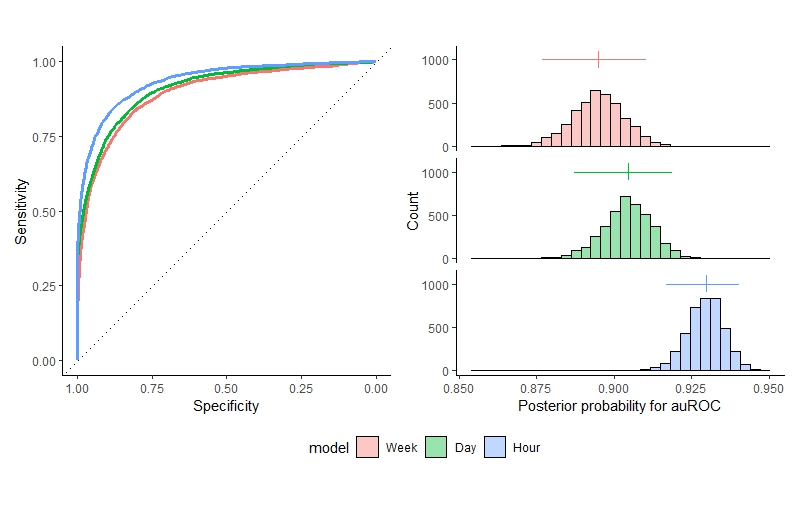

In [ ]:
knitr::include_graphics(path = "figures/ema_1.jpeg")

#### Bayesian Comparisons of Baseline vs. Full Models

We used the posterior probability distributions for the auROCs to formally compare the baseline versus full models (matched for prediction window). The median increase in auROC for the full versus baseline week model was 0.097 (95% CI \[0.081–0.114\]), yielding a probability of 1.000 that the full week model had superior performance. The median increase in auROC for the full versus baseline day model was 0.120 (95% CI \[0.102–0.138\]), yielding a probability of 1.000 that the full-day model had superior performance. The median increase in auROC for the full versus baseline hour model was 0.149 (95% CI \[0.131–0.170\]), yielding a probability of 1.000 that the full hour model had superior performance.

#### Bayesian Comparisons of Full Models by Prediction Window

We also used the posterior probability distributions for the auROCs for the three full models to formally compare the differences in performance by prediction window width. The median increase in auROC for the hour versus the day model was 0.025 (95% CI \[0.017–0.034\]), yielding a probability of 1.000 that the hour (vs. day) model had superior performance. The median increase in auROC for the hour versus the week model was 0.035 (95% CI \[0.026–0.045\]), yielding a probability of 1.000 that the hour model (vs. week) had superior performance. The median increase in auROC for the day versus the week model was 0.010 (95% CI \[0.001–0.020\]), yielding a probability of 0.982 that the day (vs. week) model had superior performance.

#### Other Performance Metrics for the Full Models

We evaluated the sensitivity, specificity, balanced accuracy, PPV, and NPV when the predicted lapse probabilities were used for binary classification (*lapse* vs. *no lapse*) with decision thresholds identified by Youden’s Index. All three full models had high sensitivity, specificity, balanced accuracy, and NPV (@tbl-perf-ema). PPV, however, notably declined as the prediction window width decreased.

``` python
table_perf |> 
  knitr::kable(digits = 3)
```

  Metric                         Week     Day    Hour
  --------------------------- ------- ------- -------
  auROC                         0.891   0.899   0.929
  sensitivity                   0.823   0.828   0.864
  specificity                   0.819   0.845   0.881
  balanced accuracy             0.828   0.835   0.854
  positive predictive value     0.630   0.300   0.025
  negative predictive value     0.944   0.988   0.999

PPV can be increased by increasing the decision threshold; however, increasing the decision threshold will also lower the model’s sensitivity. To evaluate the trade-off between PPV (i.e., precision) and sensitivity (i.e., recall) across decision thresholds, we created Precision-Recall curves by concatenating predicted lapse probabilities across the 30 test sets (@fig-2-ema). For example, the dotted lines in @fig-2-ema depict the sensitivities (0.718, 0.473, and 0.327 for week, day, and hour models, respectively) associated with decision thresholds that yield 0.700 PPV for each model.

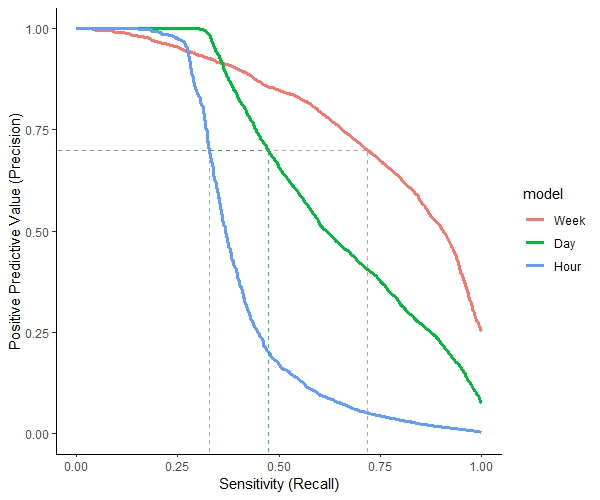

In [ ]:
knitr::include_graphics(path = "figures/ema_2.jpeg")

### Feature Importance for Full Models

Global importance (mean \|Shapley value\|) for feature categories for each full model appears in Panel A of @fig-3-ema. Past use was the most important feature category for lapse prediction across prediction window widths. Future abstinence efficacy was also globally important across window widths. Time-varying constructs (craving, time of day) appear to have more impact in lapse prediction for the hour model compared to the day and week models.

Sina plots of local Shapley values (i.e., the influence of feature categories on individual observations) for each model show that some feature categories (e.g., past pleasant events, future stressful events) impact lapse probability for specific individuals at specific times even if they are not globally important across all observations (@fig-3-ema, Panels B-D).

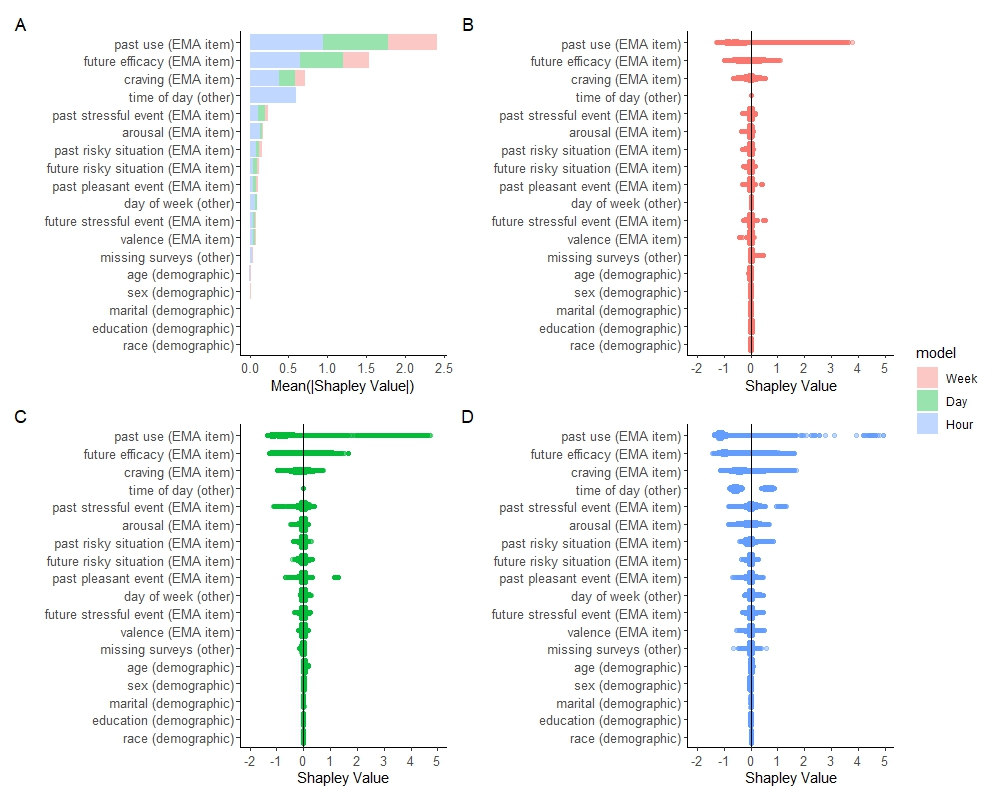

In [ ]:
knitr::include_graphics(path = "figures/ema_3.jpeg")

## Discussion

### Model Performance

All baseline models, which used only past frequency of lapses to predict future lapses, performed moderately well with auROCs in the upper .70s. These results confirm what we would expect: past behavior is a relatively good predictor of future behavior. However, there was still substantial room for increased predictive performance. Furthermore, these baseline models do not identify specific risk factors contributing to lapse predictions at any moment in time for each participant.

All three full models performed exceptionally well, yielding auROCs of 0.89, 0.90, and 0.93 for week, day, and hour level models, respectively. auROCs above .9 are generally described as having “excellent” performance; the model will correctly assign a higher probability to a positive case (e.g., lapse) than a negative case 90% of the time \[@mandrekarReceiverOperatingCharacteristic2010\]. Bayesian comparisons indicated that these full models performed better than the baseline models for the same prediction window. This confirms that EMA can predict future alcohol lapses in the next week, next day, and next hour with high sensitivity and specificity for new individuals. And, as we describe later, using features that map onto important relapse prevention risk constructs may illuminate momentary contributors to predicted lapses.

This study addressed several important limitations of previous research to advance toward robust sensing and prediction models that can be embedded within digital therapeutics. First, our models were trained on a relatively large, treatment-seeking sample of adults in early recovery from AUD that closely matches the individuals most likely to benefit from such models within a digital therapeutic. Second, we explicitly predicted episodes of goal-inconsistent alcohol use (i.e., lapses) because features that predict goal-inconsistent use likely differ from those that predict other types of alcohol use. Third, we measured EMA features and alcohol use with sufficient frequency and granularity to train well-performing models with high temporal resolution - specifically, hour-by-hour predicted probabilities for lapses in the next week, day, and hour. Fourth, we collected features and outcomes over three months during a high risk period (initial remission \[@hagmanDefiningRecoveryAlcohol2022\] from AUD). Fifth, we used cutting-edge resampling methods (grouped, nested, k-fold cross-validation) to provide valid estimates of how our models would perform with new individuals. Finally, we used interpretable machine learning methods (SHAP \[@lundbergUnifiedApproachInterpreting2017; @molnarInterpretableMachineLearning2022\]) to better understand how our models made predictions globally and locally for specific participants at discrete moments in time.

### Understanding & Contextualizing Model Performance

We used SHAP to describe the relative importance of key relapse prevention model constructs (represented by categories of features) to predicted lapses in our three full models. Some constructs consistently emerged as globally important across week, day, and hour level models. Unsurprisingly, the largest contribution to lapse prediction was past use. This is consistent with decades of research on relapse precipitants and our understanding of human behavior more generally (i.e., past behavior predicts future behavior) \[@marlattRelapsePreventionMaintenance1985\]. Decreases in abstinence self-efficacy were also strongly associated with increased probability of future lapses across windows.

The relative importance of some constructs descriptively differed by window width. Punctate, time-varying constructs (e.g., craving, arousal, recent risky situation) had greater impact on predicted lapse probabilities in the hour model compared to day or week models. The time of day feature was relatively important (top four) in the hour model, such that lapses were more likely for hour-level prediction windows that began in the evenings. The day of week feature made a small contribution to the hour and day models given that lapses were more likely on weekends. The time and day features were not useful in the week model because its associated prediction window (a full week) spanned all days and times, making the time and day that the window began irrelevant. The increased global importance for all these punctate features/constructs to immediate lapse risk likely contributed to the hour model outperforming the day and week models. These important global differences in next hour lapse risk also highlight the need for just-in-time interventions that can address these imminent but short-lived risks.

The individual, local Shapley values also shed light on the multidimensional and heterogeneous nature of lapse risk in our sample. Sina plots of local Shapley values (@fig-3-ema) display meaningful ranges of scores for most feature categories. This means that even feature categories with lower global importance (e.g., past pleasant events, future stressful events) still consequentially impacted predictions for some individuals at specific times. This variability in locally important features highlights the potential benefits of recommending optimal interventions and other supports that are personalized for that person at that moment in time.

Our demographic features did not display high global or local importance. Despite the diversity in sex, age, education, and marital status in our sample, these features did not meaningfully contribute to lapse prediction. Although this does not preclude these features’ predictive utility, it does suggest that other EMA feature categories may be more relevant for lapse prediction than these characteristics. Race/ethnicity also did not emerge as globally or locally important features. However, the limited representation of participants of color in our sample warrants caution in drawing conclusions about the predictive utility of race and ethnicity at this time.

### Considerations for Clinical Implementation

#### Smart Digital Therapeutics

We believe these full models may be most effective when embedded in a “smart” digital therapeutic that guides patients toward optimal, adaptive engagement to address their ongoing and momentary risks. These models can provide the patient’s predicted future lapse probability and the features that meaningfully contribute to that probability. We consciously selected EMA items that map onto well-known risk factors from the relapse prevention literature. Consequently, these outputs can be used to recommend specific intervention and support modules that are risk-relevant for each patient - much like a clinician would do if they were available in-the-moment. For example, during sensed periods of high stress, stress reduction techniques (e.g., guided mindfulness) could be recommended. If increased time with risky people or locations is driving lapse risk, the digital therapeutic can support patients to attend support meetings, or encourage participation in the in-app discussion board.

Module recommendations can also be tuned more precisely using the patient’s current lapse probability. If increased craving yields a high predicted lapse probability, stimulus control modules would be recommended (e.g., remove drinking cues, leave unsafe environment). Conversely, if craving is detected but lapse probability is lower, urge management modules that permit coping with the craving in-place could be recommended (e.g., urge surfing, distracting activities/games).

Of course, we must first determine how best to provide module recommendations such that patients trust and follow the recommendation. Increasing the interpretability and transparency of otherwise “black box” machine learning prediction models can improve perceptions, but providing complex or unnecessary information may instead undermine trust \[@molnarInterpretableMachineLearning2022\]. Additional research using appropriate research designs is needed to optimize recommendation messaging to increase adherence and clinical outcomes \[@collinsOptimizationBehavioralBiobehavioral2018\].

A smart digital therapeutic can potentially improve clinical outcomes in multiple ways. First, feedback from the prediction model could improve patient insight and self-monitoring by connecting their daily experiences to changing risk. Second, it can remove patient uncertainty by guiding selection from the substantial content available. Third, a smart digital therapeutic could encourage risk-relevant engagement. Rather than trying to increase overall time using the digital therapeutic, patients could be guided to use the supports that specifically target their personal risk factors at that moment in time. Thus, smart digital therapeutics are well-positioned to pursue the precision mental health goal to “provide the right treatment to the right patient at the right time, every time” \[@kaiserObamaGivesEast2015\].

#### Categorical Lapse Predictions

Our models natively provide quantitative predictions of lapse probabilities. These lapse probabilities can also be used to make categorical predictions (lapse vs. no-lapse) by applying a decision threshold to the quantitative predicted lapse probabilities (i.e., predict lapse when the probability exceeds the decision threshold).

We observed high sensitivity and specificity for these categorical predictions at a decision threshold selected to balance these two performance metrics. However, the PPV (proportion of predicted lapses that were true lapses) of these categorical predictions in our full models was moderate to very low at this threshold (ranging from .630 down to .025 across window widths). For this reason, categorical predictions should be provided to patients with extreme caution, if at all. Instead, we favor the quantitative lapse probabilities as risk indicators to guide intervention and support recommendations.

If categorical predictions are necessary, PPV can be improved by raising the decision threshold, but this comes at the cost of reduced sensitivity. We explored this trade-off in the precision-recall curves displayed in @fig-2-ema. From these curves, it is clear decision thresholds that yield higher PPV (e.g., .700) exist for all three full models, but the associated sensitivity will be lower (e.g., 0.718, 0.473, and 0.327 for the week, day, and hour models, respectively, at this threshold). Clinical implementation of categorical predictions will require selecting an optimal decision threshold after weighing the cost of missing true lapses (low sensitivity) vs. predicting lapses that subsequently do not occur (low PPV). Different thresholds could be used depending on the purpose, context, available resources, or even patient preference.

### Additional Limitations and Future Directions

Successful clinical implementation of our models will require several important steps to address limitations in our work to-date. First, we need to enrich the training data to include diversity across race, ethnicity, and geographic region. Our current prediction models may not work well for people of color or people from rural communities. Prediction models must use diverse training samples to avoid exacerbating rather than mitigating existing disparities. We must also collect data from individuals in later stages of recovery beyond initial remission; features that predict lapses may differ in these later periods. We are intentionally addressing these issues in a current NIH protocol that recruits nationally for demographic and geographic diversity and follows participants for up to 1.5 years into their recovery \[@moshontzProspectivePredictionLapses2021\].

The chronic nature of AUD may require sustained use of a sensing and prediction system. Consequently, the burden of using such systems must be considered. Participants with AUD find three months of 4x daily EMA to be generally acceptable and report that they could hypothetically sustain this for at least a year if there were clinical benefits to them \[@wyantAcceptabilityPersonalSensing2023\]. They also report that 1x daily EMA may be more feasible still \[@wyantAcceptabilityPersonalSensing2023\]. We plan to develop future prediction models that use only the single morning EMA to contrast the assessment burden vs. model performance trade-off between our current models and putatively lower burden models. We also plan to train models that use features based on passively sensed geolocation and cellular communications data-streams (i.e., meta-data from calls and text messages; text message content) that were also collected from our participants. These passively sensed signals may be sufficient as inputs to an exceptionally low burden prediction model. Alternatively, they can be added to models that also include EMA to increase model performance further and/or to reduce the frequency or length of the EMA surveys while maintaining comparable performance.

Our current models predict probability of imminent lapses. The hour and day full models are well-positioned to identify and recommend just-in-time interventions to address these immediate risks. However, the week model may not have sufficient temporal specificity to recommend immediate patient action. Instead, its clinical utility may improve if we shift this coarser window width into the future. For example, we could train a model to predict the probability of lapse at any point during a week window that begins two weeks in the future. This “time-lagged” model could provide patients with increased lead time to implement supports that might not be immediately available to them (e.g., schedule therapy appointment, request support from an AA sponsor).

Finally, XGBoost does not take advantage of grouping observations within participants or systematic variation unique to individual participants. Although XGBoost ignores participant-level information, we do leverage this information to some degree by including change features that anchor participants’ EMA responses to their own previous responses. Independence of observations is not necessary for statistically valid prediction. When observations are grouped/repeated within participants, linear mixed effects models or other statistical models that can estimate both population-level (fixed) effects and participant-level (random) effects may predict better for the participants on which they were trained than would XGBoost. However, we are not interested in making predictions for participants in our training set. We want to know how well our models will work with new individuals like those that will use smart digital therapeutics in the future.

In some domains, there has been increasing interest in idiographic approaches where models are trained and then implemented for the same individual\[@fisherOpenTrialPersonalized2019; @wrightAppliedAmbulatoryAssessment2019\]. Such approaches may also yield superior predictive performance but are not possible to implement for outcomes like alcohol use lapse. A person-specific lapse prediction model requires a sufficient number of positive labels (i.e., lapses) for that individual. It may be too late to prevent relapse if we must wait until an individual has lapsed multiple (perhaps many) times to offer help. We believe the most promising approaches may involve first developing population-based models and updating these models with person-specific information as the patient uses the system \[@zhouEvaluatingMachineLearning2018\]. We are pursuing these cutting-edge models as a near-term future direction.

In this study, we have demonstrated that sensing and prediction systems can now be developed to predict future lapses with high temporal resolution. Important steps still remain before these systems can be embedded within smart digital therapeutics and delivered to patients. However, the necessary steps are clear and, when completed, these smart digital therapeutics hold promise to advance us toward precision mental health solutions that may reduce both barriers and disparities in AUD treatment.



# Lagged predictions of next day alcohol lapse risk for personalized and adaptive continuing care support

# Introduction

Alcohol and other substance use disorders (SUDs) are serious chronic conditions, characterized by high relapse rates \[@mclellanDrugDependenceChronic2000; @dennisManagingAddictionChronic2007\], substantial co-morbidity with other physical and mental health problems \[@substanceabuseandmentalhealthservicesadministration2024NSDUHDetailed; @dennisManagingAddictionChronic2007\], and an increased risk of mortality \[@hedegaardDrugOverdoseDeaths2021; @centersfordiseasecontrolandpreventioncdcAnnualAverageUnited\]. Too few individuals receive medications or clinician-delivered interventions to help them initially achieve abstinence and/or reduce harms associated with their use \[@substanceabuseandmentalhealthservicesadministration2024NSDUHDetailed\]. Moreover, this problem is even worse for subsequent continuing care during SUD recovery. Continuing care, including both risk monitoring and ongoing support, is the gold standard for managing chronic health conditions such as diabetes, asthma, and HIV \[@wagnerImprovingChronicIllness2001\]. Yet, continuing care for SUDs is largely lacking despite ample evidence that SUDs are chronic, relapsing conditions \[@substanceabuseandmentalhealthservicesadministration2024NSDUHDetailed; @stanojlovicTargetingBarriersSubstance2021; @sociasAdoptingCascadeCare2016\].

An important focus of continuing care during SUD recovery is to prevent lapses (i.e., single instances of goal-inconsistent substance use) and full relapse back to harmful use \[@marlattRelapsePreventionMaintenance1985; @witkiewitzRelapsePreventionAlcohol2004\]. Critically, the risk factors that instigate lapses during recovery are individualized, numerous, dynamic, interactive, and non-linear \[@witkiewitzModelingComplexityPosttreatment2007; @brandonRelapseRelapsePrevention2007\]. The optimal supports to address these risk factors and encourage continued, successful recovery vary both across individuals and within an individual over time. Given this, continuing care could benefit greatly from a precision mental health approach that seeks to provide the right support to the right individual at the right time, every time \[@bickmanAchievingPrecisionMental2016; @derubeisHistoryCurrentStatus2019; @kranzlerPersonalizedTreatmentAlcohol2012\]. However, such monitoring and personalized support must also be highly scalable to address the substantial unmet need for SUD continuing care.

Recent advances in both smartphone sensing \[@mohrPersonalSensingUnderstanding2017\] and machine learning \[@hastieElementsStatisticalLearning2009\] hold promise as a scalable foundation for monitoring and personalized support during SUD recovery. Smartphone sensing approaches (e.g., ecological momentary assessment \[EMA\], geolocation sensing) can provide the frequent, longitudinal measurement of proximal risk factors that is necessary for prediction of future lapses with high temporal precision. EMA may be particularly well-suited for lapse prediction because it can provide privileged access to subjective experiences (e.g., craving, affect, stress, motivation, self-efficacy) that are targets for change in evidence-based approaches for relapse prevention \[@marlattRelapsePreventionMaintenance1985; @witkiewitzRelapsePreventionAlcohol2004; @bowenMindfulnessBasedRelapsePrevention2021\]. Furthermore, individuals with SUDs have found EMA to be acceptable for sustained measurement for up to a year with relatively high compliance \[@wyantAcceptabilityPersonalSensing2023; @moshontzProspectivePredictionLapses2021\], suggesting that this method is feasible for long-term monitoring throughout SUD recovery.

Machine learning models are well-positioned to use EMAs as inputs to provide temporally precise prediction of the probability of future lapses with sufficiently high performance to support decisions about interventions and other supports for specific individuals. These models can handle the high dimensional feature sets that may result from feature engineering densely sampled raw EMA over time. They can also accommodate non-linear and interactive relationships between features and lapse probability that are likely necessary for accurate prediction of lapse probability. Moreover, rapid advances in the tools for interpretable machine learning (e.g., Shapley values \[@lundbergUnifiedApproachInterpreting2017\]) now allow us to probe these models to understand which risk features contribute most strongly to a lapse prediction for a specific individual at a specific moment in time. Interventions, supports, and/or suggested lifestyle adjustments can then be personalized to address these risks following from our understanding about relapse prevention.

Preliminary research is now emerging that uses features derived from EMAs in machine learning models to predict the probability of future alcohol use \[@soysterPooledPersonspecificMachine2022; @waltersUsingMachineLearning2021\]. This research is important because it rigorously required strict temporal ordering necessary for true prediction, with features measured before alcohol use outcomes. These studies also used resampling methods (e.g., cross-validation) that prioritize model generalizability to increase the likelihood these models will perform well with new people. Perhaps most importantly, Chapter 2 demonstrated that machine learning models using EMA can provide predictions with very high temporal precision at clinically implementable levels of performance. Specifically, we developed models that predict lapses in the immediate future (i.e., the next day and even the next hour) with areas under the receiver operating characteristic curve (auROCs) of 0.91 and 0.93, respectively.

Chapter 2’s next day lapse prediction model can provide personalized support recommendations to address immediate risks for possible lapses. Features derived from past EMAs can be updated in the early morning to yield the predicted lapse probability for an individual that day. Personalized supports that target the top features contributing to that prediction can then be provided. For example, if predicted lapse probability is high due to frequent craving, the individual could be reminded about the benefits of urge surfing or distracting activities during brief periods when cravings arise. Conversely, guided relaxation techniques could be recommended if lapse probability is high due to recent past and anticipated stressors that day. Patients could also be assisted to implement any of these recommendations using videos or other tools within a digital therapeutic. Curtin and colleagues are currently evaluating outcomes associated with the use of this “smart” (machine learning guided) recovery monitoring and support system (RMSS) for patients with an alcohol use disorder (AUD) \[@wyantMaximizingEngagementTrust2025\].

Despite the promise offered by a smart RMSS based on immediate future risks (e.g., the next day), such a system has limitations. Most importantly, recommendations must be limited to previously learned skills and/or supports that are available to implement that day. However, many risks may require supports that are not available in the moment. For example, to address lifestyle imbalances, several future positive activities may need to be planned. Time with supportive friends or an AA sponsor may require time to schedule. Similarly, work or family schedules may need to be adjusted to return to attending self-help meetings. If new recovery skills or therapeutic activities are needed to address emerging risks, patients may need to book sessions with a therapist. In all these instances, patients would benefit from advanced warning about changes in their lapse probability and the associated risks that contribute to these changes. A smart RMSS could provide this advanced warning by lagging lapse probability predictions further into the future (e.g., predicting lapse probability in a 24-hour window that begins two weeks in the future). However, we do not know if such lagged models could maintain adequate performance for clinical implementation.

In this study, we evaluated the performance of machine learning models that predict the probability of future lapses within 24-hour prediction windows that were systematically lagged further into the future. We considered several meaningful lags for these prediction windows: 1 day, 3 days, 1 week, and 2 weeks. We conducted pre-registered analyses of both the absolute performance of these lagged models and their relative performance compared to a baseline model that predicted lapse probability in the immediate next day (i.e., no lag). In addition to the aggregate performance of these models, we also evaluated algorithmic fairness by comparing model performance across important subgroups that have documented disparities in treatment access and/or outcomes. These include comparisons by race/ethnicity \[@pinedoCurrentReexaminationRacial2019; @kilaruIncidenceTreatmentOpioid2020\], income \[@olfsonHealthcareCoverageService2022\] and sex at birth \[@greenfieldSubstanceAbuseTreatment2007; @kilaruIncidenceTreatmentOpioid2020\]. Finally, we calculated Shapley values for feature categories defined by EMA items to better understand how these models generate predictions and how these features can be used to tailor personalized supports.

# Methods

## Transparency

We adhere to research transparency principles that are crucial for robust and replicable science. We preregistered our data analytic strategy. We reported all data exclusions. Our data, questionnaires, preregistration, and other study materials are publicly available on our OSF page (<https://osf.io/xta67/>). Our annotated analysis scripts and results are publicly available on our study website (<https://jjcurtin.github.io/study_lag/>).

## Participants

We recruited 192 participants in early recovery from AUD in Madison, Wisconsin, USA for a 3-month longitudinal study from February 15, 2017 through September 19, 2019. This sample size was determined based on traditional power analysis methods for logistic regression \[@hsiehSampleSizeTables1989\] because comparable approaches for machine learning models have not yet been validated. Participants were recruited through print and targeted digital advertisements and partnerships with treatment centers. We required that participants:

1.  were age 18 or older,
2.  could write and read in English,
3.  had at least moderate AUD (\>= 4 self-reported DSM-5 symptoms),
4.  were abstinent from alcohol for 1-8 weeks, and
5.  were willing to use a single smartphone (personal or study provided) while on study.

We also excluded participants exhibiting severe symptoms of psychosis or paranoia (Defined as scores \>2.2 or 2.8, respectively, on the psychosis or paranoia scales of the Symptom Checklist–90 \[@derogatislBriefSymptomInventory\])

Of the 192 eligible participants, 191 consented to participate in the study at the screening visit, and 169 subsequently enrolled in the study at the enrollment visit, which occurred approximately one week later. Fifteen participants discontinued before the first monthly follow-up visit. We excluded data from one participant who did not maintain a goal of abstinence during their participation. We also excluded data from two participants due to evidence of careless responding and unusually low compliance. Our final sample consisted of 151 participants.

## Procedure

Participants completed five study visits over approximately three months. After an initial phone screen, participants attended an in-person screening visit to determine eligibility, complete informed consent, and collect self-report measures. Eligible, consented participants returned approximately one week later for an intake visit. Three additional follow-up visits occurred about every 30 days that participants remained on study. Participants were expected to complete four daily EMAs. Other personal sensing data streams (geolocation, cellular communications, sleep quality, and audio check-ins) were collected as part of the parent grant’s aims (R01 AA024391). Participants could earn up to \$150/month if they completed all study visits, had 10% or less missing EMA data, and opted in to provide data for other personal sensing data streams.

## Ethics

All procedures were approved by the University of Wisconsin-Madison Institutional Review Board (Study #2015-0780) and carried out in accordance with the principles of the Declaration of Helsinki. All participants provided written informed consent observed by a research assistant.

## Measures

### Ecological Momentary Assessments

Participants completed four brief (7-10 questions) EMAs daily. The first and last EMAs of the day were scheduled within one hour of participants’ typical wake and sleep times. The other two EMAs were scheduled randomly within the first and second halves of their typical day, with at least one hour between EMAs. Participants learned how to complete the EMA and reviewed the meaning of each question with a member of the research team during their intake visit to ensure consistent question interpretation.

On all EMAs, participants reported dates and times of any previously unreported past alcohol use. Next, participants rated the maximum intensity of recent (i.e., since last EMA) experiences of craving, risky situations, stressful events, and pleasant events. Finally, participants rated their current affect on two bipolar scales: valence (Unpleasant/Unhappy to Pleasant/Happy) and arousal (Calm/Sleepy to Aroused/Alert). On the first EMA each day, participants also rated anticipated risky situations, stressful events, and the likelihood that they would drink alcohol in the next week (i.e., abstinence self-efficacy).

### Individual Characteristics

We collected self-report information about demographics (age, sex at birth, race, ethnicity, education, marital status, employment, and income) and clinical characteristics (AUD milestones, number of quit attempts, lifetime AUD treatment history, lifetime receipt of AUD medication, DSM-5 AUD symptom count, current drug use \[@whoassistworkinggroupAlcoholSmokingSubstance2002\], and presence of psychological symptoms \[@derogatislBriefSymptomInventory\] to characterize our sample. DSM-5 AUD symptom count and presence of psychological symptoms were also used to determine eligibility. Demographics were included as features in our models. A subset of these variables (sex at birth, race, ethnicity, and income) were used for model fairness analyses, as they have documented disparities in treatment access and outcomes. As part of the aims of the parent project, we collected many other trait and state measures throughout the study. A complete list of all measures can be found on our study’s OSF page (<https://osf.io/xta67/>).

## Data Analytic Strategy

Data preprocessing, modeling, and Bayesian analyses were done in R (version 4.4.2) using the tidymodels ecosystem \[@kuhnTidymodelsCollectionPackages2020; @kuhnTidyposteriorBayesianAnalysis2022; @goodrichRstanarmBayesianApplied2023\]. Models were trained and evaluated using high-throughput computing resources provided by the University of Wisconsin Center for High Throughput Computing \[@chtc\].

### Predictions

A *prediction timepoint* (@fig-method, Panel A) is the hour at which our model calculates a predicted probability of a lapse within a future 24-hour prediction window for any specific individual. We calculated the features used to make predictions at each prediction timepoint within a feature scoring epoch that included all available EMAs up until, but not including, the prediction timepoint. The first prediction timepoint for each participant was 24 hours from midnight on their study start date. This ensured at least 24 hours of past EMAs were available in the feature scoring epoch. Subsequent prediction timepoints for each participant repeatedly rolled forward hour-by-hour until the end of their study participation.

The *prediction window* (@fig-method, Panel B) spans a period of time in which a lapse might occur. The prediction window width for all models was 24 hours (i.e., models predicted the probability of a lapse occurring within a specific 24-hour period). Prediction windows rolled forward hour-by-hour with the prediction timepoint. However, there were five possible *lag times* between the prediction timepoint and start of the associated prediction window. A prediction window either started immediately after the prediction time point (no lag) or was lagged by 1 day, 3 days, 1 week, or 2 weeks.

Given this structure, our models provided hour-by-hour predicted probabilities of an alcohol lapse in a future 24-hour period. Depending on the model, that future period (the prediction window) might start immediately after the prediction timepoint or up to 2 weeks into the future. For example, at midnight on the 30th day of participation, the feature scoring epoch would include the past 30 days of EMAs. Separate models would predict the probability of lapse for 24-hour periods starting at midnight that day, or 24-hour periods starting 1 day, 3 days, 1 week or 2 weeks after midnight on day 30.

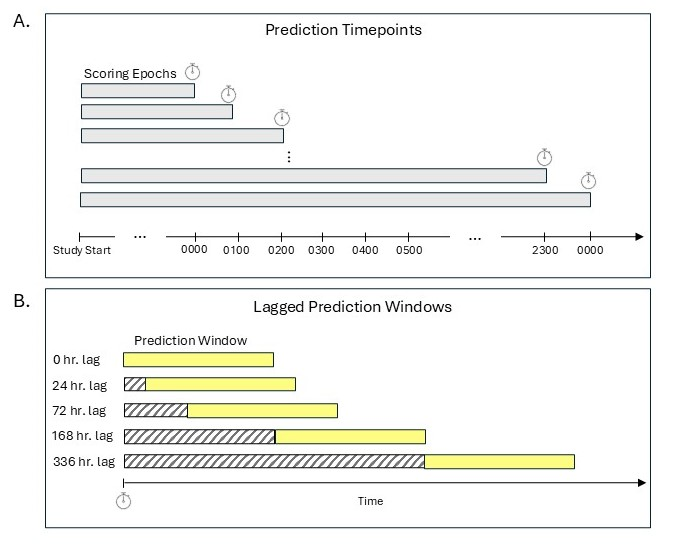

In [ ]:
knitr::include_graphics(path = "figures/methods.png", error = FALSE)

### Labels

The start and end dates and times of past drinking episodes were reported on the first EMA item. A prediction window was labeled *lapse* if the start date/hour of any drinking episode fell within that window. A window was labeled *no lapse* if no alcohol use occurred within that window +/- 24 hours. If no alcohol use occurred within the window but did occur within 24 hours of the start or end of the window, the window was excluded. We used this conservative 24-hour fence for labeling windows as no lapse (vs. excluded) to increase the fidelity of these labels. Given that most windows were labeled no lapse, and the outcome was highly unbalanced, it was not problematic to exclude some no lapse events to further increase confidence in those labels.

This method produced totals of: 274,179 labels for the baseline (no lag) model; 270,911 labels for the 1-day lagged model; 264,362 labels for the 3-day lagged model; 251,458 labels for the 1-week lagged model; and 228,420 labels for the 2-week lagged model.

### Feature Engineering

Features were calculated using only data collected in feature scoring epochs before each prediction timepoint to ensure our models were making true future predictions. For the no lag model, the prediction timepoint was at the start of prediction window, so all data prior to the start of the prediction window were included. For the lagged models, the prediction timepoint was 1 day, 3 days, 1 week, or 2 weeks prior to the start of the prediction window, so the last EMA data used for feature engineering were collected 1 day, 3 days, 1 week, or 2 weeks prior to the start of the prediction window.

A total of 285 features were derived from three data sources:

1.  *Prediction window*: We dummy-coded features for day of the week at the start of the prediction window.

2.  *Demographics*: We created quantitative features for age (in years) and personal income (in dollars), and dummy-coded features for sex at birth (male vs. female), race/ethnicity (non-Hispanic White vs. non-White and/or Hispanic), marital status (married vs. not married vs. other), education (high school or less vs. some college vs. college degree), and employment status (employed vs. unemployed).

3.  *Previous EMA responses*: We calculated raw and change features using EMAs in varying feature scoring epochs (i.e., 12, 24, 48, 72, and 168 hours) before the prediction timepoint for all EMA items. Raw features included min, max, and median scores for each EMA item across all EMAs in each epoch for a given participant. We calculated change features by subtracting each participant’s baseline mean score for each EMA item from their raw feature. These baseline mean scores were calculated using all of a participant’s EMAs collected from the start of participation until the prediction timepoint. We also created raw and change features based on the most recent response for each EMA question and raw and change rate features from previously reported lapses and number of completed EMAs.

Features had missing values if the participant did not respond to the relevant EMA question during the associated scoring epoch. The proportion of missing values across features and models was low (median = .02, range = 0 - .13). We imputed missing data using median imputation for numeric features and mode imputation for nominal features. We selected coarse median/mode methods for handling missing data due to the computational costs associated with more advanced forms of imputation (e.g., KNN imputation, multiple imputation). Importantly, our imputation calculations are done using only held-in data and can be applied to any new observation.

Other generic feature engineering steps included removing zero and near-zero variance features as determined from held-in data. A sample feature engineering script (i.e., tidymodels recipe) containing all feature engineering steps is available on our OSF study page.

### Model Configurations

We trained and evaluated five separate classification models: one baseline (no lag) model and one model for 1-day, 3-day, 1-week, and 2-week lagged predictions. We considered four well-established statistical algorithms (elastic net, XGBoost, regularized discriminant analysis, and single layer neural networks) that vary across characteristics expected to affect model performance (e.g., flexibility, complexity, handling higher-order interactions natively) \[@kuhnAppliedPredictiveModeling2018\]. Candidate model configurations differed across sensible values for key hyperparameters. Configurations also differed on outcome resampling method (i.e., no resampling and up-sampling and down-sampling of the outcome using majority/no lapse to minority/lapse ratios ranging from 5:1 to 1:1).

### Cross-validation

We used participant-grouped, nested cross-validation for model training, selection, and evaluation with auROC. auROC indexes the probability that the model will predict a higher score for a randomly selected positive case (lapse) relative to a randomly selected negative case (no lapse). Grouped cross-validation assigns all data from a participant as either held-in or held-out to avoid bias introduced when predicting a participant’s data from their own data. Folds were stratified on a between-subject variable of low vs. high lapsers (low lapsers reported fewer than 10 lapses while on study, and high lapsers reported 10 or more lapses while on study). We used 2 repeats of 5-fold cross-validation for the inner loops (i.e., *validation* sets) and 6 repeats of 5-fold cross-validation for the outer loop (i.e., *test* sets). Best model configurations were selected using median auROC across the 10 validation sets. Final performance evaluation of those best model configurations used median auROC across the 30 test sets.

### Bayesian Model

We used a Bayesian hierarchical generalized linear model to estimate the posterior probability distributions and 95% Bayesian credible intervals (CIs) from the 30 held-out test sets for our five best models. Following recommendations from the rstanarm team and others \[@rstudioteamRStudioIntegratedDevelopment2020; @gabryPriorDistributionsRstanarm2023\], we used the rstanarm default autoscaled, weakly informative, data-dependent priors that take into account the order of magnitude of the variables to provide some regularization to stabilize computation and avoid over-fitting. Priors were set as follows: residual standard deviation ~ normal(location=0, scale=exp(2)), intercept (after centering predictors) ~ normal(location=2.3, scale=1.3), the two coefficients for window width contrasts ~ normal (location=0, scale=2.69), and covariance ~ decov(regularization=1, concentration=1, shape=1, scale=1). We set two random intercepts to account for our resampling method: one for the repeat, and another for the fold nested within repeat. We specified two sets of pre-registered contrasts for model comparisons. The first set compared each lagged model to the baseline no lag model (1-day lag vs. no lag, 3-day lag vs. no lag, 1-week lag vs. no lag, 2-week lag vs. no lag). The second set compared adjacently lagged models (3-day lag vs. 1-day lag, 1-week lag vs. 3-day lag, 2-week lag vs. 1-week lag). auROCs were transformed using the logit function and regressed as a function of model contrast.

From the Bayesian model we obtained the posterior distribution (transformed back from logit) and Bayesian CIs for auROCs for all five models. To evaluate our models’ overall performance, we report the median posterior probability for auROC and Bayesian CIs. This represents our best estimate for the magnitude of the auROC parameter for each model. If the CIs do not contain .5 (chance performance), this provides strong evidence (\> .95 probability) that our model is capturing signal in the data.

We then conducted Bayesian model comparisons using our two sets of contrasts - baseline and adjacent lags. For both model comparisons, we determined the probability that the models’ performances differed systematically from each other. We also report the precise posterior probability for the difference in auROCs and the 95% Bayesian CIs.

### Fairness Analyses

Using the same 30 held-out test sets, we calculated the median posterior probability and 95% Bayesian CI for auROC for each model separately by race/ethnicity (non-White and/or Hispanic vs. non-Hispanic White), income (below poverty line vs. above poverty line, and sex at birth (female vs. male). We used course race/ethnicity groupings due to the limited diversity of these demographics in our sample. The poverty cutoff was defined from the 2024 federal poverty line for the 48 contiguous United States. Participants at or below \$15,060 annual income were categorized as below poverty. We conducted Bayesian group comparisons to assess the likelihood that each model performs differently by group. We summarize the differences in posterior probabilities for auROC across models.

### Model Characterization

To further characterize and understand our models, we used our inner resampling procedure (2 repeats of 5-fold cross validation grouped on participant and stratified by high/low lapsers) on the full data set to select a single best model configuration for each classification model (no lag, 1-day, 3-day, 1-week, and 2-week lag). The final configuration selected for each model represents the most reliable and robust configuration for deployment. We can better understand our final models by looking at the calibration of the predicted probabilities and the most important features contributing to those predictions.

### Model Calibration

The best model configuration for each classification model was fit on the full data set. We fit this configuration using single 5-fold cross-validation. This method allowed us to obtain a single predicted probability for each observation, while still using separate data for model training and prediction. We calibrated our probabilities using Platt scaling \[@plattProbabilisticOutputsSupport1999\]. We calculated Brier scores to assess the accuracy of our raw and calibrated probabilities for the no lag and 2-week lagged models. Brier scores range from 0 (perfect accuracy) to 1 (perfect inaccuracy). We provide calibration plots for the no lag and 2-week lagged models.

### Global Feature Importance

We used the same single 5-fold cross-validation procedure to calculate raw Shapley values for observations in our held-out folds. Raw Shapley values index the importance of any feature (or set/category of features as described below) to any single prediction for a specific observation (i.e., for a specific 24-hour window for a specific participant), which indicates the “local importance” of that feature \[@lundbergUnifiedApproachInterpreting2017\]. More precisely, the magnitude of the raw Shapley value for any feature indicates how much the feature score for that observation adjusted the prediction (in log-odds units) for that observation relative to the mean prediction across all observations. Positive Shapley values indicate that the feature score increased the prediction for that observation and negative values indicate that the feature score decreased the prediction.

Raw Shapley values are additive across features for an observation, with their sum across features equal to the total adjustment of the predicted value for that observation vs. the mean predicted value across all observations. This property allows raw Shapley values to be added together across features within a category to index the importance of that feature category. We created feature categories by summing raw Shapley values for all features associated with specific EMA items. In three instances, we combined features across two similar EMA items (i.e., past and anticipated risky situations, past and anticipated stressful events, and affective valence and arousal) to yield seven feature categories for distinct constructs assessed by the original 10 EMA items. Specifically, we calculated Shapley values for past use, craving, affective state, past/anticipated risky situations, past/anticipated stressful events, past pleasant events, and abstinence self-efficacy.

Shapley values can be aggregated across observations to describe the global importance of any feature (or feature category) across all predictions (i.e., for all 24-hour windows for all participants) in the dataset. Global feature importance is calculated by averaging the absolute value of the Shapley values for a feature across all observations. A large mean absolute Shapley value indicates that the feature makes big contributions to the predictions across the dataset. Global feature importance is a descriptive statistic that indicates the importance of the feature for predictions in a specific dataset, rather than a hypothetical population of observations. We provide a descriptive plot of the relative ranking of feature categories by their global feature importance for the no lag and 2-week lagged models.

# Results

## Demographic and Lapse Characteristics

\[@tbl-dem\] provides a detailed breakdown of the demographic and clinical characteristics of our sample (N = 151).

``` python
table_dem |> 
  rename(` ` = var) |>
  knitr::kable() |> 
  kable_classic() |> 
  kableExtra::group_rows(start_row = 3, end_row = 4) |>
  kableExtra::group_rows(start_row = 6, end_row = 10) |> 
  kableExtra::group_rows(start_row = 12, end_row = 13) |> 
  kableExtra::group_rows(start_row = 15, end_row = 20) |> 
  kableExtra::group_rows(start_row = 22, end_row = 30) |>
  kableExtra::group_rows(start_row = 33, end_row = 37) |> 
  kableExtra::group_rows(start_row = 40, end_row = 41)
```

+---------------------+-----+------+----------+----------+-------------+
|                     | N   | \%   | M        | SD       | Range       |
+:====================+====:+=====:+:=========+:=========+:============+
| Age                 |     |      | 41       | 11.9     | 21-72       |
+---------------------+-----+------+----------+----------+-------------+
| Sex                 |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Female              | 74  | 49.0 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Male                | 77  | 51.0 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Race                |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| American            | 3   | 2.0  |          |          |             |
| Indian/Alaska       |     |      |          |          |             |
| Native              |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Asian               | 2   | 1.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Black/African       | 8   | 5.3  |          |          |             |
| American            |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| White/Caucasian     | 131 | 86.8 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Other/Multiracial   | 7   | 4.6  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Hispanic, Latino,   |     |      |          |          |             |
| or Spanish origin   |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Yes                 | 4   | 2.6  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| No                  | 147 | 97.4 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Education           |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Less than high      | 1   | 0.7  |          |          |             |
| school or GED       |     |      |          |          |             |
| degree              |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| High school or GED  | 14  | 9.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Some college        | 41  | 27.2 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| 2-Year degree       | 14  | 9.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| College degree      | 58  | 38.4 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Advanced degree     | 23  | 15.2 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Employment          |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Employed full-time  | 72  | 47.7 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Employed part-time  | 26  | 17.2 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Full-time student   | 7   | 4.6  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Homemaker           | 1   | 0.7  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Disabled            | 7   | 4.6  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Retired             | 8   | 5.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Unemployed          | 18  | 11.9 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Temporarily laid    | 3   | 2.0  |          |          |             |
| off, sick leave, or |     |      |          |          |             |
| maternity leave     |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Other, not          | 9   | 6.0  |          |          |             |
| otherwise specified |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Personal Income     |     |      | \$34,298 | \$31,807 | \$0-200,000 |
+---------------------+-----+------+----------+----------+-------------+
| Marital Status      |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Never married       | 67  | 44.4 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Married             | 32  | 21.2 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Divorced            | 45  | 29.8 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Separated           | 5   | 3.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Widowed             | 2   | 1.3  |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| DSM-5 AUD Symptom   |     |      | 8.9      | 1.9      | 4-11        |
| Count               |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Reported 1 or More  |     |      |          |          |             |
| Lapse During Study  |     |      |          |          |             |
| Period              |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
|                                                                      |
+---------------------+-----+------+----------+----------+-------------+
| Yes                 | 84  | 55.6 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| No                  | 67  | 44.4 |          |          |             |
+---------------------+-----+------+----------+----------+-------------+
| Number of reported  |     |      | 6.8      | 12       | 0-75        |
| lapses              |     |      |          |          |             |
+---------------------+-----+------+----------+----------+-------------+

## Model Evaluation

@fig-2-lag presents the full posterior probability distributions for auROC for each model (no lag, 1-day, 3-day, 1-week, and 2-week lag). The median auROCs from these posterior distributions were 0.91 (no lag), 0.89 (1-day lag), 0.88 (3-day lag), 0.87 (1-week lag), and 0.85 (2-week lag). These values represent our best estimates for the magnitude of the auROC parameter for each model. The 95% Bayesian CI for the auROCs for these models were relatively narrow and did not contain 0.5: no lag \[0.90-0.92\], 1-day lag \[0.88-0.90\], 3-day lag \[0.87-0.90\], 1-week lag \[0.85-0.88\], 2-week lag \[0.83-0.87\].

``` python
pp_tidy |> 
  mutate(model = factor(model, levels = c("lag0", "lag24", "lag72", "lag168", "lag336"),
                        labels = c("No lag", "1-day", "3-day", "1-week", "2-week"))) |>
  ggplot() + 
  geom_histogram(aes(x = posterior), fill = "light grey", color = "black", linewidth = .5,  
                 bins = 60) +
  geom_segment(mapping = aes(y = 5800, yend = 6400, x = pp_median, xend = pp_median),
               linewidth = .5, data = ci) +
  geom_segment(mapping = aes(y = 6100, yend = 6100, x = pp_lower, xend = pp_upper),
                linewidth = .5, data = ci) +
  facet_wrap(~model, ncol = 1) +
  geom_vline(xintercept = .5, linewidth = .5, linetype = "dashed") +
  scale_y_continuous("Posterior Samples") +
  xlab("Area Under ROC Curve") +
  expand_limits(x = c(.5, 1)) +
  theme_classic() 
```

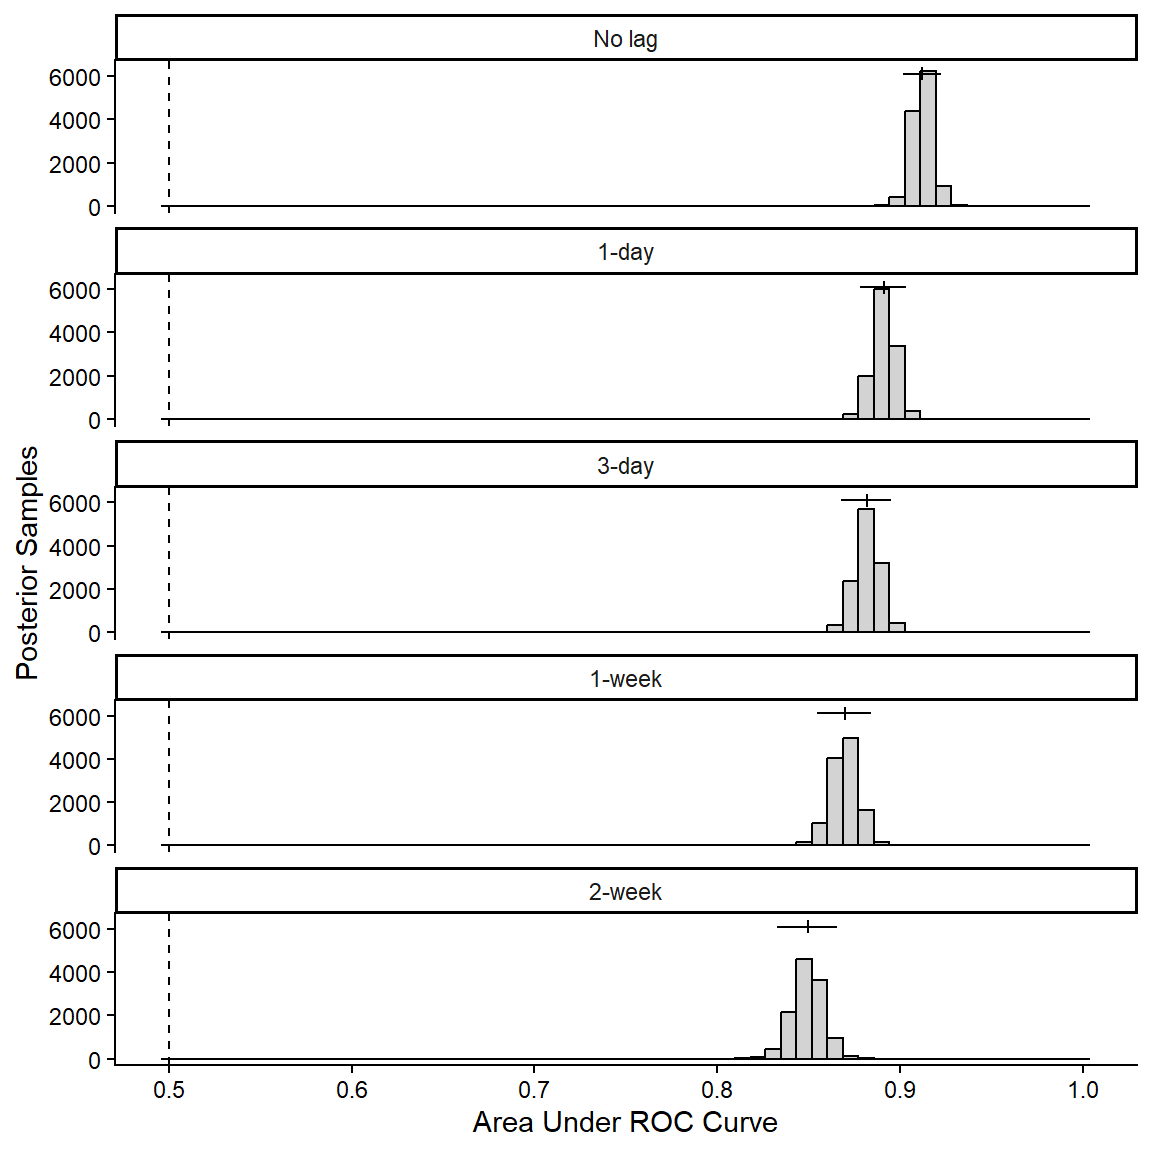

## Model Comparisons

@tbl-model presents the median difference in auROC, 95% Bayesian CI, and posterior probability that that the auROC difference was smaller than 0 for all baseline and adjacent lag contrasts. Median auROC differences less than 0 indicate the more lagged model, on average, performed worse than the more immediate model (e.g., 1-day lag – no lag, 3-day lag – 1-day lag). There was strong evidence (probabilities = 1) that the lagged models performed worse than the baseline (no lag) model, with average drops in auROC ranging from 0.02-0.06, and the previous adjacent lagged model, with average drops in auROC ranging from 0.01-0.02.

``` python
footnote_table_model <- "Median auROC differences less than 0 indicate the more lagged model, on average, performed worse than the more immediate model (e.g., 1-day lag - no lag, 3-day lag - 1-day lag). Bayesian CI represents the range of values where there is a 95% probability that the true auROC difference lies within that range. Probability indicates the posterior probability that this difference is smaller than 0 (i.e., the models are performing differently)."

table_ci |> 
  knitr::kable() |> 
  kable_classic() |> 
  kableExtra::column_spec(1, width = "25em") |> 
  kableExtra::group_rows(start_row = 2, end_row = 5) |> 
  kableExtra::group_rows(start_row = 7, end_row = 9) |> 
  kableExtra::row_spec(5, extra_css = "border-bottom: 1px solid") |> 
  kableExtra::add_footnote(label = footnote_table_model,
                           notation = "none",
                           escape = FALSE)
```

+-----------------------+--------+-----------------------+-------------+
| Contrast              | Median | Bayesian CI           | Probability |
+:======================+:=======+:======================+:============+
| Baseline Contrasts    |        |                       |             |
+-----------------------+--------+-----------------------+-------------+
|                                                                      |
+-----------------------+--------+-----------------------+-------------+
| 1 day vs. No lag      | -0.021 | \[-0.025, -0.017\]    | 1           |
+-----------------------+--------+-----------------------+-------------+
| 3 days vs. No lag     | -0.03  | \[-0.035, -0.026\]    | 1           |
+-----------------------+--------+-----------------------+-------------+
| 1 week vs. No lag     | -0.042 | \[-0.048, -0.037\]    | 1           |
+-----------------------+--------+-----------------------+-------------+
| 2 weeks vs. No lag    | -0.063 | \[-0.069, -0.056\]    | 1           |
+-----------------------+--------+-----------------------+-------------+
| Adjacent Contrasts    |        |                       |             |
+-----------------------+--------+-----------------------+-------------+
|                                                                      |
+-----------------------+--------+-----------------------+-------------+
| 3 days vs. 1 day      | -0.009 | \[-0.013, -0.005\]    | 1           |
+-----------------------+--------+-----------------------+-------------+
| 1 week vs. 3 days     | -0.012 | \[-0.017, -0.008\]    | 1           |
+-----------------------+--------+-----------------------+-------------+
| 2 weeks vs. 1 week    | -0.02  | \[-0.026, -0.015\]    | 1           |
+=======================+========+=======================+=============+
| Median auROC          |        |                       |             |
| differences less than |        |                       |             |
| 0 indicate the more   |        |                       |             |
| lagged model, on      |        |                       |             |
| average, performed    |        |                       |             |
| worse than the more   |        |                       |             |
| immediate model       |        |                       |             |
| (e.g., 1-day lag - no |        |                       |             |
| lag, 3-day lag -      |        |                       |             |
| 1-day lag). Bayesian  |        |                       |             |
| CI represents the     |        |                       |             |
| range of values where |        |                       |             |
| there is a 95%        |        |                       |             |
| probability that the  |        |                       |             |
| true auROC difference |        |                       |             |
| lies within that      |        |                       |             |
| range. Probability    |        |                       |             |
| indicates the         |        |                       |             |
| posterior probability |        |                       |             |
| that this difference  |        |                       |             |
| is smaller than 0     |        |                       |             |
| (i.e., the models are |        |                       |             |
| performing            |        |                       |             |
| differently).         |        |                       |             |
+=======================+========+=======================+=============+

## Fairness Analyses

@tbl-fairness presents the median difference in auROC, 95% Bayesian CI, and posterior probability that the auROC difference was smaller than 0 for the three fairness contrasts: race/ethnicity (non-White and/or Hispanic; *N* = 20 vs. Non-Hispanic White; *N* = 131), sex at birth (female; *N* = 74 vs. male; *N* = 77), and income (below poverty line; *N* = 49 vs. above poverty line; *N* = 102). Median auROC differences less than 0 indicate the model, on average, performed worse for the non-advantaged group (female, non-White and/or Hispanic, below poverty line) compared to the advantaged group (male, non-Hispanic White, and above poverty line). In @tbl-fairness we present fairness analyses for our baseline model (no lag) and for our longest lagged model (2-week lag), as this is likely the most clinically useful lagged model for providing advanced warning of lapse risk.

There was strong evidence (probabilities \> .84) that our models performed worse for the non-advantaged groups compared to the advantaged groups. On average, across all five models, there was a median decrease in auROC of 0.13 (range 0.13-0.17) for participants who were non-White and/or Hispanic compared to participants who were non-Hispanic White. On average, across all five models, there was a median decrease in auROC of 0.05 (range 0.04-0.10) for female participants compared to male participants. On average, across all five models, there was a median decrease in auROC of 0.02 (range 0.01-0.04) for participants below the federal poverty line compared to participants above the federal poverty line.

The proportion of positive lapse labels over all labels (lapse and no lapse) for each demographic subgroup were relatively consistent across groups: race/ethnicity (6%, non-White and/or Hispanic vs. 8%, non-Hispanic White), income (12%, below poverty line vs. 7%, above poverty line), sex at birth (9%, female vs. 7%, male).

``` python
footnote_table_fair <- "Median auROC differences less than 0 indicate the model, on average, performed worse for the disadvantaged group (female, non-White and/or Hispanic, income below poverty line) compared to the advantaged group (male, non-Hispanic White, income above poverty line). Bayesian CI represents the range of values where there is a 95% probability that the true auROC difference lies within that range. Probability indicates the posterior probability that this difference is smaller than 0 (i.e., the models are performing differently for fairness subgroups)."

table_ci_fair |> 
  knitr::kable() |> 
  kable_classic() |> 
  kableExtra::column_spec(1, width = "25em") |> 
  kableExtra::group_rows(start_row = 2, end_row = 4) |> 
  kableExtra::group_rows(start_row = 6, end_row = 8) |> 
  kableExtra::row_spec(4, extra_css = "border-bottom: 1px solid")  |> 
  kableExtra::add_footnote(label = footnote_table_fair,
                           notation = "none",
                           escape = FALSE)
```

+-----------------------+--------+-----------------------+-------------+
| Contrast              | Median | Bayesian CI           | Probability |
+:======================+:=======+:======================+:============+
| Fairness Contrasts    |        |                       |             |
| (No Lag)              |        |                       |             |
+-----------------------+--------+-----------------------+-------------+
|                                                                      |
+-----------------------+--------+-----------------------+-------------+
| female vs. male       | -0.043 | \[-0.059, -0.028\]    | 1           |
+-----------------------+--------+-----------------------+-------------+
| not White vs.         | -0.131 | \[-0.222, -0.057\]    | 0.999       |
| non-Hispanic White    |        |                       |             |
+-----------------------+--------+-----------------------+-------------+
| below poverty vs.     | -0.012 | \[-0.033, 0.007\]     | 0.848       |
| above poverty         |        |                       |             |
+-----------------------+--------+-----------------------+-------------+
| Fairness Contrasts    |        |                       |             |
| (2-week Lag)          |        |                       |             |
+-----------------------+--------+-----------------------+-------------+
|                                                                      |
+-----------------------+--------+-----------------------+-------------+
| female vs. male       | -0.098 | \[-0.125, -0.073\]    | 1           |
+-----------------------+--------+-----------------------+-------------+
| not White vs.         | -0.13  | \[-0.208, -0.058\]    | 0.998       |
| non-hispanic white    |        |                       |             |
+-----------------------+--------+-----------------------+-------------+
| below poverty vs.     | -0.039 | \[-0.073, -0.008\]    | 0.98        |
| above poverty         |        |                       |             |
+=======================+========+=======================+=============+
| Median auROC          |        |                       |             |
| differences less than |        |                       |             |
| 0 indicate the model, |        |                       |             |
| on average, performed |        |                       |             |
| worse for the         |        |                       |             |
| disadvantaged group   |        |                       |             |
| (female, non-White    |        |                       |             |
| and/or Hispanic,      |        |                       |             |
| income below poverty  |        |                       |             |
| line) compared to the |        |                       |             |
| advantaged group      |        |                       |             |
| (male, non-Hispanic   |        |                       |             |
| White, income above   |        |                       |             |
| poverty line).        |        |                       |             |
| Bayesian CI           |        |                       |             |
| represents the range  |        |                       |             |
| of values where there |        |                       |             |
| is a 95% probability  |        |                       |             |
| that the true auROC   |        |                       |             |
| difference lies       |        |                       |             |
| within that range.    |        |                       |             |
| Probability indicates |        |                       |             |
| the posterior         |        |                       |             |
| probability that this |        |                       |             |
| difference is smaller |        |                       |             |
| than 0 (i.e., the     |        |                       |             |
| models are performing |        |                       |             |
| differently for       |        |                       |             |
| fairness subgroups).  |        |                       |             |
+=======================+========+=======================+=============+

## Model Calibration

The raw probabilities produced by our final models were not well calibrated. Consequently, we used Platt scaling to improve calibration. Platt scaling showed excellent improvement to the no lag model with a Brier score of .043. Calibration also improved probability accuracy for the 2-week lagged model with a Brier score of .063. For comparison, raw probability scores yielded Brier scores of .071 and .077 for the no lag and 2-week lagged models, respectively.

@fig-cal shows the calibration plots for the raw and calibrated probabilities for the no lag and 2-week lagged model. It also includes a histogram of raw probabilities that demonstrates our models produced variable predicted probabilities, spanning nearly the entire 0 - 1 range.

``` python
preds_all |> 
  mutate(prob = factor(prob, levels = c("Raw (uncalibrated)", 
                                        "Platt calibration"))) |> 
  group_by(bins, model, prob)  |> 
  summarize(mean_lapse = mean(lapse), .groups = "drop") |> 
  mutate(
    bins = as.numeric(bins),
    midpoints = bin_width/2 + bin_width * (bins - 1)
  )  |> 
  ggplot(aes(x = midpoints, y = mean_lapse, group = prob,
             color = prob, linetype = prob)) +
  geom_abline(slope = 1, intercept = 0, linetype = "longdash", color = "gray80") +
  geom_line(linewidth = .7) +
  geom_rect(data = mini_hist, inherit.aes = FALSE,
            aes(xmin = x - bin_width / 2,
                xmax = x + bin_width / 2,
                ymin = -y,
                ymax = 0),
            alpha = .4) +
  facet_wrap(~ model, ncol = 2) +
  labs(
    x = "Predicted Lapse Probability (Bin Midpoint)",
    y = "Observed Lapse Probability",
    color = NULL,
    linetype = NULL
  ) +
  scale_x_continuous(breaks = seq(0, 1, bin_width), limits = c(0, 1)) +
  scale_y_continuous(limits = c(-0.08, 1), breaks = seq(0,1, bin_width),
                     expand = c(0, 0)) +
  coord_cartesian(clip = "off") +
  scale_color_manual(values = c("black", "#cb6bce")) +
  scale_linetype_manual(values = c("solid", "twodash")) +
  theme_classic(base_size = 11) +
  theme(
    legend.position = "bottom",
    strip.text = element_text(size = 11),
    legend.title = element_text(face = "bold"),
    legend.text = element_text(size = 10),
    axis.text = element_text(size = 10),
    axis.title = element_text(face = "bold")
  )
```

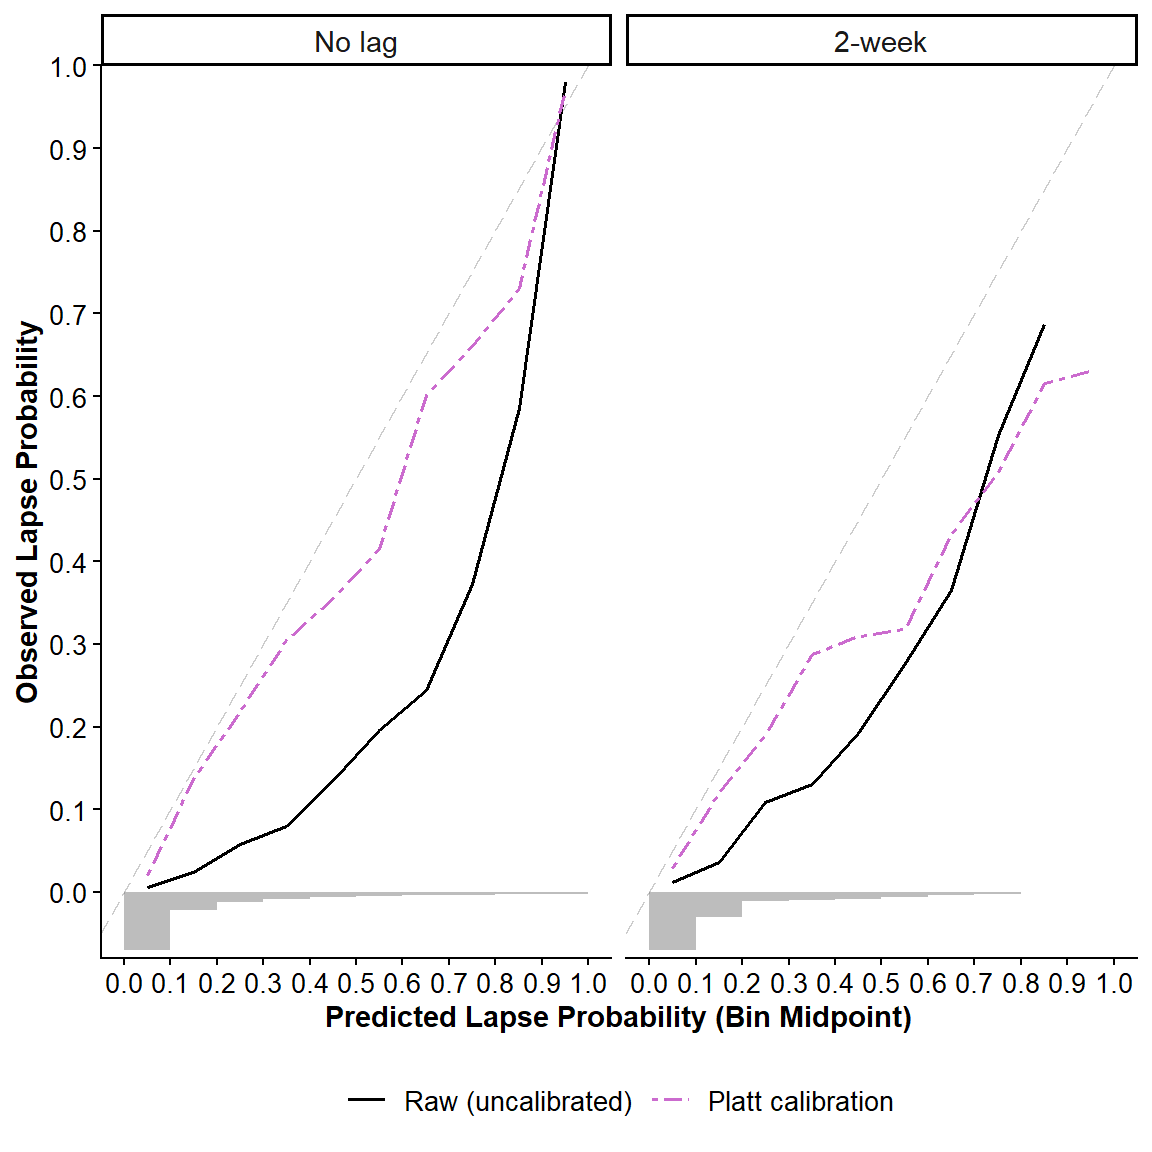

## Feature Importance

Global feature importance is an indicator of how important a feature category was to the model’s predictions, on average (i.e., across all participants and all observations). The top globally important feature category (i.e., highest mean \|Shapley value\|) for all models was past use. Future efficacy was a strong predictor for more immediate model predictions (i.e., no lag), but its importance diminished as lag time increased. On the other hand, as lag time increased, past/future risky situations increased in importance. Craving was consistently important in magnitude across all models. @fig-4-lag shows the relative ranking of feature categories for the no lag and 2-week lagged models. These findings were also consistent across demographic subgroups.

``` python
global_panel 
```

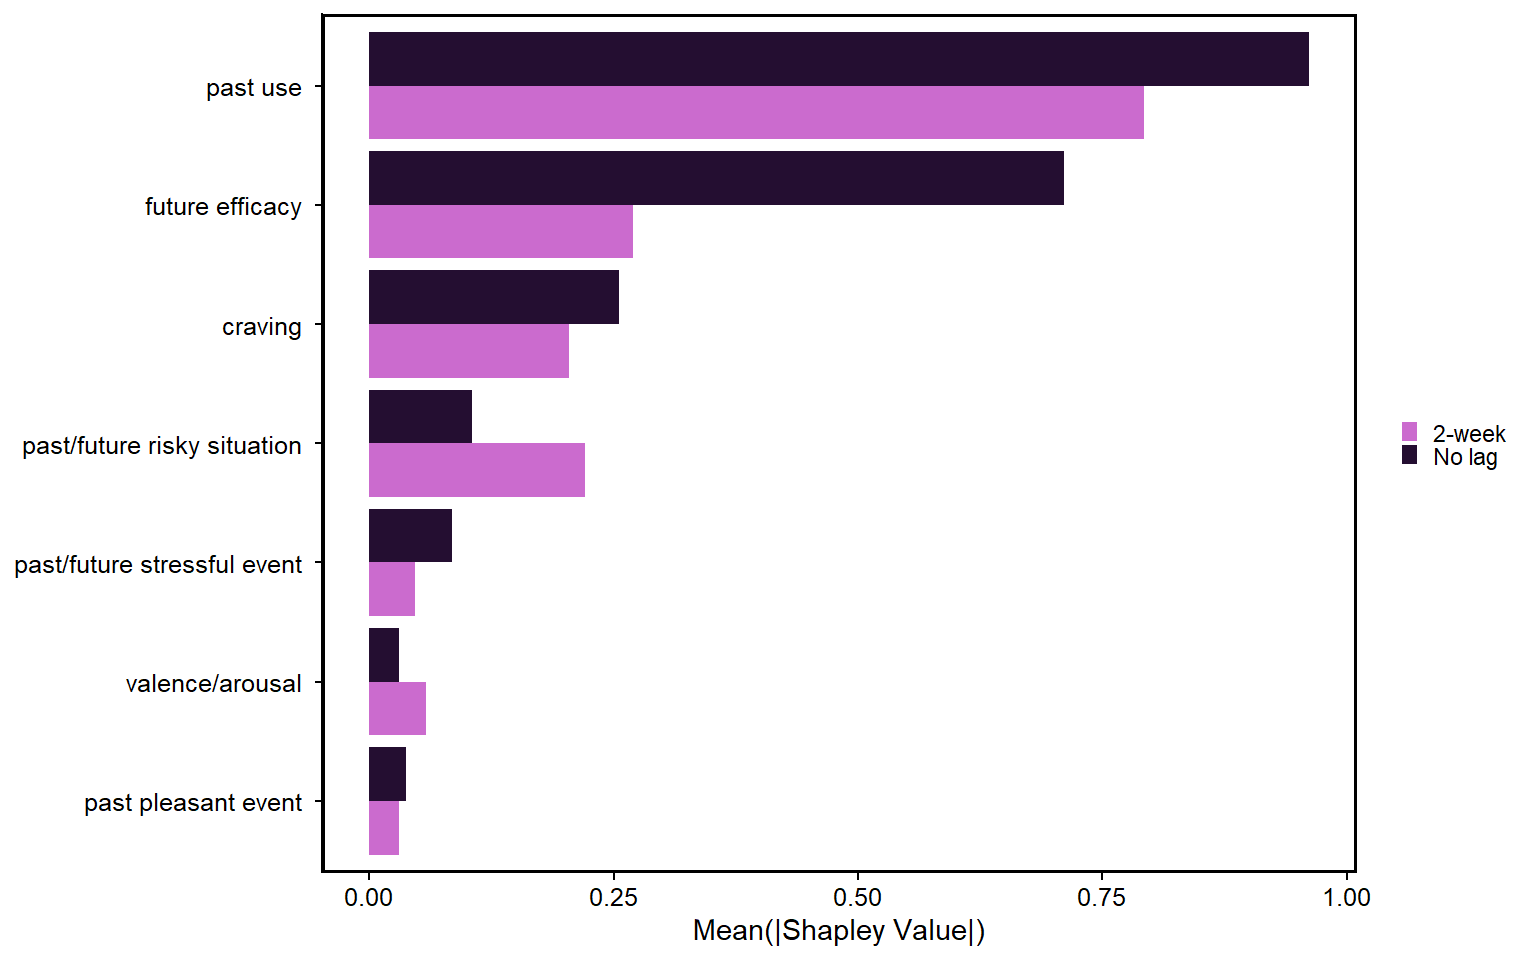

## Discussion

### Model Evaluation and Comparisons

All the models that we evaluated performed exceptionally well. The no lag model, which predicts the probability of an immediate (i.e., within 24 hours) lapse back to alcohol use, had a .91 median posterior probability for auROC. Our 2-week lagged model, which made the most distal predictions, had a .85 median posterior probability for auROC, suggesting lagged models can be used to shift a 24-hour prediction window meaningfully into the future.

Across models (no lag, 1 day, 3 days, 1 week, and 2 weeks), model performance systematically decreased as models predicted further into the future. All lagged models had lower performance compared to the no lag baseline model and to the preceding adjacent lag model. This is unsurprising given what we know about prediction and substance use. Many important relapse risk factors are fluctuating processes that can first emerge and/or change day-by-day, if not more frequently. As lag time increases, features become less proximal to the start of the prediction window. Still, we wish to emphasize that our lowest auROC (.85) is still quite good, and the benefit of advanced notice (i.e., 2 weeks) likely outweighs the modest cost to model performance.

Collectively, these results suggest we can achieve clinically meaningful performance up to two weeks out. Our rigorous resampling methods (grouped, nested, k-fold cross-validation) make us confident that these are valid estimates of how our models would perform with new individuals. Furthermore, it should be noted that both the no lag and 2-week lagged models can be combined in a complementary fashion that allows both for highly accurate immediate lapse prediction and advanced warning about future lapse risk.

### Model Fairness

In recent years, the machine learning field has begun to recognize the need to evaluate model fairness when algorithms are used to inform important decisions (e.g., healthcare services offered, eligibility for loans, early parole). Algorithms that perform favorably for only majority group members may exacerbate existing disparities in access to resources and important clinical outcomes \[@veinotGoodIntentionsAre2018\]. In this study, we assessed model fairness by comparing model performance across important subgroups with known disparities in substance use treatment access and/or outcomes - race/ethnicity (non-White and/or Hispanic vs. non-Hispanic White), income (below poverty line vs. above poverty line), and sex at birth (female vs. male).

All models performed worse for people who were non-White and/or Hispanic, and for people who had an income below the poverty line. The lack of diversity in our training data was likely a key contributor to the poorer model performance in these subgroups. Participants of color were severely underrepresented in our training data (*N* = 20, 13%). Individuals below the poverty line were also underrepresented, though to a lesser degree (*N* = 49, 32%). Of course, these model comparisons should be considered preliminary and interpreted cautiously because the low sample sizes in some groups (e.g., non-White and/or Hispanic) may reduce the statistical validity of the analyses. Nonetheless, these preliminary results regarding model fairness should motivate further efforts to evaluate and address differences in model performance across groups that differ in SUD treatment access/outcome disparities.

An obvious solution to this problem involves intentional recruitment for diversity in training data when developing prediction models. For example, we are now working to increase the racial, ethnic, and income diversity of our training data for alcohol lapse prediction while simultaneously optimizing feedback from these models for implementation purposes \[@wyantMaximizingEngagementTrust2025\]. In a separate project, we developed a national recruitment method that enabled us to recruit for racial, ethnic and income diversity while also focusing on much needed diversity across geographic location (e.g., rural vs. urban; \[@moshontzProspectivePredictionLapses2021\]). We expect geographic diversity in the training data may also be crucial to develop fair models because the features that predict lapse in urban and suburban settings may differ from those that predict lapse in rural environments. If rural participants are not used to train models, the implementation of these models may compound existing disparities in SUD treatment in these communities \[@leeUrbanRuralDisparities2023; @listerSystematicReviewRuralspecific2020\].

Future research can also explore potential computational solutions to mitigate performance disparities that emerge when subgroups are poorly represented in available training data. For example, training data from under-represented subgroups could be up-sampled (e.g., using the synthetic minority oversampling technique), or the cost functions used by the learning algorithms could be adjusted to differentially weigh prediction errors based on participant characteristics. In another vein, modeling approaches that yield idiographic, person-specific models \[@fisherDynamicModelPsychological2015; @davidIntraindividualDynamicNetwork2018; @rocheEnrichingPsychologicalAssessment2014; @wrightModelingHeterogeneityMomentary2016\] may reduce performance disparities across subgroups. For example, we have begun to develop state space models whose parameters can be initialized with priors derived from existing training data but then adjusted over time to fit patterns present within a specific individual’s time-series \[@pulickIdiographicLapsePrediction2025\]. Such models may mitigate issues of unfairness to a large degree because they will weigh the individual’s own data more heavily than group level estimates over time as more data accrue.

Of note, problems with model fairness can emerge even when subgroups are well-represented in the training data. Our models performed less well for women compared to men despite the fact that women were well-represented in the training data (*N* = 74, 49%). Instead, this differential performance may have resulted from more fundamental problems with the features available to the model. We chose our EMA items using domain expertise from decades of research on the factors that predict relapse. However, prior to the 1993 National Institute of Health Revitalization Act \[@studiesNIHRevitalizationAct1994\] that mandated the inclusion of minorities and women in research, women were mostly excluded from substance use treatment research due to their childbearing potential \[@vannicelliEffectSexBias1984\]. As a result, it is possible that our theories about the causes and contributors to relapse are biased toward constructs that are more relevant for men than women. If true, features derived from EMA items that tap these constructs would be expected to under-perform when predicting lapses for women. More research may be needed to identify relapse risk factors for women (e.g., interpersonal relationship problems \[@walitzerGenderDifferencesAlcohol2006\], hormonal changes \[@mchughSexGenderDifferences2018\]), and other groups under-represented in the literature before we can fully address these performance disparities.

In the meantime, data-driven (bottom-up) approaches can be used to engineer high-dimensional feature sets that are not explicitly grounded in existing, and potentially biased, theories. For example, we have begun to explore the application of natural language processing techniques (e.g., LIWC; topic modeling; BERT \[@tausczikPsychologicalMeaningWords2010; @bleiLatentDirichletAllocation2003; @devlinBERTPretrainingDeep2019\]) to text messages and other social media activity by our participants to engineer features that may predict future lapses. Such features may or may not align with existing theories about relapse, but because they are anchored to participants’ own words, they may serve as reliable indicators of lapse risk for certain individuals, particularly when used within learning algorithms that employ feature selection, regularization, or other techniques to address the bias-variance trade-off with high-dimensional feature sets. Furthermore, emerging techniques for interpreting machine learning models \[@molnarInterpretableMachineLearning2022\] can be applied to models that perform well to bootstrap the identification of new lapse risk constructs based on these novel features.

Beyond issues of training data representation and lacunae or outright biases in our theories, it is also true that historically marginalized groups that have experienced systemic racism, exclusion, or other stigma around substance use (e.g., societal expectations for women regarding attractiveness, cleanliness and motherhood \[@meyersIntersectionGenderDrug2021\]) may feel less trusting in disclosing substance use \[@marwickPrivacyMarginsUnderstanding2018\]. These experiences could prompt some individuals in these subgroups to under-report lapses and/or risk factors, which could also degrade performance and evaluation of our models for these subgroups. We observed relatively comparable percentages of lapses reported among disadvantaged compared to advantaged groups. However, comparable lapse rates do not necessarily confirm comparable reporting accuracy because it is possible that there were systematic differences in lapse rates across groups that were masked by issues of trust.

### Model Characterization

#### Calibration

After applying Platt scaling to our predicted probabilities, our models were generally well calibrated with increasing monotonic relationships between calibrated model output and lapse event rates. Well-calibrated probabilities indicate that the predicted probability aligns closely with the true likelihood of an outcome (i.e., a lapse). Our no lag model had excellent calibration. However, the calibration plots suggest that with a longer lag time of 2 weeks, the model tends to over-predict the likelihood of lapses when predicted probabilities were higher.

This pattern may not necessarily be problematic. Research suggests that people often struggle to interpret probabilistic feedback, especially when it’s provided in raw numerical form \[@zikmund-fisherRightToolWhat2013; @fagerlinMakingNumbersMatter2007; @zipkinEvidencebasedRiskCommunication2014\]. As a result, it may be more effective to communicate risk using coarser categories (e.g., low, medium, or high risk) or through relative changes in risk (e.g., “Your risk of lapse is higher this week compared to last week”). These forms of feedback may be less sensitive to small miscalibrations at the extremes as long as the relationship between predicted probabilities and the observed event rate is monotonic.

#### Feature importance

The relative ordering of top global features remained somewhat consistent across the no lag and 2-week lagged models. Past use was the most important feature in both models in our dataset. This is not surprising given that our outcome was lapse, and past behavior is often the best predictor of future behavior. This finding also supports decades of clinical research on relapse prevention, where lapses (i.e., single instances of goal inconsistent alcohol use) are seen as powerful precursors to relapse (i.e., full return to harmful drinking; \[@marlattRelapsePreventionMaintenance1985\]). Abstinence self-efficacy emerged as the second most important feature in both models in our dataset, indicating that participants had reasonably accurate insight into their near-term success with maintaining alcohol abstinence. Craving was also an important predictor in both models, suggesting that it may be an important target for intervention to support early recovery efforts.

Several feature categories displayed sizeable differences in global importance by lag time. The importance of abstinence self-efficacy dropped by more than 50% in the 2-week lagged model relative to the no lag model. This may indicate that self-efficacy during early recovery is unstable even across shorter periods of time such that their current self-efficacy does not strongly predict abstinence success even two weeks into the future. In fact, craving and risky situations become as important as self-efficacy when predicting two-week lagged lapses. It may be that these other experiences are shaping and changing the individual’s self-efficacy rapidly in early recovery. This also suggests that more frequent clinical assessments of self-efficacy as a target for intervention may be needed rather than assuming stability in this construct if initial assessment suggests it is high. Also, our study cannot determine if this differential importance of self-efficacy for immediate vs. lagged lapses persists beyond early recovery (where people may be encouraged to take a “one day at a time” mindset). Self-efficacy may become a more stable predictor of future abstinence success after longer periods of recovery, but our sample was limited to participants in early recovery (\<= 8 weeks of abstinence at intake).

Past use was less important for the 2-week lagged model compared to the no lag model. This indicates that the predictive strength of a lapse on the likelihood of subsequent lapses diminishes to some degree over a relatively short period of time. This is good news and reinforces that single lapses do not always mark a return to consistent patterns of frequent, and potentially harmful, alcohol use. Despite this reduction in importance of past use as a predictor of lagged alcohol use, past use did remain the most important category for two-week lagged lapses. Lapses may provide “teachable moments” that can be used to reinforce recovery motivation, better understand risks, and develop skills to address those risks \[@witkiewitzModelingComplexityPosttreatment2007\]. Conversely, lapses should not be ignored because they remain strong predictors of further use.

Surprisingly, past and anticipated risky situations were more important in the 2-week lagged vs. no lag model, suggesting that the impact of these situations on lapses back to use may be delayed. It may be that persistent exposure to risks is necessary to undermine an abstinence goal and lead to return to alcohol use. Alternatively or additionally, people may also be better able to anticipate future risky situations (e.g., vacations, anniversaries of significant dates) than future acute stressors or even future self-efficacy. Regardless, the increased importance of risky situations for predicting lagged lapses provides an opportunity to intervene prior to the lapse, particularly if the individual is encouraged to assess future risks and/or makes use of a recovery monitoring prediction model.

We were also surprised that stressful events, pleasant events, and affective state features did not make more important contributions to predictions across models. These constructs are highlighted in numerous theories about addiction and relapse \[@marlattRelapsePreventionMaintenance1985; @witkiewitzRelapsePreventionAlcohol2004; @rawsonIntensiveOutpatientApproach1995\] and represent targets for intervention in many existing treatments \[@mchughCognitiveBehavioralTherapySubstance2010; @lieseCognitiveBehavioralTherapyAddictive2022; @bowenMindfulnessBasedRelapsePrevention2021; @centerforsubstanceabusetreatmentCounselorsTreatmentManual2006\]. It may be that their impact is subsumed within other more powerful features (i.e., past use and self-efficacy). However, this seems unlikely given that the methodology underlying Shapley values allows for a fair distribution of importance among the relevant predictive features even when those features are correlated \[@molnarInterpretableMachineLearning2022\]. Alternatively, we may need to more carefully consider the nuanced roles that these constructs play (e.g., within the context of individual coping strategies, social support or environmental factors) in the return to alcohol use during recovery \[@fronkStressAllostasisSubstance2020\].

### Additional Limitations and Future Directions

We believe our lapse prediction models will be most effective when embedded in an RMSS designed to deliver adaptive and personalized continuing care. This system could send daily, weekly, or less frequent messages to users with personalized feedback about their risk of lapse and provide support recommendations tailored to their current recovery needs. This study provides initial support that immediate and lagged prediction models can be trained to high accuracy using EMA for recovery monitoring. Furthermore, locally important features from these models can be used to identify the specific factors that contribute to each lapse risk prediction.

The no lag model can be used to guide individuals to take immediate, actionable steps to maintain their recovery goals and support them to implement these steps within the RMSS. For example, the RMSS can recommend an embedded urge surfing activity when someone’s immediate risk is driven by strong craving whereas a guided relaxation video can be provided to the user when they report stressful events. Similarly, the RMSS can encourage (and explicitly support) the user to reflect on recent past successes and/or skills they have developed when their self-efficacy is low.

The 2-week lagged model provides individuals with advanced warning of their lapse risk. This model is well-suited to support recovery needs that cannot be addressed immediately within an RMSS app, such as scheduling positive or pleasant activities, increasing social engagement, or attending a peer-led recovery meeting. To be clear, we do not believe an RMSS app alone will be sufficient to deliver continuing care. We expect individuals will require additional support throughout their recovery from a mental health provider (e.g., motivational enhancement, crisis management, skill building), a peer (e.g., sponsor, support group), or family member. Importantly, these types of supports take time to set up, highlighting the value of this lagged 2-week model.

At this point, it is still unclear the best way to provide risk and support information from our models to people. For an RMSS to be successful, users must trust the system, consistently engage with the system over time, and find the system beneficial. We have recently launched an NIAAA funded project to optimize daily support messages by examining the impact of several key message components (e.g., lapse probability, locally important features, a risk-relevant recovery activity recommendation, the linguistic style and tone of the message) on engagement, trust, clinical outcomes \[@wyantMaximizingEngagementTrust2025\].

For a system using lagged models, we can imagine that lags longer than two weeks (i.e., more advanced warning) would be better still. In the present study, we could not train models with lags longer than two weeks because participants only provided lapse reports for up to three months. With the 2-week lagged model, we had approximately 17% fewer labeled observations for training because the first two weeks (out of 12 weeks) of labels for each participant were discarded. This data loss may be one factor that contributed to the decreases in model performance with increases in lag time and we believed that greater data loss (e.g., 25% for a 3-week lag) would not be tenable. We have recently completed data collection on a NIDA funded project where participants provided EMA and other sensed data for up to 12 months \[@moshontzProspectivePredictionLapses2021\]. These data will allow us to train models with longer lags and to better evaluate the impact of data loss on model performance because lag time can be increased substantially with proportionally less data loss given 52 weeks of labeled observations per participant.

While the number of individual observations (i.e., \# prediction timepoints per participant X \# participants) was sufficient to train models with low bias, low variance and overall high performance, the relatively small number of unique participants remains an important limitation of this study. Successful machine learning models must generalize well to new data (i.e. new observations among new individuals). Our analyses only speak to how well our models generalize to a small number of new individuals and these individuals are mostly homogeneous with respect to key demographic characteristics. To be clear, we made the most efficient use of our sample (i.e., using nested cross-validation to maximize the amount of held-out/test sets available for model evaluation); however, concerns about the generalizability to new individuals and other populations (e.g., individuals living in rural locations, members of other diverse groups not adequately represented in our sample) remain.

Additionally, our use of features from 4x daily EMA as model inputs may raise concerns about measurement burden. We confirmed that participants can comply with such EMA schedules over this time period and that they find it acceptable given its potential benefits to them \[@wyantAcceptabilityPersonalSensing2023; see also @jonesComplianceEcologicalMomentary2019\]. However, frequent daily surveys may become too burdensome within an RMSS intended for use over many, many months to years for long-term continuing care. We have begun to address this concern by training no lag models with fewer EMAs (1x daily) and have found comparable performance \[@pulickIdiographicLapsePrediction2025\]. Additionally, reinforcement learning could potentially be used for adaptive EMA sampling. For example, each day the algorithm could make a decision to send out an EMA or not based on inferred latent states of the individual based on previous EMA responses and predicted probability of lapse.

We have also begun to explore how we can supplement our models with data from lower burden sensing methods. Geolocation, which can be passively sensed, could compliment EMA well \[@baeLeveragingMobilePhone2023\]. First, it could provide insight into information not easily captured by self-report without lengthy surveys. For example, the amount of time spent in risky locations, or changes in routine (e.g., loss of job; move to new city) that could indicate life stressors can be detected in movement patterns. Second, the near-continuous sampling of geolocation could offer risk-relevant information that would otherwise be missed in between the discrete sampling periods of EMA. Furthermore, potentially powerful features can be engineered by combining geolocation data with contextual information available in public sources (e.g., census data, alcohol outlet density) \[@huangActivityIdentificationGPS2010; @xieTrajectoriesActivitiesSpatiotemporal2009\] or collected from the user directly (e.g., self-evaluated riskiness of a given location) \[@moshontzProspectivePredictionLapses2021\].

### Conclusions

This study suggests it is possible to accurately predict alcohol lapses both immediately and up to two weeks into the future using lagged machine learning prediction models. The no lag model could guide users to engage with a smart RMSS that provides daily recovery activities that are personalized to their lapse risk and the factors contributing to that risk. The 2-week lagged model could enable patients to seek out and implement recovery support that is not immediately available to them within the RMSS. Several important steps remain prior to implementing the no lag and 2-week lagged models within a smart RMSS. Feedback and support messages from these models should be optimized to sustain system engagement, trust, and clinical outcomes. Passive sensing of model inputs may allow assessment of a broader range of risk factors with less burden for system users. Perhaps most important, model fairness must be improved by decreasing disparities in performance for less privileged groups. We remain optimistic about the potential to implement these models within a smart RMSS because these barriers, while challenging, are surmountable.



# Using smartphone sensing and machine learning for personalized daily lapse risk prediction in a national sample of people with opioid use disorder

## Introduction

About 4.5 million adults in the United States met criteria for opioid use disorder (OUD) in 2024 \[@substanceabuseandmentalhealthservicesadministration2024NSDUHDetailed\]. OUD is associated with increased rates of mortality and morbidity, including infectious disease, psychiatric comorbidity, and disability \[@hserHighMortalityPatients2017\]. The societal burden of untreated OUD is substantial. The combined economic costs of lost productivity, health care expenditures, criminal justice involvement, loss of life, and reduced quality of life have been estimated to exceed \$1 trillion \[@florenceEconomicBurdenOpioid2021\].

Medications for OUD (MOUD), including methadone and buprenorphine, are effective at reducing opioid use, craving, and overdose risk \[@maEffectsMedicationassistedTreatment2019\]. They are also associated with improvements in mental health and social functioning, particularly when maintained over extended periods. However, despite strong evidence for MOUD, access remains limited.

Even among individuals retained in treatment, lapses are frequent and confer a critical period of risk for treatment dropout, relapse, and overdose \[@weinsteinLongtermRetentionOffice2017; @heinzLongitudinalObservationalStudy2025\]. Opioid lapses are particularly high-risk events. Reduced opioid tolerance (e.g., after a period of abstinence) and the increasing prevalence of fentanyl and other synthetic opioids in the drug supply substantially increase the likelihood of fatal overdose.

Identifying vulnerable periods of high lapse risk and contextualizing that risk (i.e., *Why* risk is high) could enable individuals to take proactive action to prevent lapse. However, the risk factors that precipitate lapses are highly individualized, numerous, dynamic, and interactive. The optimal supports to address these risks vary both across individuals and within individuals over time. Thus, effective interventions must be personalized to both the individual and the moment to meet the complex and changing needs of people in recovery.

Advances in smartphone sensing methods, including brief daily self-report surveys and passive geolocation sensing, offer a powerful way to collect densely sampled risk-relevant data \[@mohrPersonalSensingUnderstanding2017\]. These data can be used as inputs into machine learning models to generate temporally precise predictions of lapse risk \[@heinzLongitudinalObservationalStudy2025\]. Methods from interpretable machine learning can be used to identify personalized predictors of risk at any moment in time \[@molnarInterpretableMachineLearning2022\].

Daily self-report surveys can reliably collect proximal risk factors for lapse, such as recent craving, abstinence self-efficacy, risky situations, and substance use behaviors. Research suggests that individuals can adhere to self-report sensing methods while using substances \[@wyantAcceptabilityPersonalSensing2023; @jonesComplianceEcologicalMomentary2019\]. However, it is less clear to what extent people in recovery from illicit substance use disorders can, or are willing to, report risk information accurately enough to develop prediction models. People with substance use disorders (SUD) may experience greater instability in their day-to-day lives (e.g., stigma or legal consequences may make access to healthcare, stable housing, or supportive relationships more difficult). This instability could make it difficult to recall and report recent behaviors and events promptly or accurately. It may also skew baseline perceptions of what constitutes a risky or stressful experience.

Supplementing self-report data with passively sensed geolocation data could make up for imprecise reports of risk factors or be used for lapse prediction during periods of non-adherence to self-report surveys. Moreover, geolocation data could provide a complementary and distinct set of intervenable features. For example, geolocation data may provide insight into time spent in risky locations or changes in routine (e.g., job loss) that may indicate life stressors. These features may become even more powerful when combined with contextual information from public sources (e.g., census data, alcohol outlet density) or from self-report (e.g., self-evaluated riskiness of specific locations). Geolocation data have been demonstrated to contain sufficient signal for predicting craving \[@epsteinPredictionStressDrug2020\], a putative precursor to opioid lapse, and therefore represent a promising sensing method for predicting lapse risk.

In the current study, we developed a machine learning model that predicts next-day opioid lapse risk using daily self-report and geolocation sensing data. Our study has several notable strengths. First, we recruited a national sample of participants across the United States who were diverse in regard to race and ethnicity, income, gender, sexual orientation, and geographic location. Second, participants provided sensing data and opioid lapse reports for up to one year, a duration that exceeds previously published SUD prediction studies and allowed us to capture longer-term recovery trajectories. Third, our sample consisted of patients in early recovery from OUD receiving MOUD, ensuring that the study population closely reflected the intended clinical audience for our model. Fourth, we explicitly evaluated model performance across demographic subgroups to assess algorithmic fairness. Finally, we identified the most influential predictors using two complementary quantitative approaches, providing insight into the features that drive lapse risk predictions.

## Methods

### Transparency and Openness

We adhere to research transparency principles that are crucial for robust and replicable science. First, we published this study’s protocol as a registered report (International Registered Report Identifier \[IRRID\]: DERR1-10.2196/29563) during the initial enrollment of pilot participants \[@moshontzProspectivePredictionLapses2021\]. Second, we followed the Transparent Reporting of a multivariable prediction model for Individual Prognosis Or Diagnosis extension for Artificial Intelligence (TRIPOD+AI) guidelines \[@collinsTRIPODAIStatementUpdated2024\]. Finally, our features, labels, questionnaires, and other study materials are publicly available on our OSF page (<https://osf.io/zvm7s/overview>) and our annotated analysis scripts and results are publicly available on our study website (<https://jjcurtin.github.io/study_risk2/>). <!--JJC: Data??--><!--NIH sharing?-->

### Participants

We recruited participants in early recovery from OUD from across the United States. We recruited through national digital advertising and collaborations with treatment providers at MOUD clinics. Our recruitment strategy was designed to create a diverse sample with respect to demographics (gender, age, race, and ethnicity), and geographic location (urban and rural). We required participants:

- were age 18 or older,
- could read, write, and speak in English,
- were enrolled in and adherent with an MOUD program for at least 1 month but no longer than 12 months or enrolled in or recently completed a day treatment program, and
- had an Android smartphone with an active data plan.

We did not exclude participants for comorbid substance use or other psychiatric disorders.

### Procedure

Participants completed three video or phone visits over approximately 12 months. During the enrollment visit, study staff obtained written informed consent and collected demographic information. They walked participants through how to download the Smart Technology for Addiction Recovery (STAR) study app, provided a set of video tutorials to learn how to use the app, and instructed participants to complete the intake survey within the app. The STAR app was developed by the UW Madison Center for Health Enhancement Systems Studies and used for all data collection. Within the app participants could control their data sharing options, monitor completed study tasks, receive reminder notifications about tasks, message staff, and access STAR’s suite of resources and tools for people in recovery from AUD \[@gustafsonSmartphoneApplicationSupport2014\]. Enrolled participants met with study staff one week later to troubleshoot technical issues. At the end of the study enrollment period participants met briefly with study staff for a debriefing session. While on study, participants were expected to complete daily surveys, monthly surveys, and share geolocation sensing data. Other sensing data streams (i.e., daily video check-ins, cellular communications, and app usage data) were collected as part of the parent grant’s aims (NIDA R01 DA047315). All procedures were approved by the University of Wisconsin-Madison Institutional Review Board (Study #2019-0656).

Participants were compensated \$40 for completing the enrollment visit and watching the STAR video tutorials and \$10 for the two follow-up phone visits. Participants were compensated \$10 per month for the monthly survey, up to \$15 per month for the daily surveys[1], and \$5 per month for sharing geolocation data.[2] Participants were also paid \$50 per month to offset the cost of maintaining a cellphone data plan.

### Measures

#### Individual Differences

We collected self-report information about demographics (age, gender, sexual orientation, race, ethnicity, education, employment, and income). Zip codes from participants’ reported home addresses were linked to Rural–Urban Commuting Area (RUCA) codes to characterize the rural–urban status of their residences \[@economicresearchserviceusdepartmentofagricultureRuralUrbanCommutingArea\]. These variables were collected to characterize our sample. They were also included as features in our model to allow for potential interactions with the sensing features and control for demographic differences on lapse risk. Demographic variables with some evidence for influencing OUD treatment access and clinical outcomes and/or carrying general societal stigma (gender, race/ethnicity, income, sexual orientation, and geographic location) were used to perform subgroup analyses for evaluating model fairness \[@pinedoCurrentReexaminationRacial2019; @kilaruIncidenceTreatmentOpioid2020; @olfsonHealthcareCoverageService2022; @greenfieldSubstanceAbuseTreatment2007; @martinNeedReceiptSubstance2022; @lofaroRuralUrbanDifferences2025; @xinExploringIntersectionalityStigma2023\].

We collected information about OUD history to characterize OUD severity and recovery stability across our sample. These measures included self-reported Diagnostic and Statistical Manual of Mental Disorders, Fifth Edition OUD symptoms \[@americanpsychiatricassociationDiagnosticStatisticalManual2022\], past month opioid use, past month residential treatment for OUD, past month receipt of psychiatric medication, preferred opioid, preferred route of administration, and lifetime history of overdose. As part of the aims of the parent project, we collected many other trait and state measures throughout the study. A complete list of all measures can be found in our registered report \[@moshontzProspectivePredictionLapses2021\].

#### Daily Survey

Participants completed a brief (1-2 minute) 16-item daily survey each day on study through the STAR app. The daily survey became available in the app at 5:00 AM CST each morning and participants had 24 hours to complete it. Participants could enable push notifications for reminder prompts to complete the survey. Participants reported opioid lapses on the first daily survey item. If participants responded “yes” to the question “Have you used any opioids for non-medical reasons that you have not yet reported?”, they were prompted to select the day(s) and time(s) of the lapse(s). Times were reported in 6-hour increments (12:00am–5:59am, 6:00am–11:59am, 12:00pm–5:59pm, 6:00pm–11:59pm). These reports served as the primary outcome for the lapse risk prediction model. On the remaining 15 items, participants reported any other drugs that they had used, whether they took their MOUD as prescribed in the past 24 hours, and rated the maximum intensity of recent (i.e., in the past 24 hours) experiences of pain, craving, risky situations, stressful events, and pleasant events. They also rated their sleep and how depressed, angry, anxious, relaxed, and happy they have felt in the past 24 hours. Lastly, participants responded to 2 future-facing items that asked about participants’ motivation and confidence to continue to avoid using opioids for non-medical reasons over the next week.

#### Geolocation Sensing

The STAR app passively recorded participants’ time-stamped geolocations (i.e., latitude and longitude) every 1.5-15 minutes, depending on their movement. We augmented the geolocation data with self-reported subjective context. On each monthly survey participants were asked 6 questions about frequently visited locations (i.e., locations that the participant spent more than 3 minutes on 2 or more times in a month) from the previous month. Participants were asked to describe the type of place, what they typically do there, the general frequency of pleasant and unpleasant experiences at the location, and the extent to which spending time there helps or harms their recovery. <!--more detail about monthly survey maybe?  This also included measures collected at enrollment that were expected to change.--><!--KW: lets talk about this, We arent using any of those monthly measures aside from the context questions so I am not sure how much to go into it-->

[1] \$0.25 per survey plus an additional \$3.70 for completing at least 12 surveys in the first half of the month and an additional \$3.70 for completing at least 12 surveys in the second half of the month (total range of \$14.40 - \$15.15)

[2] Participants were also compensated for providing other sensing data as part of the parent grant’s aims, including \$10 per month for sharing cellular communication logs and text message content and up to \$10 per month for the daily video check-in.

### Data Analytic Strategy

Data preprocessing, modeling, and Bayesian analyses were done in R using the tidymodels ecosystem \[@kuhnTidymodelsCollectionPackages2020; @kuhnTidyposteriorBayesianAnalysis2022; @goodrichRstanarmBayesianApplied2023\]. Models were trained and evaluated using high-throughput computing resources provided by the University of Wisconsin Center for High Throughput Computing \[@chtc\].

#### Feature Engineering

Features were calculated using only data collected before the start of each prediction window to ensure our models were making true future predictions. We calculated a total of 297 features from three data sources:

1.  *The prediction window day.* We created one-hot coded features for day of the week for the start of the prediction window.

2.  *Demographic individual differences.* For demographics, we created ordinal features for age, education, and income based on predefined response ranges (see @tbl-risk2dem for ranges), an ordinal feature for RUCA code associated with home address (range 1-10), and one-hot coded features for gender (male, not male), race and ethnicity (non-Hispanic White, Hispanic and/or not White), orientation (heterosexual, not heterosexual), and employment (employed, not employed/looking for work, not employed/not looking or able to work).

3.  *Dynamic daily survey and geolocation sensing data.* For both sets of sensing features we calculated two types of features: raw and difference features. Raw features represent the feature value calculated within a given scoring epoch (e.g., the maximum urge rating reported on the daily survey during the 168 hours immediately preceding the start of the prediction window). Difference features capture participant-level changes from their baseline scores. Specifically, we subtracted each participant’s mean score for each feature using all available data prior to the prediction window from the associated raw feature (e.g., the participant’s average urge rating across all prior daily surveys subtracted from the maximum urge rating in the preceding 168 hours).

    For the daily survey, we calculated raw and difference features for the most recent and the min, max, and median responses in the 168 hours preceeding the start of the prediciton window for the 13 5-point likert scale items (items 4-16; pain, urge, risky situation, stressful event, pleasant event, sleep, depressed, angry, anxious, relaxed, happy, abstinence motivation, and abstinence confidence). We also calculated raw and difference rate features based on counts of previous opioid lapses, other drug use, missed MOUD doses (items 1-3), and completed daily surveys in 24 and 168-hour feature scoring epochs (e.g., counts of opioid lapses within the 168 hours preceding the start of a prediction window divided by 168).

    We used two feature scoring epochs (24 and 168 hours before the start of the prediction window) to create proximal and distal geolocation features. Raw geolocation points were cross-checked against known locations with reported subjective context. We used a threshold of 50 meters for matching context to geolocation points. We calculated raw and difference features for sum duration of time out of the home in the evenings (i.e., not at their home between the hours of 7:00pm-4:00am). We calculated raw and difference features for sum duration of time spent at locations according to what they indicated they do at the location (spend time with friends, socialize with new people, religious activities, relax, spend time with family, volunteer, receive mental health care, receive physical health care, receive MOUD treatment, drink alcohol, take classes, work), how pleasant and unpleasant their experiences typically are at the location (Always, Most of the time, Sometimes, Rarely, Never), and how helpful and harmful the location is to their recovery (Extremely, Considerably, Moderately, Mildly, Not at all). We also calculated a raw and difference feature of location variance (i.e., the extent to which a participant’s location changes over a feature scoring epoch).

All features (sets 1-3 above) were included in our full model. We also fit three models with varying ablated sensing features from set 3. Specifically, these models ablated daily survey features, ablated geolocation features, and ablated daily survey and geolocation features combined to assess the incremental predictive value of these features.

Other feature engineering steps performed during cross-validation included imputing missing values (median imputation for numeric features and mode imputation for nominal features), dummy coding nominal features, normalizing features to have a mean of zero and standard deviation of 1, bringing outlying values (\|z-score\| \> 5) to the fence, and removing zero and near-zero variance features as determined from held-in data. We selected coarse median/mode methods for handling missing data due to the low rates of missing values and computational costs associated with more advanced forms of imputation (e.g., KNN imputation, multiple imputation). A sample feature engineering script (i.e., tidymodels recipe) containing all feature engineering steps is available on our OSF study page.

#### Lapse Labels

Prediction windows started at 6:00am in participants’ local timezones and ended at 5:59am the next day. This window start time was selected to more closely approximate a typical wake-sleep cycle as opposed to midnight-to-midnight calendar day. For each participant the first prediction window began at 6:00am on their second day of participation and rolled forward day-by-day until their participation ended (i.e., the last prediction window ended at 5:59am on the day of their last recorded daily survey). <!--JJC: day before their last survey?--><!--KW: no it was technically the last day but it was early morning before the last survey was available at 6 am--> Responses from the first daily survey item were used to label each prediction window as lapse or no lapse. For example, if a participant reported a lapse on December 12 from 12:00am-5:59am the prediction window spanning 6:00am on December 11 through 5:59am on December 12 was labeled as a lapse.

#### Cross-Validation

We used nested cross-validation for selection and evaluation of the final candidate model configurations. We used 1 repeat of 5-fold cross-validation on the inner loop for model selection and 6 repeats of 5-fold cross-validation on the outer loop for evaluation. Participants were grouped so that all of their data were always in the held-in or held-out fold to avoid bias introduced when predicting a participant’s data from their own data. Folds were stratified so that all folds contained comparable proportions of individuals who lapsed while on study.<!--what it stratified just on lapse vs. no-lapse or something more complicated?  How does that compare to what we do with RISK--><!--KW: stratified on hi/lo performed worse we decided to use yes/no because lapses may be considered a bigger deal and therefore be more homogenous across frequent vs infrequent lapsers-->

#### Model Configurations

We initially considered three statistical algorithms that differed in terms of assumptions and bias-variance tradeoff: elastic net, random forest, and XGBoost. Preliminary analyses using simple 6x5 cross-validation suggested that XGBoost was superior. Additionally, we planned to use the Shapley additive explanations (SHAP) method for calculating feature importance which is optimized for XGBoost. Therefore we only considered XGBoost for the final nested cross-validation analyses.

Final candidate model configurations differed across sensible values for key hyperparameters and outcome resampling method (i.e., up-sampling and down-sampling of the outcome at ratios ranging from 5:1 to 1:1). All resampling was exclusively done in the held-in training data (i.e., held-out data were not resampled) to prevent biasing performance estimates \[@vandewieleOverlyOptimisticPrediction2021\]. All model configurations were fit for the full model and the three feature ablation models (ablated daily survey features, ablated geolocation features, and ablated daily survey and geolocation features combined).

#### Model Evaluation

We evaluated the best full model’s probability predictions across three domains: discrimination, calibration, and overall performance. We follow recommendations for reporting measures and plots to characterize these performance domains \[@vancalsterEvaluationPerformanceMeasures2025\].

##### auROC and Model Comparisons

Our performance metric for model selection and evaluation was the area under the receiver operating characteristic curve (auROC). auROC is an aggregate measure of discrimination across all possible decision thresholds. Specifically, it represents the probability that the model will assign a higher predicted probability to a randomly selected positive case (lapse) compared to a randomly selected negative case (no lapse).

We used a Bayesian hierarchical generalized linear model to estimate the posterior distribution and 95% credible intervals (CI) for auROC for the 30 held-out test sets (i.e., held-out data in the outer loop of the nested cross-validation procedure) for our best full and ablated models. We used weakly informative, data-dependent priors to regularize and reduce overfitting. Priors were set as follows: residual standard deviation ~ normal(location=0, scale=exp(2)), intercept (after centering predictors) ~ normal(location=2.3, scale=1.3), the two coefficients for window width contrasts ~ normal (location=0, scale=2.69), and covariance ~ decov(regularization=1, concentration=1, shape=1, scale=1). We set two random intercepts to account for our resampling method: one for the repeat, and another for the fold nested within the repeat. We specified three model contrasts that compared the full model to each of the three ablated models (full vs. ablated daily survey features, full vs. ablated geolocation features, full vs. ablated daily survey and geolocation features combined). auROCs were transformed using the logit function and regressed as a function of model contrast. From the Bayesian model we obtained the posterior distribution for auROC for the full and baseline models. We reported the median posterior probability for auROC and 95% CIs for each model. We then conducted four Bayesian model comparisons to determine the probability that the full model differed systematically in performance compared to the three ablated models.

We performed five dichotomous subgroup analyses to assess the fairness of our model’s predictions. Using the same 30 held-out test sets and the same modeling procedure as above, we calculated the median posterior probability and 95% CI for auROC for each model separately by gender (not male vs. male), race/ethnicity (Hispanic and/or non-White vs. non-Hispanic White), income (less than \$25,000 vs. more than \$25,000)<!--We usually refer to this comparison as below poverty but our lowest income group is technically above the federal poverty line ($15,960)-->, sexual orientation (heterosexual vs. not heterosexual), and geographic location (rural vs. urban)^\[We followed guidelines from the United States Health Resources and Services Administration and define urban as an area where the primary commuting flow is within a metropolitan core of 50,000 or more people (RUCA code = 1) and rural as anything not urban (RUCA codes 2-10). \[@healthresourcesandservicesadministrationHowWeDefine\]. We conducted Bayesian group comparisons to assess the likelihood that each model performs differently by group.

##### Calibration and Overall Performance

To further evaluate our model’s predictions, we used our inner resampling procedure (1 repeat of 5-fold cross validation) on the full data set to select and fit a single best model configuration for the full model. The final configuration selected represents the most reliable and robust configuration for deployment.

Calibration is an indicator of how well a model’s predicted probabilities match the true observed outcomes. For example, a well-calibrated model that assigns a 30% lapse risk prediction should observe lapses in approximately 30% of such cases. We used Platt scaling to calibrate our final full model’s raw probabilities from the 5 held-out folds \[@plattProbabilisticOutputsSupport1999\]. We provided a calibration plot of these raw and calibrated probabilities. To characterize overall performance we reported Brier scores for the raw and calibrated probabilities. Brier scores are the mean squared difference between the predicted probabilities and observed outcome and range from 0 (perfect accuracy) to 1 (perfect inaccuracy). We also provided histograms of risk probability distributions by true lapse outcome.

#### Feature Importance

Feature importance values provide insight into the features that have the most influence on the model’s predictions. For every prediction, we can extract feature importance values providing actionable insight into intervenable targets for lapse risk (i.e., for a specific individal at a specific moment). We used the same single 5-fold cross-validation procedure (see Calibration and Overall Performance section) to calculate raw Shapley values for each observation in held-out data \[@lundbergUnifiedApproachInterpreting2017\]. The magnitude of the raw Shapley value indicates how much the feature score for that observation adjusted the prediction (in log-odds units) relative to the mean prediction across all observations. Positive Shapley values indicate that the feature score increased the prediction for that observation and negative values indicate that the feature score decreased the prediction. In other words, higher Shapley values suggest the feature increases lapse risk and lower values suggest the feature decreases lapse risk. Shapley values are inherently additive. For any observation, Shapley values can be summed to create a total adjustment score for the predicted value. We created feature categories by collapsing features that differed only by scoring epoch and calculation into a single feature category (e.g., Raw features for most recent urge rating, and min, max, and mean urge rating in the 168 hours preceding the start of the prediction window were combined to form a “Urge, Raw” feature category). Raw and difference features were not combined as their relationship to risk were not uniform. We plotted individual Shapley values and feature categories as partial dependence plots to illustrate these feature-risk relationships.

Feature importance values can also be aggregated across all participants and all observations to provide a relative rank ordering of the most important features. We calculated overall feature importance in two ways. First, we used a traditional approach in which we calculated the mean absolute Shapley value for each feature category across all observations. This approach summarizes overall feature importance by averaging the magnitude of each feature’s contribution. However, it can be skewed toward features that exhibit infrequent but very large Shapley values, potentially overstating the importance of features that are strongly associated with the outcome, but only come up in a small subset of observations. The second way we calculated feature importance was by calculating the proportion of observations in which each feature category had the highest Shapley value. This approach summarizes how frequently a feature category is influential across observations (i.e., considering both magnitude and prevalence). We provided a plot of the relative ranking of feature categories by their overall feature importance using these two methods.

## Results

### Participants

We enrolled 330 participants across 47 states in the United States from April 2021 through December 2024. To be considered enrolled in the study, participants were required to be eligible, consent, and complete the first personalized monthly survey where geolocation context were provided.[1] Of these 330, 14 were excluded for not providing at least 28 days of EMA data with acceptable adherence[2], 7 participants were excluded due to evidence of careless responding on daily surveys, and 13 participants were excluded due to having insufficient context data for geolocation points (fewer than two contextualized locations). Our final analysis sample consisted of 296 participants. Participant demographic and OUD characteristics of our final sample is presented in @tbl-risk2dem.

``` python
footnote_table_dem_a <- "N = 296"


table_dem |> 
  knitr::kable() |> 
  kable_classic() |> 
  kableExtra::group_rows(start_row = 2, end_row = 7) |> 
  kableExtra::group_rows(start_row = 9, end_row = 12) |> 
  kableExtra::group_rows(start_row = 14, end_row = 18) |> 
  kableExtra::group_rows(start_row = 20, end_row = 26) |> 
  kableExtra::group_rows(start_row = 28, end_row = 29) |> 
  kableExtra::group_rows(start_row = 31, end_row = 36) |> 
  kableExtra::group_rows(start_row = 38, end_row = 43) |> 
  kableExtra::group_rows(start_row = 45, end_row = 52) |> 
  kableExtra::group_rows(start_row = 54, end_row = 57) |> 
  kableExtra::group_rows(start_row = 59, end_row = 60) |> 
  kableExtra::group_rows(start_row = 62, end_row = 63) |> 
  kableExtra::group_rows(start_row = 65, end_row = 66) |> 
  kableExtra::group_rows(start_row = 68, end_row = 71) |>
  kableExtra::group_rows(start_row = 73, end_row = 77) |>
  kableExtra::group_rows(start_row = 79, end_row = 83) |>
  kableExtra::footnote(general = c(footnote_table_dem_a), escape=FALSE) 
```

+----------------------------------------------+-----+------+
|                                              | N   | \%   |
+:=============================================+====:+=====:+
| Age                                          |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| 22-25                                        | 7   | 2.4  |
+----------------------------------------------+-----+------+
| 26-35                                        | 105 | 35.5 |
+----------------------------------------------+-----+------+
| 36-45                                        | 107 | 36.1 |
+----------------------------------------------+-----+------+
| 46-55                                        | 60  | 20.3 |
+----------------------------------------------+-----+------+
| 56-65                                        | 13  | 4.4  |
+----------------------------------------------+-----+------+
| Over 65                                      | 4   | 1.4  |
+----------------------------------------------+-----+------+
| Gender                                       |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| Man                                          | 158 | 53.4 |
+----------------------------------------------+-----+------+
| Woman                                        | 131 | 44.3 |
+----------------------------------------------+-----+------+
| Non-binary                                   | 4   | 1.4  |
+----------------------------------------------+-----+------+
| Not listed above                             | 2   | 0.7  |
+----------------------------------------------+-----+------+
| Orientation                                  |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| Straight, that is, not gay or lesbian        | 237 | 80.1 |
+----------------------------------------------+-----+------+
| Lesbian or gay                               | 17  | 5.7  |
+----------------------------------------------+-----+------+
| Bisexual                                     | 35  | 11.8 |
+----------------------------------------------+-----+------+
| Not sure                                     | 1   | 0.3  |
+----------------------------------------------+-----+------+
| Not listed above                             | 4   | 1.4  |
+----------------------------------------------+-----+------+
| Race and Ethnicity (select all that apply)   |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| American Indian/Alaskan Native               | 17  | 5.7  |
+----------------------------------------------+-----+------+
| Asian                                        | 3   | 1.0  |
+----------------------------------------------+-----+------+
| Black/African American                       | 43  | 14.5 |
+----------------------------------------------+-----+------+
| Native Hawaiian/Other Pacific Islander       | 3   | 1.0  |
+----------------------------------------------+-----+------+
| White/Caucasian                              | 235 | 79.4 |
+----------------------------------------------+-----+------+
| Hispanic, Latino, or Spanish origin          | 26  | 8.8  |
+----------------------------------------------+-----+------+
| Not listed above                             | 5   | 1.7  |
+----------------------------------------------+-----+------+
| Geographic Location                          |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| rural                                        | 57  | 19.3 |
+----------------------------------------------+-----+------+
| urban                                        | 239 | 80.7 |
+----------------------------------------------+-----+------+
| Education                                    |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| 8th grade or less                            | 5   | 1.7  |
+----------------------------------------------+-----+------+
| Some high school, but did not graduate       | 25  | 8.4  |
+----------------------------------------------+-----+------+
| High school graduate or GED                  | 92  | 31.1 |
+----------------------------------------------+-----+------+
| Some college or 2-year degree                | 130 | 43.9 |
+----------------------------------------------+-----+------+
| 4-year college graduate                      | 30  | 10.1 |
+----------------------------------------------+-----+------+
| More than 4-year or advanced degree          | 12  | 4.1  |
+----------------------------------------------+-----+------+
| Employment                                   |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| Disabled, not able to work                   | 34  | 11.5 |
+----------------------------------------------+-----+------+
| Employed, working 1-39 hours per week        | 69  | 23.3 |
+----------------------------------------------+-----+------+
| Employed, working 40 or more hours per week  | 54  | 18.2 |
+----------------------------------------------+-----+------+
| Not employed, NOT looking for work           | 32  | 10.8 |
+----------------------------------------------+-----+------+
| Not employed, looking for work               | 102 | 34.5 |
+----------------------------------------------+-----+------+
| Retired                                      | 3   | 1.0  |
+----------------------------------------------+-----+------+
| Household Income                             |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| Less than \$25,000                           | 164 | 55.4 |
+----------------------------------------------+-----+------+
| \$25,000 - \$34,999                          | 42  | 14.2 |
+----------------------------------------------+-----+------+
| \$35,000 - \$49,999                          | 38  | 12.8 |
+----------------------------------------------+-----+------+
| \$50,000 - \$74,999                          | 29  | 9.8  |
+----------------------------------------------+-----+------+
| \$75,000 - \$99,999                          | 13  | 4.4  |
+----------------------------------------------+-----+------+
| \$100,000 - \$149,999                        | 3   | 1.0  |
+----------------------------------------------+-----+------+
| \$150,000 - \$199,999                        | 4   | 1.4  |
+----------------------------------------------+-----+------+
| \$200,000 or more                            | 1   | 0.3  |
+----------------------------------------------+-----+------+
| Self-reported DSM-5 OUD Symptom Count        |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| Under threshold (0-1)                        | 5   | 1.7  |
+----------------------------------------------+-----+------+
| Mild (2-3)                                   | 0   | 0.0  |
+----------------------------------------------+-----+------+
| Moderate (4-5)                               | 5   | 1.7  |
+----------------------------------------------+-----+------+
| Severe (6+)                                  | 284 | 95.9 |
+----------------------------------------------+-----+------+
| Past Month Opioid Use                        |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| No                                           | 201 | 67.9 |
+----------------------------------------------+-----+------+
| Yes                                          | 93  | 31.4 |
+----------------------------------------------+-----+------+
| Past Month Detox or Residential Treatment    |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| No                                           | 189 | 63.9 |
+----------------------------------------------+-----+------+
| Yes                                          | 106 | 35.8 |
+----------------------------------------------+-----+------+
| Past Month Psychiatric Medication            |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| No                                           | 151 | 51.0 |
+----------------------------------------------+-----+------+
| Yes                                          | 144 | 48.6 |
+----------------------------------------------+-----+------+
| Preferred Opioid                             |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| Fentanyl                                     | 50  | 16.9 |
+----------------------------------------------+-----+------+
| Heroin                                       | 122 | 41.2 |
+----------------------------------------------+-----+------+
| Prescription opioid not for opioid treatment | 93  | 31.4 |
+----------------------------------------------+-----+------+
| Medication for opioid treatment              | 28  | 9.5  |
+----------------------------------------------+-----+------+
| Preferred Route of Administration            |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| Injection                                    | 104 | 35.1 |
+----------------------------------------------+-----+------+
| Oral                                         | 56  | 18.9 |
+----------------------------------------------+-----+------+
| Smoke                                        | 48  | 16.2 |
+----------------------------------------------+-----+------+
| Sniff or snort                               | 83  | 28.0 |
+----------------------------------------------+-----+------+
| Other                                        | 3   | 1.0  |
+----------------------------------------------+-----+------+
| Lifetime History of Overdose                 |     |      |
+----------------------------------------------+-----+------+
|                                                           |
+----------------------------------------------+-----+------+
| Never                                        | 119 | 40.2 |
+----------------------------------------------+-----+------+
| 1 time                                       | 41  | 13.9 |
+----------------------------------------------+-----+------+
| 2-3 times                                    | 69  | 23.3 |
+----------------------------------------------+-----+------+
| 4-5 times                                    | 26  | 8.8  |
+----------------------------------------------+-----+------+
| More than 5 times                            | 39  | 13.2 |
+==============================================+=====+======+
| [Note: ]{style="font-style: italic;"}        |     |      |
+----------------------------------------------+-----+------+
| N = 296                                      |     |      |
+==============================================+=====+======+

### Adherence, Features, and Labels

Mean days on study across participants was 278.32 days (range 30-392 days). 77.7% of participants (230/296) remained on study for at least six months. Daily survey adherence was high. On average participants completed 77.8% of the daily survey prompts (range 40-100%). Participants provided, on average, 263.50 daily geolocation points (range 2.17-871.34).

The average percentage of missing values across daily survey features was low (mean=0.71%, range 0-1.10%). The average percentage of missing values across geolocation features was higher (mean=12.0%, range 0-15.6%). Across participants we generated a total of 82,156 day-level labels. Thirty-six percent of participants (106/296) reported an opioid lapse while on study (mean=4.93, range 0-117). This resulted in 1.8% of the labels positive for lapse (1,458/82,156 labels). We stratified the data on a variable of whether someone lapsed on study to ensure our imbalanced outcome was evenly split (and roughly equivalent to the sample prevalance) across cross-validation folds.

### auROC and Model Comparisons

The median posterior probability for the best full model was 0.94, with narrow 95% CI (\[0.93, 0.95\]). To evaluate the incremental predictive value of our dynamic sensing features, we compared the performance of our full model to the performance of three ablated models: 0.63 (ablated daily survey features), 0.94 (ablated geolocation features), and 0.55 (ablated daily survey and geolocation features). There was strong evidence that the full model’s performance was better compared to models that ablated the daily survey features and the daily survey and geolocation features combined (probabilities = 1.00). There was no evidence that the full model performed better than a model with geolocation features ablated (probability = 0.34). The median difference in auROC, 95% Bayesian CI, and posterior probability that that the auROC difference was greater than 0 for all ablation contrasts are presented in @tbl-risk2model.

``` python
footnote_table_model <- "Median auROC differences greater than 0 indicate the full model, on average, performed better than the ablated model (i.e., full vs. ablated daily survey, full vs. ablated geolocation, full vs. ablated daily survey and geolocation). Bayesian CI represents the range of values where there is a 95% probability that the true auROC difference lies within that range. Probability indicates the posterior probability that this difference is greater than 0 (i.e., the full model is performing better)."

table_ci |> 
  mutate(`Bayesian CI` = str_c("[", round(lower, 3), ", ", round(upper, 3), "]"),
         `Median auROC Difference` = as.character(round(median, 3)),
         Probability = sprintf("%.3f", probability)) |> 
  select(Contrast = contrast, `Median auROC Difference`, `Bayesian CI`, Probability) |> 
  knitr::kable() |> 
  kable_classic() |> 
  kableExtra::column_spec(1, width = "25em") |> 
  kableExtra::add_footnote(label = footnote_table_model,
                           notation = "none",
                           escape = FALSE) 
```

  Contrast                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           Median auROC Difference   Bayesian CI         Probability
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ ------------------------- ------------------- -------------
  full vs. ablated daily survey                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      0.314                     \[0.29, 0.338\]     1.000
  full vs. ablated geolocation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       -0.002                    \[-0.009, 0.005\]   0.342
  full vs. ablated daily survey and geolocation                                                                                                                                                                                                                                                                                                                                                                                                                                                                      0.389                     \[0.363, 0.414\]    1.000
  Median auROC differences greater than 0 indicate the full model, on average, performed better than the ablated model (i.e., full vs. ablated daily survey, full vs. ablated geolocation, full vs. ablated daily survey and geolocation). Bayesian CI represents the range of values where there is a 95% probability that the true auROC difference lies within that range. Probability indicates the posterior probability that this difference is greater than 0 (i.e., the full model is performing better).                                                  

Our fairness subgroup comparisons for the full model revealed strong evidence that performance differed by gender, income, race and ethnicity, sexual orientation, and geographic location (probabilities \> 0.97). Notably, our model performed better for individuals with an annual income of less than \$25,000 compared to individuals with an annual income greater than \$25,000, thus favoring the disadvantaged group. While differences in performance estimates exist, this model is likely still clinically meaningful across subgroups, as all subgroups yielded median auROCs between 0.91 - 0.95 (@fig-1).

``` python
pp_dem |>
  mutate(group = case_match(model,
                               "male" ~ "Gender",
                               "not male" ~ "Gender",
                               "non-Hispanic White" ~ "Race",
                               "Hispanic and/or not white" ~ "Race",
                               "below poverty" ~ "Income",
                               "above poverty" ~ "Income",
                               "urban/suburban" ~ "Geography",
                               "small town/rural" ~ "Geography",
                               "heterosexual" ~ "Orientation",
                               "not heterosexual" ~ "Orientation"),
         fairness = if_else(model %in% c("not male", 
                                         "Hispanic and/or not white",
                                         "below poverty",
                                         "small town/rural",
                                         "not heterosexual"), 
                            "Disadvantaged (not male, Hispanic and/or not White, <$25,000 income, rural, not heterosexual)",
                            "Advantaged (male, non-Hispanic White, $25,000+ income, urban, heterosexual)"),
         fairness = factor(fairness),
         group = factor(group, levels = c("Gender", "Race",
                                                "Income", "Orientation", "Geography"))) |>  
  ggplot(aes(x = group, y = pp_median, color = fairness)) + 
  geom_point(position = position_dodge(width = 0.5), size = 1) +
  geom_line(position = position_dodge(width = 0.5)) +
  geom_segment(mapping = aes(x = group, y = pp_lower, yend = pp_upper, color = fairness),
               position = position_dodge(width = 0.5)) +
  scale_y_continuous("auROC", limits = c(.50, 1.0)) +
  labs(x = NULL,
       color = NULL) +
  theme_classic() +
  theme(legend.position = "bottom",
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1)) +
  scale_color_manual(values = c("#240e31", "#046B52")) +
  geom_hline(yintercept = subset(pp_all, model == "full")$pp_median, linetype = "dashed",  color = "grey") +
guides(color = guide_legend(nrow = 2, byrow = TRUE))
```

    Warning: There was 1 warning in `mutate()`.
    ℹ In argument: `group = case_match(...)`.
    Caused by warning:
    ! `case_match()` was deprecated in dplyr 1.2.0.
    ℹ Please use `recode_values()` instead.`geom_line()`: Each group consists of only one observation.
    ℹ Do you need to adjust the group aesthetic?

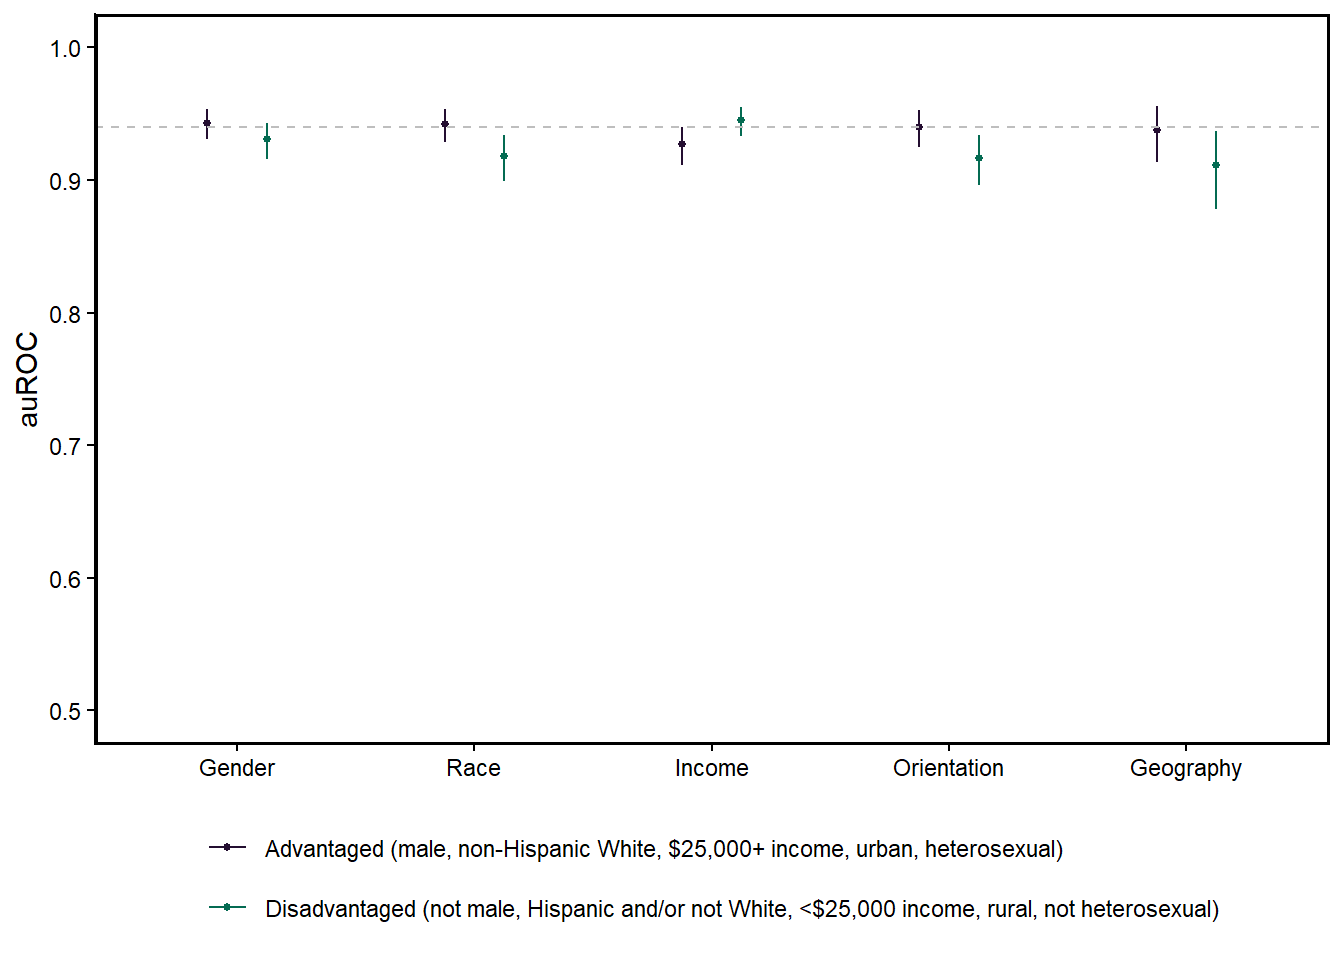

### Calibration and Overall Performance

The best full model configuration selected with 1 repeat of 5-fold cross-validation used an xgboost statistical algorithm and up-sampled the minority class.[3] This model produced generally well-calibrated raw probabilities (brier score = 0.014; left panel of @fig-2). We attempted to improve calibration with Platt scaling and results were comparable (brier score = 0.014). Histograms of raw risk probability distributions separately by true lapse outcome are presented in the right panel of @fig-2.

``` python
cal <- preds_all_raw |> 
  bind_rows(preds_all_logi) |> 
  mutate(prob = factor(prob, levels = c("Raw (uncalibrated)", 
                                        "Platt calibration"),
                       labels = c("Raw (uncalibrated)", 
                                        "Platt calibrated"))) |> 
  group_by(bins,  prob)  |> 
  summarize(mean_lapse = mean(lapse),
            n = n(),
            .groups = "drop") |> 
  filter(n >= 10) |> 
  select(-n) |> 
  mutate(
    bins = as.numeric(bins),
    midpoints = bin_width/2 + bin_width * (bins - 1)
  )  |> 
  ggplot(aes(x = midpoints, y = mean_lapse, group = prob,
             color = prob, linetype = prob)) +
  geom_abline(slope = 1, intercept = 0, linetype = "longdash", color = "gray80") +
  geom_line(linewidth = .7) +
  labs(
    x = "Predicted Lapse Probability (Bin Midpoint)",
    y = "Observed Lapse Probability",
    color = NULL,
    linetype = NULL
  ) +
  geom_rug(data = rug_data_raw, aes(x = rug_x, y = NULL), sides = "b", alpha = 0.3,
           inherit.aes = FALSE, color = "#240e31") +
  geom_rug(data = rug_data_logi, aes(x = rug_x, y = NULL), sides = "t", alpha = 0.3,
           inherit.aes = FALSE, color = "#046B52") +
  scale_x_continuous(breaks = seq(0, 1, bin_width), limits = c(0, 1)) +
  scale_y_continuous(limits = c(-0.08, 1), breaks = seq(0,1, bin_width),
                     expand = c(0, 0)) +
  coord_cartesian(clip = "off") +
  scale_color_manual(values = c("#240e31", "#046B52")) +
  scale_linetype_manual(values = c("solid", "twodash")) +
  theme_classic() +
  theme(axis.text=element_text(size=9.5),
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
        legend.key.size = unit(0.25, "cm")) 


hist <- preds |> 
  pivot_longer(cols = c(prob_raw, prob_logi), names_to = "prob_type", values_to = "prob") |>
  mutate(prob_type = factor(prob_type, levels = c("prob_raw", "prob_logi"),
                                labels = c("Raw (uncalibrated)", "Platt calibrated"))) |> 
  ggplot() +
  geom_histogram(aes(x = prob, fill = prob_type), color = "white", bins = 40) +
  facet_grid(label ~ prob_type, scales = "free_y") +
  labs(x = NULL,
       y = NULL) +
  scale_fill_manual(values = c("#240e31", "#046B52")) +
  theme_classic() +
  theme(axis.text=element_text(size=9.5),
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
        legend.position = "none")

cal / hist
```

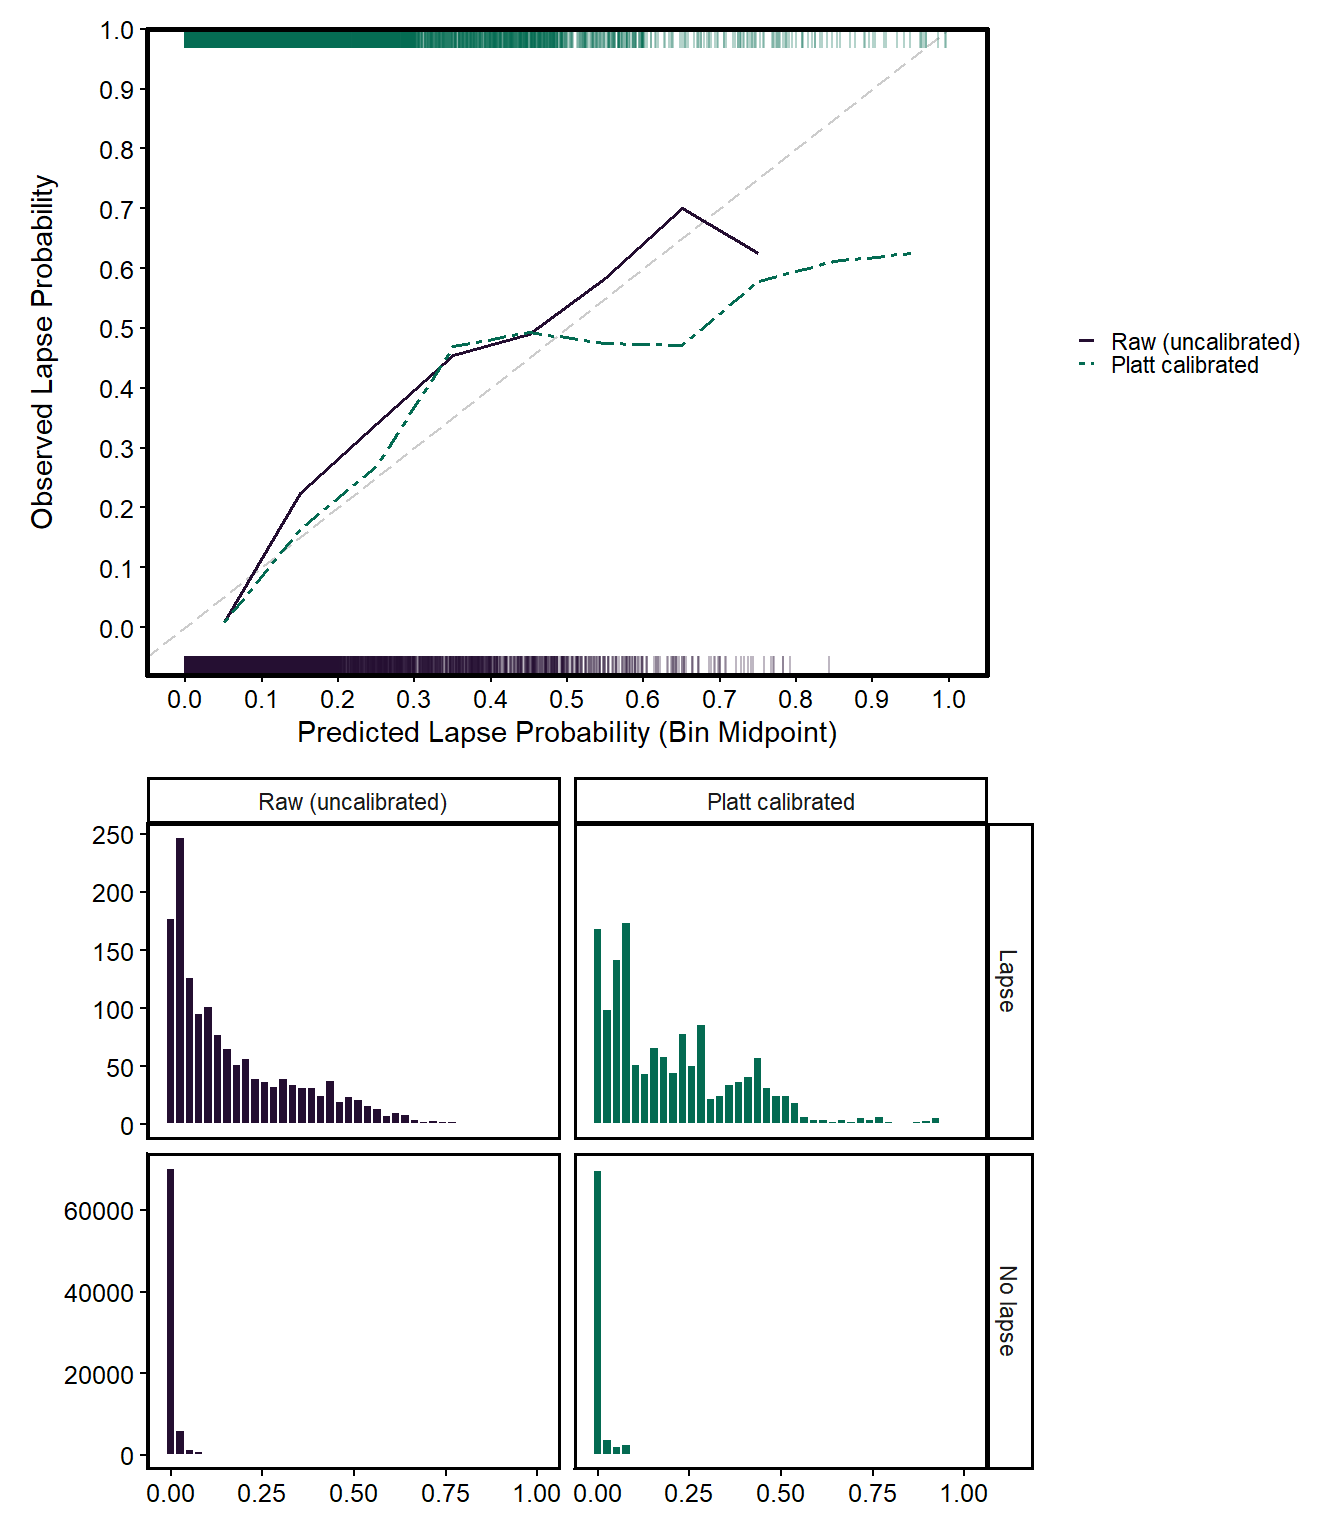

### Feature Importance

We aggregated individual Shapley values across all participants and all observations to provide a relative rank ordering of the most important features. A traditional mean absolute Shapley value approach revealed the most important feature (i.e., largest magnitude of change in log-odds) was differences in past opioid use. These feature was nearly two-fold more important than the next most important feature, raw urge ratings. @fig-3 displays the top 30 (out of 186) feature categories, as defined by the 30 largest absolute mean shapley values.

A second approach where we calculated the proportion of observations in which each feature category had the highest Shapley value (i.e., largest magnitude and prevalence), revealed the most important feature to be raw urge ratings, followed by raw abstinence confidence ratings. Differences in past opioid use was the third most important feature by this method, suggesting that while it has a strong relationship with lapse risk, it is not as prevalent across observations as other features. Notably, in this approach several additional comparably important features emerged, including differences in past pleasant experiences, differences in past stimulant use, and differences in time spent in helpful locations.

``` python
global_panel + local_panel
```

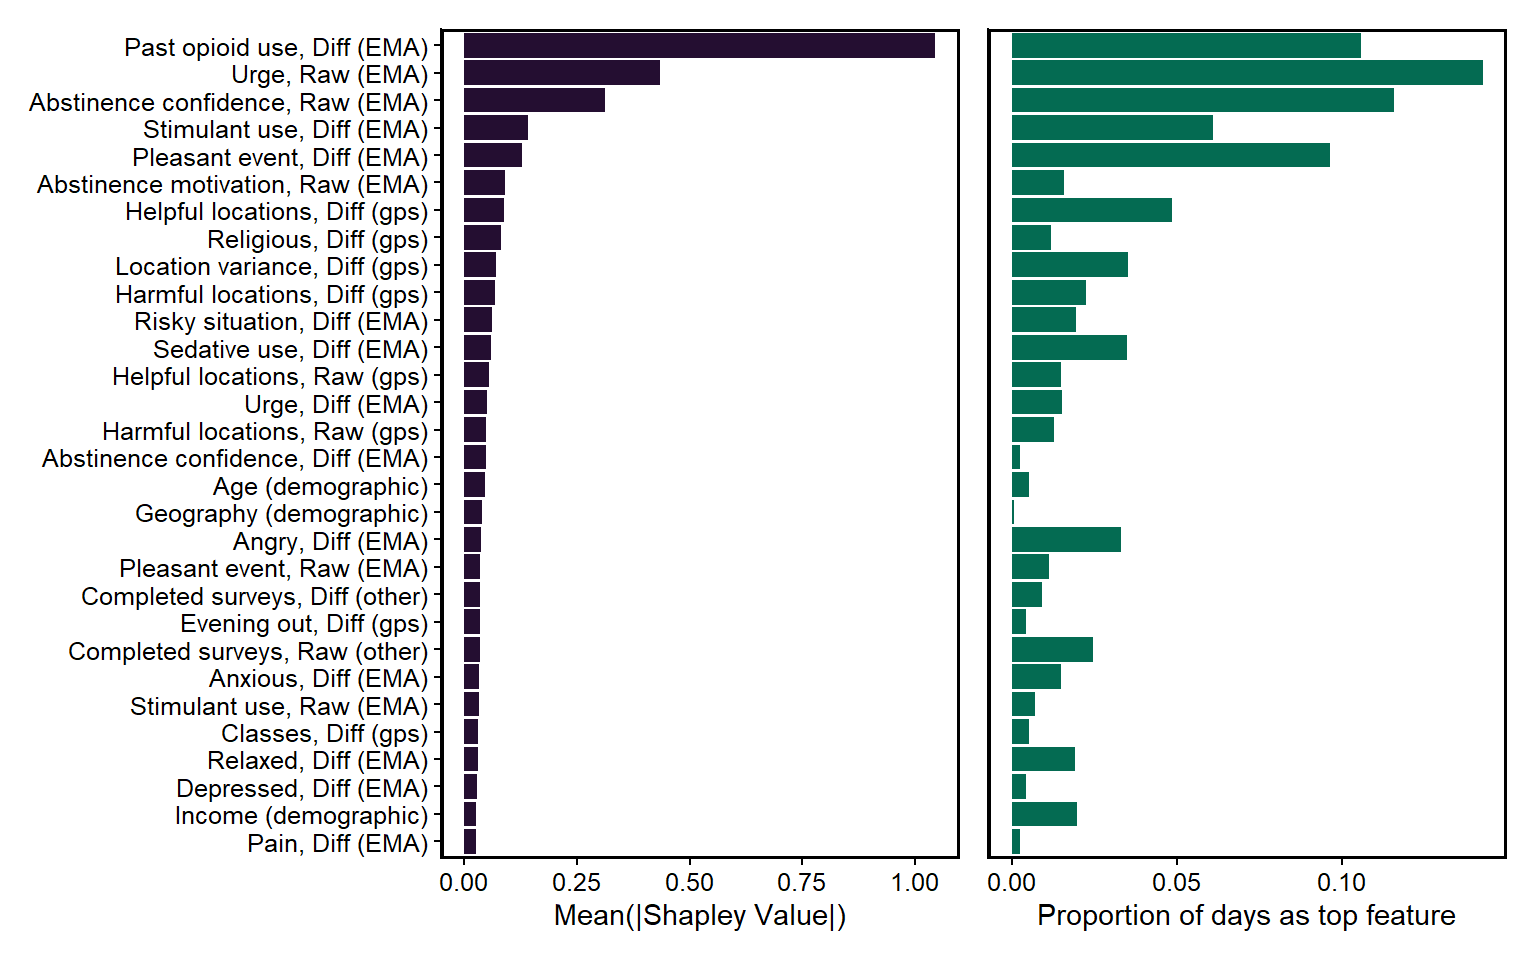

To understand the direction in which these feature categories adjusted the lapse risk predictions, we plotted Shapley-feature value partial dependence plots for the top 30 feature categories (@fig-4). Differenes in past opioid use lowered lapse risk probability for participants who did not lapse on study (i.e., a feature score of 0). Lapse probability dramatically increased when participants had increased reported opioid use over the past 24 and 168 hours. Unsurprisingly, raw urge and abstinence confidence ratings had linear relationships to lapse risk, with higher urge ratings increasing lapse risk probability and higher abstinence confidence decreasing lapse risk probability. There was a more nuanced finding for stimulant use and opioid lapse risk probability. Raw rate counts of stimulant use increased lapse risk; however, participants were at highest risk when recent stimulant use decreased (i.e., Stimulant Use, Diff).

``` python
shap_levels <- shaps |> 
  group_by(variable_grp) |>
  summarize(mean_value = mean(abs(value)), .groups = "drop") |>
  arrange(desc(mean_value)) |> 
  slice_head(n = 30) |> 
  pull(variable_grp)

shaps|>
  filter(variable_grp %in% shap_levels) |>
  mutate(variable_grp = factor(variable_grp, levels = shap_levels)) |>
  ggplot(aes(x = rfvalue, y = value)) +
  geom_point(alpha = .3) +
  geom_smooth(method = "gam", formula = y ~ s(x, k = 5, bs = "cs"), se = FALSE) +
  facet_wrap(~ variable_grp, scales = "free", ncol = 5) +
  labs(
    title = "Top 30 SHAP Variable Relationships",
    x = "z-score raw feature score",
    y = "Shapley value"
  ) +
  theme_classic() +
  theme(
    strip.text = element_text(size = 8),
    plot.title = element_text(size = 14, face = "bold")
  )
```

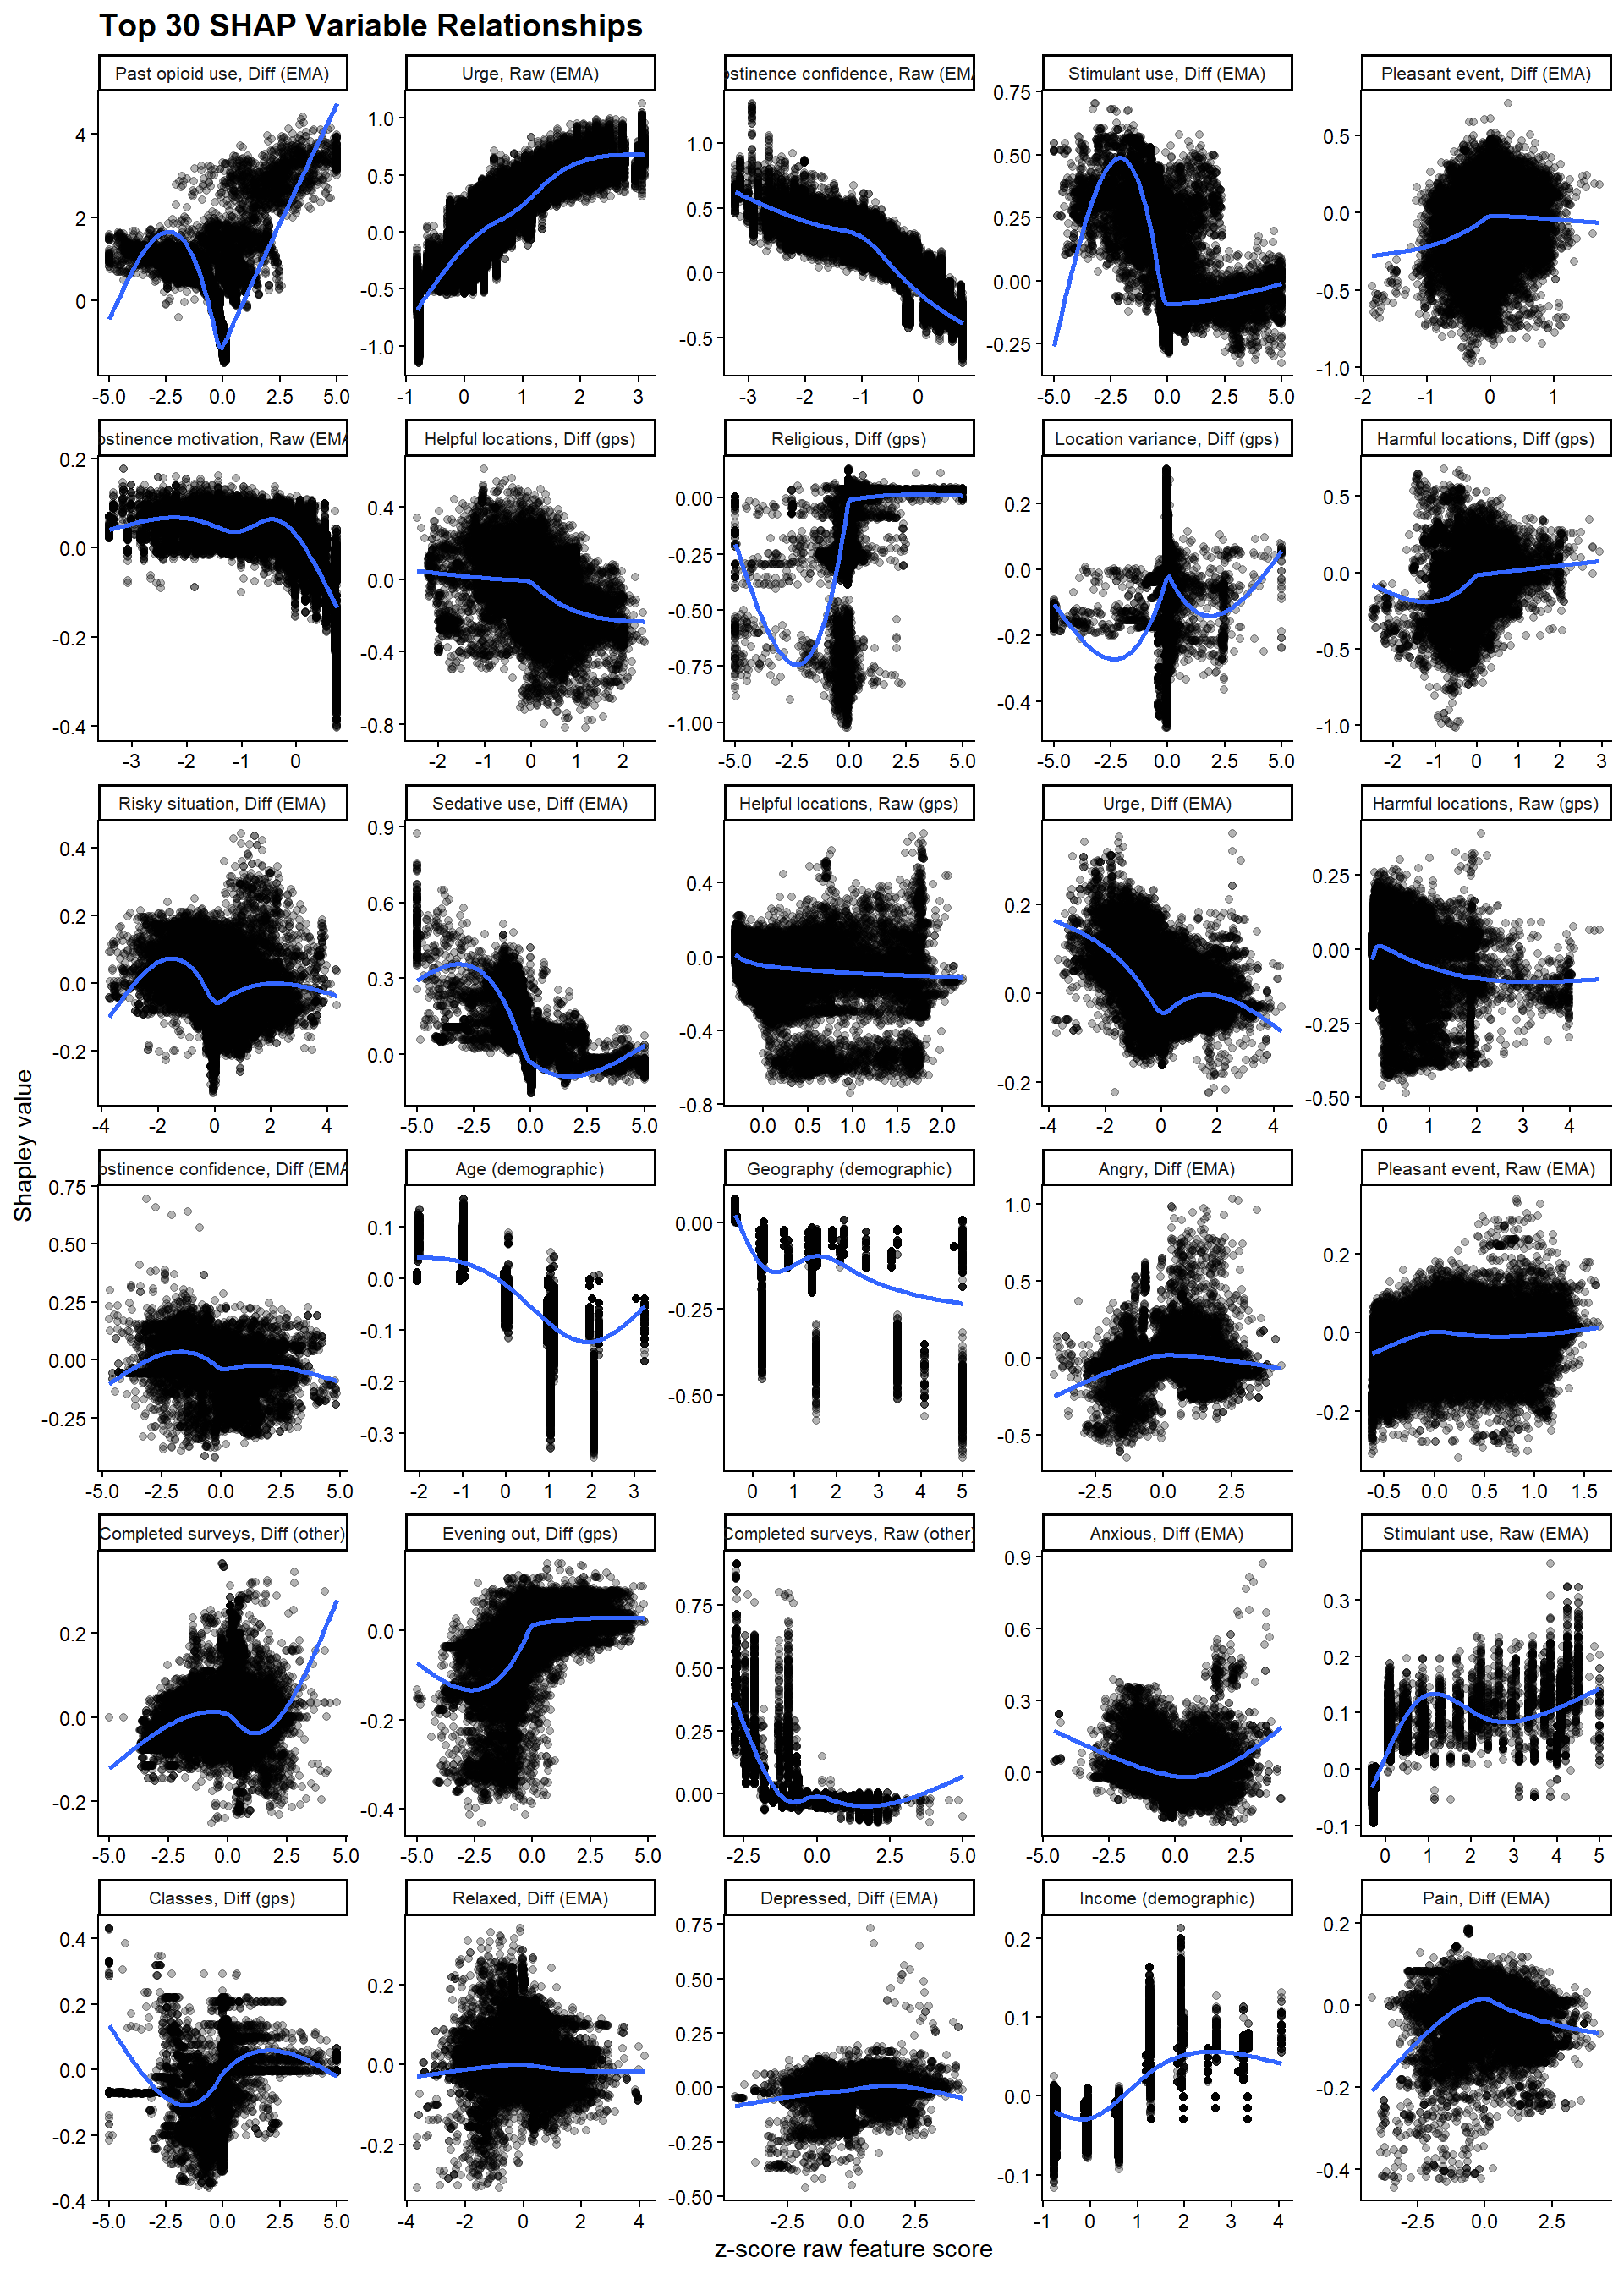

## Discussion

Our full model demonstrated that it is possible to future next-day lapses back to opioid use with high accuracy using smartphone sensing data (auROC = 0.94). Model predictions were well-calibrated, with estimated probabilities closely aligning with observed lapse rates. This is exciting given that our goal was to build a model that could provide insight into lapse risk.

Ablation model comparisons revealed that daily surveys alone captured nearly all of this predictive signal (auROC = 0.94). To our knowledge, no other published SUD study has collected daily survey data from participants continuously over the course of one year. Survey adherence rates in our sample were comparable to those observed in other clinical populations, suggesting that self‑report surveys are a feasible and risk-relevant sensing method for long‑term monitoring in this population.

When daily surveys were ablated from the model, predictive performance dropped substantially (auROC = 0.63). Although this performance remained above chance and exceeded that of a demographics‑only model (with both geolocation and daily surveys ablated; auROC = 0.55), it indicates that geolocation features captured only modest predictive signal. Moreover, given that ablating geolocation features did not result in any drop in performance, this signal likely overlaps with information already captured with the daily surveys. It is possible that the relatively low predictive value of geolocation sensing in this study was due to methodological limitations.

Although geolocation data can, in principle, be collected continuously moment‑by‑moment, in practice these data are difficult to collect reliably. In our study, geolocation features had substantially higher rates of missingness compared to daily surveys. Consequently, approximately 12% of geolocation features were imputed using median values derived from other individuals in the training dataset. Median values are by definition near the center of the feature distribution. These values are common and have limited influence on model predictions (i.e., low leverage). This was a purposeful decision in our design to ensure that missing data would not systematically influence predictions in either direction. However, this conservative approach likely contributed to reduced predictive performance of geolocation features, as imputations that minimize influence also limit the ability of those features to contribute risk‑relevant signal. Lastly, these median imputations are also not person-specific and as a result may not accurately represent typical values for the individual whose data are being imputed. As geolocation sensing methods become more robust and missingness is reduced, these features may become more powerful for lapse prediction.

A second limitation of our sensing method was that we relied on known locations with self-reported context. While this method provides meaningful contextual information, it is limited in its ability to capture the full range of locations participants visit (without substantially increasing participant burden). Passive methods for contextualizing location could address this limitation by providing risk-relevant contextual information across all locations. For example, latitude and longitude coordinates could be contextualized using publicly available datasets, such as alcohol outlet density, area deprivation index, and Narcotics Annonymous meeting times and locations. Increasing the number of locations would allow for potentially more variance in feature distributions within and between individuals.

To summarize, if the goal is prediction, geolocation sensing features are not necessary as they do not offer any unique incremental predictive value. However, if the goal is to have a more nuanced understanding of lapse risk across a more diverse array of risk features than geolocation is helpful. Adding geolocation features did not hurt model performance, and more data sources provides more opportunities for identifying intervenable targets specific to a person and moment in time.

We were excited to see that fairness discrepancies in model performance were minimal. In all subgroups, our model had a median auROC above 0.90, which is generally considered to be a benchmark of excellent performance. Nevertheless, differences of 0.02 - 0.03 (favoring the advantaged group) were present in race and ethnicity, sexual orientation, and geographic location comparisons. These group comparisons were the most imbalanced, with 19-29% of participants in the disadvantaged groups. Our model may perform better for these groups with greater representation in the training data. Future research into identifying additional risk factors for lapse that are more prevalent in these groups may also help to reduce these discrepancies.

Age may be another important dimension for evaluating model fairness. Older adults (65+ years) are less likely to receive substance use disorder treatment and often report lower levels of social interaction and support than younger adults. They may also be less comfortable with, or less able to provide, smartphone sensing data at the level of adherence needed for accurate prediction. We did not explicitly evaluate model fairness for this subgroup because we did not have the representation in our sample. We encourage researchers to perform this analysis in future studies.

When using a standard mean absolute Shapley value approach to estimate average feature importance across observations, the most important feature was prior opioid use. This finding is consistent with the relapse‑prevention literature, which identifies lapse as an important precursor to relapse, and prior prediction research demonstrating that lapses predict future lapses \[@wyantMachineLearningModels2024\]. Notably, this feature had a mean absolute Shapley value that was nearly two-fold higher than the next most important feature. When considering this model in the context of a recovery monitoring and support system that provides daily insight into lapse risk, this finding may be misleading. Fewer than 2% of day-level observations contained a lapse, and the majority of participants did not lapse at all. Among those who did lapse, many only lapsed one time. Given that lapse cannot be used as a predictor until after it has occurred, in most cases other features may represent more clinically meaningful targets for intervention.

A more informative approach to characterize feature importance is to consider the proportion of observations in which a given feature had the highest Shapley value. This approach considers both the magnitude of a feature’s effect (in terms of log-odds change in the prediction) and its prevalence across observations. Using this approach, urge ratings and abstinence confidence emerged as the features most frequently influencing lapse risk predictions. This suggests that individuals may benefit more often from recovery recommendations focused on reducing urges (e.g., urge surfing) and increasing abstinence confidence (e.g., reflecting on recent successes). Additionally, this approach showed that while some features have low average importance (across all individuals and observations), they can be highly important on certain days for certain individuals (e.g., self-reports of anger).

Across both feature importance approaches, geolocation features emerged among the top subset of features. Specifically, location variance, time spent in helpful and harmful locations, and time spent at locations where religious activities are performed were among the top ten features. These findings suggest that although geolocation features may not provide unique signal for prediction, it may be worthwhile to still include them in the model to expand opportunities for intervention and provide precision-oriented recovery support.

When considering how our model might generalize in real world context, we must consider that participants were compensated for completing daily surveys and providing geolocation data, which may have influenced their willingness to provide data. However, participants received no additional direct benefit from their participation beyond financial compensation. In real‑world implementations, individuals may be more motivated to share data when it enables personalized recovery support. This perceived benefit may outweigh the burden of data collection, possibly even more so than financial incentive.

Additionally, we implemented daily survey compliance thresholds to exclude participants and adjust study end dates. This criterion was important because we generated our lapse labels from the daily survey data and thus we required consistent collection of this data stream for accurate observation labels. As a result, our estimates of adherence and model performance may be slightly optimistic. Still, even with this criterion, nearly 78% of participants remained in the study for at least six months, suggesting that long-term monitoring with daily surveys is feasible for a substantial proportion of individuals in this population.

Lastly, participants provided data for up to 12 months. This extended window of recovery is critical for evaluating the value of an algorithm intended for ongoing continuing care support and understanding how lapse risk evolves as people progress in their recovery. Unfortunately, our ability to address explanatory questions about the time course of lapse risk, and how individuals might cluster on different recovery trajectories is limited with traditional machine learning methods. These methods do not capture the repeated nature of sensing data. Each lapse prediction is treated as a new independent observation. We can account for the repeated observations in our sensing data by engineering features that capture individual changes over time to produce unbiased and precise estimates of predictive performance. However, more traditional time series models may be better suited for understanding the temporal dynamics of lapse risk over long periods of recovery.

In conclusion, it is possible to predict future lapses back to opioid use using smartphone sensing data. Daily surveys and geolocation sensing provide diverse coverage of important risk factors for lapse. Daily recovery recommendations can be mapped onto these factors to deliver support that is personalized to both the person and the moment. While this model was evaluated in a research setting, our use of a national clinical sample of individuals with OUD suggests it represents a promising step toward future real‑world implementation and evaluation.



# Discussion

## Summary

This series of studies aimed to develop fair, temporally precise machine learning models for predicting lapses back to substance use that could be integrated into a recovery monitoring support system. Collectively, these studies address several key limitations of prior work to advance the generalizability and translational relevance of our findings. First, our models were trained on two relatively large, treatment‑seeking samples of adults in early recovery from AUD and OUD, closely matching the populations most likely to benefit from recovery monitoring systems. Second, we explicitly predicted goal‑inconsistent substance use (lapses) rather than general use. This distinction is important, as the risk factors underlying lapses likely differ from those associated with intentional or planned substance use. Third, data collection occurred during initial SUD remission, a well‑documented high‑risk period for relapse, increasing the likelihood that identified predictors reflect relevant risk processes to target with recovery support. Fourth, we collected EMA, geolocation, and substance use outcomes with sufficient frequency and granularity to support prediction with high temporal precision to identify changes in risk for immediate and future lapses for a specific individual at a specific moment in time. Finally, we used advanced resampling techniques (grouped, nested k‑fold cross‑validation) to obtain valid estimates of out‑of‑sample performance, strengthening confidence in how these models might generalize to new individuals.

## Model Performance

Across studies, models performed exceptionally well across varying prediction window widths (one week, one day, one hour), lag times between the prediction timepoint and the start of the prediction window (no lag, one day, three days, one week, two weeks), and substance use outcomes (alcohol use, opioid use). This consistency suggests that lapse risk can be meaningfully captured across multiple temporal scales and for different substances.

Model performance decreased as models predicted further into the future. This is unsurprising given what we know about prediction and substance use. Many important relapse risk factors are fluctuating processes that can change day-by-day, if not more frequently. As lag time increases, features become less proximal to the start of the prediction window. Implementing these models will require weighing the benefits of advanced notice against the cost to performance.

Models generally performed fairly when demographic groups were sufficiently represented in the training data. An exception to this pattern emerged when predicting alcohol lapses among women. Although the AUD sample was balanced on sex at birth, model performance was poorer for women compared to men. Notably, this disparity was substantially reduced when predicting opioid lapses. One important difference across studies was how this demographic dimension was operationalized. In the AUD sample, we used sex assigned at birth, whereas in the OUD sample we pivoted to a more inclusive measure of gender identity. It is possible that, had our OUD models been evaluated using sex assigned at birth, we would have observed comparable discrepancies in performance. However, we did not collect sex assigned at birth in the OUD sample and therefore could neither confirm nor rule out this possibility. Nevertheless, we believe several alternative explanations are more plausible.

First, the AUD sample was geographically constrained. This raises the possibility that factors unique to women in Madison, WI may differentially influence lapse risk, rather than reflecting sex differences more generally. For example, our AUD sample was predominantly college educated non-Hispanic White individuals. These characteristics do not accurately reflect the demographic composition of the broader population of individuals with AUD. Madison, WI also has unique social and environmental factors (e.g., permissive drinking norms, long winters) that could raise concerns about the generalizability of these sex-specific differences.

Second, while alcohol use is broadly socially accepted, there may be sex-specific contexts in which it is less accepted. Women may face distinct social pressures (e.g., childcare responsibilities) that intersect with AUD, and potentially other identity factors, to increase both internalized and external experiences of stigma. These dynamics could affect the measurement of both the outcome (e.g., women underreporting alcohol lapses relative to men) and the predictors (e.g., failure to measure sex-specific risk-relevant experiences). Opioid use, on the other hand, is illegal and highly stigmatized across contexts \[@cheethamImpactStigmaPeople2022\], which may result in more equally distributed stigma-related experiences among men and women. As a result, any measurement effects related to stigma would have been present in both gender groups in the OUD sample.

Third, changes in how we measured risk-relevant constructs may have enabled us to capture additional important predictors for women that were not well captured in the AUD sample. Most notably, we added an entirely new set of features derived from geolocation sensing. Prior research has identified gender differences in associations between social support and relapse risk. Specifically, women appear more likely to relapse when living apart from their children, experiencing depression, or undergoing marital stress \[@maxwellGenderDifferencesPsychosocial2022; @walitzerGenderDifferencesAlcohol2006; @saundersWomenAlcoholProblems1993\]. Our measure of location variance may have captured downstream behavioral correlates of low social support, such as social isolation or limited time spent outside the home or workplace.

We also expanded the number and specificity of EMA items. In previous unpublished analyses of the AUD sample, abstinence self-efficacy was a much stronger predictor of lapse for men than for women. Given that this construct was the second most important feature in the AUD model, it likely contributed to the observed sex-specific performance discrepancy. In the OUD sample, we broke this item into two distinct parts. Specifically, the question “How likely are you to drink any alcohol within the next week?” was replaced with: (1) “Thinking forward to the next week, how motivated are you to completely avoid using opioids for non-medical reasons?” and (2) “Thinking forward to the next week, how confident are you in your ability to completely avoid using opioids for non-medical reasons?” This more nuanced operationalization may have allowed us to better capture motivational and confidence-related components of efficacy that are differentially predictive for women.

Relapse among women has also been more consistently linked to negative affect compared to men \[@zywiakAlcoholRelapseRepetition2006a\]. In the OUD sample, we added items assessing discrete emotional states (relaxed, happy, depressed, anxious, angry), whereas the AUD sample relied on more general assessments of affect using bipolar valence and arousal scales. This increased emotional granularity may have further improved the model’s ability to capture risk processes more specific to women.

While we offer several hypotheses for how specific features may produce sex-specific effects on model performance, it is likely that we would also observe feature interactions with race and ethnicity, income, geographic location and sexual orientation. We plan to explore how the relative ordering of features by importance differs for these different demographic subgroups. Although our model produced comparable overall performance for these groups (when sufficiently represented), the model may work through distinct predictive pathways for different groups. Understanding how features contribute to model performance across fairness groups could inform more tailored recovery recommendations and guide the selection of features in future modeling efforts.

## Important Features

We used Shapley values to characterize the average contribution of a feature on the model’s prediction across all participants and observations \[@lundbergUnifiedApproachInterpreting2017\]. The relative ordering of EMA features remained somewhat consistent across alcohol and opioid models. Past use was the most important feature in both models in our dataset. This is not surprising given that our outcome was lapse, and past behavior is often the best predictor of future behavior \[@ouelletteHabitIntentionEveryday1998\]. Craving/urges and abstinence self-efficacy/confidence also emerged as top features across all studies, suggesting that, consistent with decades of relapse prevention literature, these remain important targets for intervention to support early recovery efforts \[@marlattRelapsePreventionMaintenance1985\].

Some noticeable differences across substances, however, did exist. Day of the prediction window influenced lapse predictions for alcohol but not opioid lapses, potentially reflecting differences in normative patterns of use (e.g., weekend drinking vs. less patterned opioid use). Additionally, past pleasant events was the fourth most important EMA feature for opioid lapse risk, compared with the eighth most important EMA feature for alcohol lapse risk. Partial dependence plots indicated a protective effect of pleasant events on opioid lapse risk. This likely reflects a more nuanced relationship between pleasant events and the environmental contingencies surrounding them. Alcohol is commonly integrated into celebratory, recreational, social, and otherwise “pleasant” events. These alcohol-related cues may undermine the protective effects of pleasant events for alcohol lapse risk while having little or no effect on opioid lapse risk.

We observed a diminished effect of the top EMA features when there was longer lag times between the prediction timepoint and start of the prediction window. This is consistent with reduced model performance in the lagged models and could reflect the inherent ebb-and-flow nature of the risk factors we chose to measure with EMA. For example, the importance of abstinence self-efficacy dropped by more than 50% in the 2-week lagged model relative to the immediate model. This may indicate that self-efficacy during early recovery is unstable even across shorter periods of time such that their current self-efficacy does not strongly predict abstinence success even two weeks into the future. Even past use, was less important for the lagged models, suggesting predictive strength of a lapse on the likelihood of subsequent lapses diminishes to some degree over a relatively short period of time. This reinforces the idea that single lapses do not always mark a return to consistent patterns of frequent, and potentially harmful, substance use \[@witkiewitzModelingComplexityPosttreatment2007\].

On the other hand, we were surprised to discover that past and anticipated risky situations were more important in the lagged models compared to the immediate model, suggesting that the impact of these situations on lapses back to use may be delayed. It may be that persistent exposure to risks is necessary to undermine an abstinence goal and lead to return to substance use. Alternatively or additionally, people may also be better able to anticipate future risky situations (e.g., vacations, anniversaries of significant dates) than future acute stressors or even future self-efficacy.

In Chapter 4, we extended our sensing methods to include geolocation. Geolocation features emerged among the top subset of features. Specifically, location variance, time spent in helpful and harmful locations, and time spent at locations where religious activities are performed were among the top ten features and surpassed several EMA features, including discrete emotional experiences (relaxed, happy, depressed, anxious, angry), pain, sleep quality, and past and future stressful events.

Global feature importance provides insight into overall patterns of risk factors and lapse (i.e., what is generally most important on average). However, in the context of a precision-guided recovery monitoring support system, we are interested in understanding which risk factor is most important for a given individual at a specific moment in time (local importance). We explored two visual characterizations of local feature importance. In Study 1, we plotted the distributions of local Shapley values. These plots were useful for demonstrating the wide range of variability in feature importance across individuals and observations. However, they still aggregated data across individuals and time points, which obscured the within-person context of each prediction. For example, the range of local Shapley values for valence appears relatively narrow compared to other, more globally important features. Nevertheless, for some individuals at certain moments, valence may be the most influential feature affecting lapse risk.

In Study 3, we explored an alternative visualization of feature importance. Specifically, we calculated the proportion of observations for which each feature category had the highest Shapley value. This provided a summary of the proportion of days on which each feature was most important. Importantly, this visualization revealed that although past use appeared to be the most influential feature overall, it was only the most influential feature on a subset of days. This makes sense given that across studies, the proportion of day-level observations positive for lapse ranged from 1.8% to 7.7%.

Using this alternative approach, urge ratings and abstinence confidence emerged as the features most frequently influencing lapse risk predictions. This suggests that individuals may benefit more often from recovery recommendations focused on reducing urges (e.g., urge surfing) and increasing abstinence confidence (e.g., reflecting on recent successes). Additionally, this approach showed that while some features have low average importance (across all individuals and observations), they can be highly important on certain days for certain individuals (e.g., self-reports of anger). Thus, this approach more closely aligns with our precision-guided goal of understanding which risk factor is most influential for a specific individual at a specific moment. In the context of recovery, where lapses are important but relatively infrequent events, features other than past use will, in most cases, represent more clinically meaningful targets for intervention.

## Limitations

EMA was shown to be a robust sensing method for lapse prediction. In Studies 1–2, participants were able and willing to comply with an intensive 4× daily EMA protocol for up to three months. This is promising, as many EMA studies have been limited to shorter durations \[@jonesComplianceEcologicalMomentary2019\]. However, while this level of sampling is feasible, it may not be necessary. We found that a once-daily survey was sufficient for accurate prediction of opioid lapse risk in Study 3, suggesting that self-report sensing can be collected over long durations (i.e., at least up to a year) with relatively low burden.

It may be, however, that additional risk factors not currently measured could further improve our models. For example, incorporating lapse risk factors that may be more salient for women (e.g., interpersonal relationship problems, hormonal changes \[@walitzerGenderDifferencesAlcohol2006; @mchughSexGenderDifferences2018\]) and other underrepresented groups could help reduce performance disparities. Additionally, a broader set of features may enable more personalized and variable risk feedback. At the same time, the increased burden associated with additional survey items must be carefully weighed.

One way to expand risk features without increasing burden is to supplement self-report data with passive sensing methods. In Study 3, we began to explore the use of geolocation data to predict opioid lapse risk. Although geolocation data collected via our sensing method did not add unique predictive value beyond EMA, these features did emerge as important in the model, thereby expanding the range of risk factors that can be targeted for intervention.

Our geolocation sensing approach had several limitations that may have reduced its predictive value and attenuated feature importance. First, although geolocation data can, in principle, be collected continuously, in practice these data are difficult to collect reliably. In our study, geolocation features had substantially higher rates of missingness compared to daily surveys. Second, our feature engineering pipeline relied on known locations with self-reported context. While this approach provides meaningful contextual information, it is limited in its ability to capture the full range of locations participants visit without substantially increasing participant burden. Passive methods for contextualizing location could address this limitation by providing risk-relevant contextual information across all locations. For example, latitude and longitude coordinates could be enriched using publicly available datasets (e.g., alcohol outlet density, area deprivation index, and Narcotics Anonymous meeting times and locations). As geolocation sensing methods become more robust and missingness is reduced, these features may become more powerful for lapse prediction.

There is also a question as to whether geolocation sensing is as feasible for rural populations as it is for urban populations. Modern GPS often uses cell towers and Wi-Fi networks to improve speed and accuracy. In rural areas, where such infrastructure is sparse, devices rely more heavily on satellite-only positioning, which can be slower to initialize and less reliable under suboptimal signal conditions \[@grovesPrinciplesGNSSInertial2013\]. Therefore, we plan to explicitly assess differences in geolocation adherence (e.g., the percentage of days with available geolocation data) as well as differences in the strength of geolocation feature importance between these groups.

If geolocation sensing proves to be less accurate or reliable for rural populations, this could foreshadow additional design challenges associated with using a web-based app for recovery monitoring. For example, unstable internet connectivity may necessitate storing in-app recovery recommendations locally so that individuals can access them at moments of need. Even EMA, when administered once per day, could pose challenges if completed surveys cannot be reliably transmitted over cellular data. We highlight these potential limitations as areas warranting close examination in future work. Nevertheless, we remain optimistic about the potential of geolocation sensing, given that our models generally performed comparably across rural and urban groups.

Other characteristics of our samples may limit the generalizability of our findings. One obvious limitation is the research context in which participants provided these data. Participants were modestly compensated for completing daily surveys and providing geolocation data, which may have influenced their willingness to provide these data. However, participants received no additional direct benefit beyond financial compensation. In real-world implementations, individuals may be more motivated to share data if doing so enables personalized recovery support.

A second limitation is that both clinical samples in these studies were restricted to individuals with a goal of abstinence. Accordingly, our models were trained to predict goal-inconsistent use (i.e., lapse), which may limit their applicability to individuals with alternative recovery goals. Although we see no inherent reason these models could not be adapted for individuals pursuing moderation or harm reduction, this remains an empirical question. For individuals who do not aim to abstain, the definition of goal-inconsistent use is less straightforward and may vary considerably from person to person. This requires the consideration of alternative outcomes to train models on.

One potential outcome is the prediction of heavy drinking days. Heavy drinking days are defined by the National Institute on Alcohol Abuse and Alcoholism (NIAAA) as a threshold indicative of hazardous drinking, and this threshold may be more consistently viewed as goal-inconsistent among individuals aiming to reduce or moderate their alcohol use. Another option is to allow individuals to self-define goal-inconsistent use (e.g., drinking on a weekday, drinking more than planned) and to train models in samples with diverse recovery goals. More broadly, focusing exclusively on drinking as the primary outcome may overlook other clinically meaningful indicators of recovery, particularly for individuals not seeking abstinence. Outcomes such as well-being, mental health, functional status, and quality of life may be more relevant in harm reduction contexts. Future work should therefore explore alternative outcome definitions.

While Study 3 achieved greater sample diversity compared to Studies 1–2, future models would benefit from increased representation across race and ethnicity, sexual orientation, and geographic location. Future research should also purposefully recruit participants across a wider age range. Older adults (65+ years) are less likely to receive substance use disorder treatment and often report lower levels of social interaction and support than younger adults \[@choiTreatmentUsePerceived2014; @kilaruIncidenceTreatmentOpioid2020\]. They may also be less comfortable with, or less able to provide, smartphone sensing data at the level of adherence needed for accurate prediction. We did not explicitly evaluate model fairness for this subgroup due to limited representation in our sample. We encourage future research to examine model performance for older adults to ensure generalizability.

We also plan to explore how models perform over extended recovery trajectories. In all studies, we explicitly recruited participants who were early in their recovery (defined by time abstinent). Thus, it is possible that our models more accurately represent relationships between risk factors and lapse among individuals in early recovery. As individuals progress in their recovery, the relative importance of different risk factors may change. For example, craving may be more important for lapse risk during early recovery, whereas pleasant events and location variance may become more important during extended recovery.

In our OUD sample, participants remained in the study for up to one year. This provides a unique opportunity to test whether the accuracy of our model’s predictions or the magnitude of a feature’s contribution to those predictions, changes as a function of time in recovery. For example, we could include a time-varying recovery feature, such as days since the most recent quit date or days since the last treatment episode, in our model. Because our best-performing models have been XGBoost, they can natively accommodate interactions between this recovery feature and other predictors. We could then assess whether model performance and the relative ordering of important features differ between the first half and the second half of the study period, providing insight into potential differences in early versus later recovery.

Lastly, there may be value in exploring alternative modeling approaches that better leverage the temporal structure and individual-level nature of these data. For example, hierarchical models that start with population-based information (i.e., priors) and are updated with person-specific information as the individual provides data may be the most promising approach for effective use of time-varying information to model how an individual’s lapse risk evolves over time. Our lab has begun to develop these models and found preliminary evidence to suggest that they may outperform traditional machine learning models \[@pulickIdiographicLapsePrediction2025\]. Although our immediate lapse risk models already perform well, individualized models may improve performance for lagged predictions. Time series approaches could also increase efficiency by enabling a single model to predict lapse risk across multiple time horizons, eliminating the need for separate models for immediate and future risk. Finally, individualized models may help mitigate fairness concerns, as they place greater weight on a person’s own data rather than group-level estimates.

## Recovery Monitoring and Support System

We believe that lapse prediction models will be most effective when embedded within a broader recovery monitoring and support system capable of delivering adaptive, personalized continuing care. Such a system could send automated daily messages to patients, with feedback about their current lapse risk along with recovery support recommendations tailored to their evolving needs. Collectively, the present studies provide initial support for this goal by demonstrating that both immediate and lagged lapse prediction models can be developed with high accuracy using EMA and geolocation sensing data. Importantly, these studies also show that locally important features driving individual risk predictions can be identified and used to deliver personalized recovery support.

Immediate lapse prediction models are well-suited to guide individuals to take immediate, actionable steps to maintain their recovery goals and support them to implement these steps. For example, when an individual’s immediate risk is driven by strong craving, the system might recommend an urge-surfing exercise; when risk is driven by recent stressors, a guided relaxation or stress-management activity may be more appropriate; and when self-efficacy is low, reflective exercises focused on past successes or core reasons for choosing abstinence or moderation may be most beneficial.

In contrast, lagged models provide advanced warning of risk (e.g., days to weeks before the lapse occurs). These models are well-suited to support recovery needs that cannot be addressed within an app, such as scheduling positive or pleasant activities, increasing social engagement, or attending a peer-led recovery meeting. To be clear, we do not believe an app alone is sufficient to deliver continuing care. We expect individuals will require additional support throughout their recovery from a mental health provider (e.g., motivational enhancement, crisis management, skill building), a peer (e.g., sponsor, support group), or family member. Importantly, these types of supports take time to set up, highlighting the value of this lagged week model. Taken together, immediate and lagged models can be combined in a complementary fashion, enabling both highly accurate real-time detection of imminent lapse risk and advance warning of future lapse risk.

A challenge for embedding lapse prediction models into a recovery monitoring and support system is determining how to effectively communicate model outputs to individuals. Our models generate quantitative predictions of lapse probability. These probabilities could be converted into categorical classifications (e.g., lapse vs. no lapse) by applying a decision threshold. Although we observed high sensitivity and specificity when thresholds were selected to balance these metrics, the positive predictive value (PPV) of categorical predictions was moderate to low in our full models. As a result, we believe categorical predictions should be communicated to patients with extreme caution, if at all. Instead, we favor the use of quantitative lapse probabilities as continuous risk indicators to guide supportive interventions and monitoring intensity.

However, raw probability estimates present a different problem. They may be difficult for patients, especially for those with low numeracy, to interpret intuitively (e.g., distinguishing the practical meaning of a 79% versus a 64% lapse probability) \[@garcia-retameroCommunicatingHealthRisks2013\]. Anchoring risk estimates to an individual’s personal baseline may enhance interpretability. For example, by emphasizing whether risk is higher or lower than in the prior week or relative to their typical pattern. Additionally, combining quantitative scores with coarser qualitative descriptors (e.g., low, moderate, high risk) may further support comprehension without oversimplification.

Beyond risk probabilities, our models also identify the most influential features contributing to each prediction. These locally important features create opportunities to contextualize risk feedback by highlighting key drivers of vulnerability (e.g., craving, stress, social isolation) and pairing them with domain-informed recovery recommendations. Emerging best practices from interpretable machine learning suggest this information may make the machine learning model less of a “black box”, which may build trust, or allow individuals to engage more thoughtfully (e.g., questioning false positives, scrutinizing model behavior) and gain insight \[@dacruzUsingInterpretabilityApproaches2021; @shinEffectsExplainabilityCausability2021\].

Despite these opportunities, there is currently no consensus on how best to present predictive feedback in a manner that maximizes engagement, trust, and clinical utility. Prior research suggests that increasing transparency in machine learning systems, such as by revealing contributing factors, can improve perceived credibility and user acceptance \[@kizilcecHowMuchInformation2016; @kuleszaPrinciplesExplanatoryDebugging2015; @limWhyWhyNot2009\]. In the context of recovery monitoring, selective transparency may also promote self-awareness and learning, potentially yielding additional clinical benefits \[@kuleszaPrinciplesExplanatoryDebugging2015; @kuleszaFixingProgramMy2009\]. At the same time, overly detailed or complex explanations may undermine confidence by exposing model uncertainty, revealing occasional errors, or burdening users with unnecessary information \[@buntAreExplanationsAlways2012; @springerProgressiveDisclosureWhen2020\]. Thus, determining the optimal balance between transparency and simplicity remains an open empirical question.

## Conclusions

Collectively, these studies demonstrate that it is feasible to (1) collect temporally dense, recovery‑relevant data, (2) predict lapse risk at clinically meaningful time scales with interpretable models, and (3) do so in a way that supports equitable performance across important demographic subgroups. Thus, these studies lay the groundwork for an automated recovery monitoring and support system to improve continuing care following an initial SUD treatment episode.

As immediate next steps, we have begun to address the gap in understanding how to deliver risk‑related feedback within a recovery monitoring and support system. We have recently launched an NIAAA‑funded study focused on optimizing daily support messages delivered by such a system \[@wyantMaximizingEngagementTrust2025\]. This work will explicitly examine which combinations of key message components, including lapse probability, important features, and recovery recommendations, maximize engagement, trust, and clinical outcomes.

In this grant, messages are generated by feeding model outputs into a large language model to produce daily messages with sufficient variation. In the near future, however, these model outputs may be integrated into a more fully autonomous, agentic support system capable of dynamically delivering personalized recommendations, engaging individuals in interactive problem‑solving, facilitating connections to therapists or peer support specialists, and initiating triage processes when risk reaches clinically concerning levels.

Once a model is deployed within a recovery monitoring and support system, continued evaluation of model performance over time will be critical. Lapse prediction models must be routinely reassessed for performance drift and updated using data from target populations to ensure ongoing validity and equity.

Finally, these systems must be contextualized within the realities of the broader continuum of care for SUDs. Many individuals face significant barriers to accessing timely and consistent substance use treatment. Moving forward, it will be important to continue considering how machine learning and related technologies can help address structural limitations in SUD treatment. For example, models embedded within clinical decision support systems have the potential to extend the reach of clinician‑led care by reducing administrative burden, assisting with patient triage, and even presenting clinicians with proposed treatment plans based on predicted treatment response.



# References

[1] 405 participants consented to participate in the study and provided at least one daily survey; however, 75 participants dropped out prior to completing the first personalized monthly survey and were therefore not considered fully enrolled in the study.

[2] If adherence fell below 33% (roughly 9 surveys in a 28-day period) for a prolonged period of time, participant study end dates were changed to match the start of this adherence drop.

[3] The best model configuration used 1:5 upsampling of the majority class and the following hyperparameter values: learning rate = .1, tree depth = 3, mtry = 50.